# Consolidate all the data cleaning/wrangling into one notebook

In [3]:
import warnings
from arivale_data_interface import get_snapshot
import pandas as pd
import numpy as np
import scipy
import json

warnings.simplefilter("ignore")

# Open the cleaned and aggregated fitbit df with the covariates already merged on for each participant
sleep_merged = pd.read_csv("../fitbit_data_processing/scheme26_fitbit_scheme25wWeekdayRatioAndSeasonMode_2025-08-18.csv", dtype={'public_client_id': object})

with open('../fitbit_data_processing/sleep_features.json', 'r') as f:
    sleep_features = json.load(f)
with open('../fitbit_data_processing/activity_features.json', 'r') as f:
    activity_features = json.load(f)
with open('../fitbit_data_processing/covariates.json', 'r') as f:
    covariates = json.load(f)

In [4]:
sleep_merged.shape

(2212, 68)

### Load my functions

In [16]:
import sys
import os

# Import my regression and plotting functions python file to use the functions from that
sys.path.append(os.path.abspath("../regression_and_plotting_functions"))
from regression_and_plotting_functions import *

In [4]:
sleep_merged.shape

(2212, 68)

# Create the features_dict

In [5]:
features_dict = {}

In [6]:
# make a list of the heartrate features
heartrate_features = sleep_merged.filter(like='heart').columns.tolist()
features_dict['heartrate_features'] = heartrate_features

# make a list of the activity features
activity_features = sleep_merged.filter(like='activit').columns.tolist()
features_dict['activity_features'] = activity_features

# make a list of the sleep features
sleep_features = [feature for feature in sleep_merged.filter(like='sleep').columns.tolist() 
 if feature not in ['sleep_minutesToFallAsleep', 'sleep_minutesToFallAsleep_std', 'reference_sleepStartTime']]
# add in the bedtime and std of bedtime feature
sleep_features = sleep_features + ['bedtime_int', 'bedtime_int_std']
features_dict['sleep_features'] = sleep_features

In [7]:
# add in the baseline covariate features
features_dict['covariate_features'] = ['sex', 'age', 'BMI_CALC', 'PC1', 'PC2', 'PC3']

In [8]:
features_dict

{'heartrate_features': ['heartrate_cardio',
  'heartrate_fatburn',
  'heartrate_peak',
  'heartrate_resting',
  'heartrate_cardio_std',
  'heartrate_fatburn_std',
  'heartrate_peak_std',
  'heartrate_resting_std'],
 'activity_features': ['activities_activityCalories',
  'activities_calories',
  'activities_distance',
  'activities_elevation',
  'activities_floors',
  'activities_minutesFairlyActive',
  'activities_minutesLightlyActive',
  'activities_minutesSedentary',
  'activities_minutesVeryActive',
  'activities_steps',
  'activities_activityCalories_std',
  'activities_calories_std',
  'activities_distance_std',
  'activities_elevation_std',
  'activities_floors_std',
  'activities_minutesFairlyActive_std',
  'activities_minutesLightlyActive_std',
  'activities_minutesSedentary_std',
  'activities_minutesVeryActive_std',
  'activities_steps_std'],
 'sleep_features': ['sleep_awakeDuration',
  'sleep_awakeningsCount',
  'sleep_efficiency',
  'sleep_minutesAfterWakeup',
  'sleep_minu

# Visualize some of the distributions to check if any of the dependent (sleep) variables need transformations applied

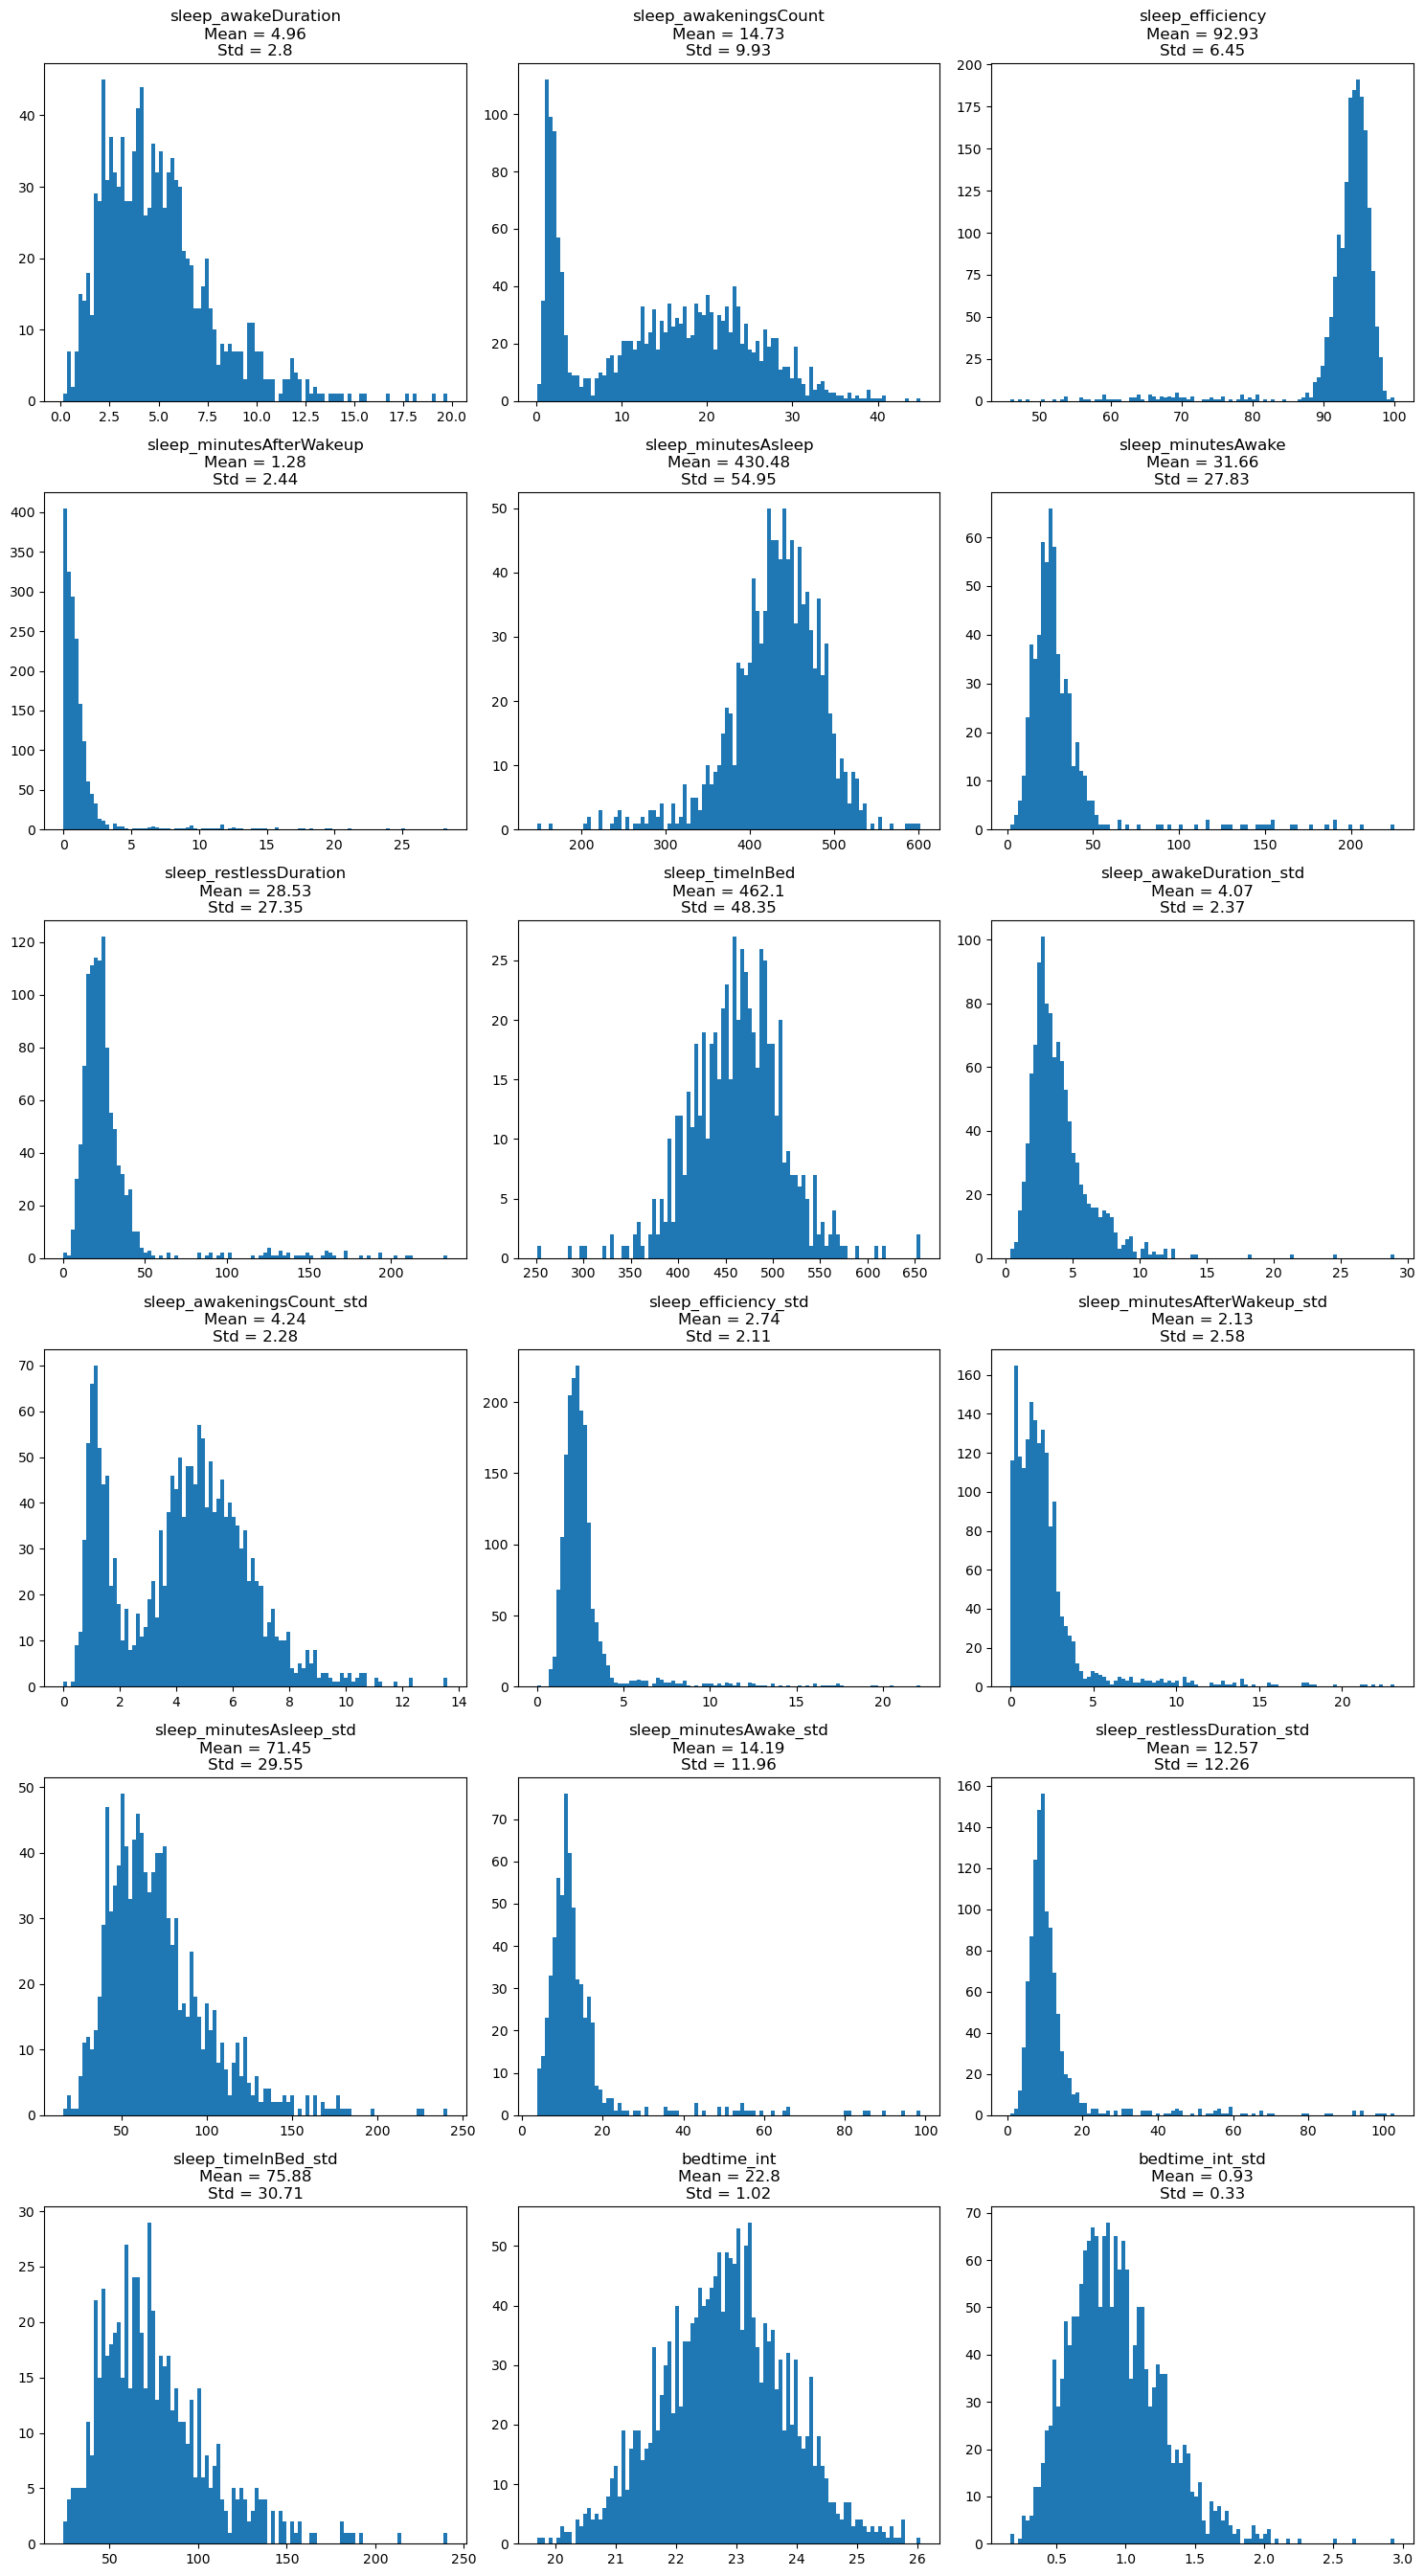

In [9]:
plot_histograms(sleep_merged, features_dict['sleep_features'])

# Drop all nan activity features, since nan activity features also are nan sleep features
See the .info() comparisons below

In [10]:
sleep_merged[features_dict['activity_features']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2212 entries, 0 to 2211
Data columns (total 20 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   activities_activityCalories          1796 non-null   float64
 1   activities_calories                  1796 non-null   float64
 2   activities_distance                  1796 non-null   float64
 3   activities_elevation                 1796 non-null   float64
 4   activities_floors                    1796 non-null   float64
 5   activities_minutesFairlyActive       1796 non-null   float64
 6   activities_minutesLightlyActive      1796 non-null   float64
 7   activities_minutesSedentary          1796 non-null   float64
 8   activities_minutesVeryActive         1796 non-null   float64
 9   activities_steps                     1796 non-null   float64
 10  activities_activityCalories_std      1796 non-null   float64
 11  activities_calories_std       

In [11]:
sleep_merged[features_dict['sleep_features']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2212 entries, 0 to 2211
Data columns (total 18 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   sleep_awakeDuration           1113 non-null   float64
 1   sleep_awakeningsCount         1796 non-null   float64
 2   sleep_efficiency              1796 non-null   float64
 3   sleep_minutesAfterWakeup      1796 non-null   float64
 4   sleep_minutesAsleep           1113 non-null   float64
 5   sleep_minutesAwake            621 non-null    float64
 6   sleep_restlessDuration        1113 non-null   float64
 7   sleep_timeInBed               621 non-null    float64
 8   sleep_awakeDuration_std       1113 non-null   float64
 9   sleep_awakeningsCount_std     1796 non-null   float64
 10  sleep_efficiency_std          1796 non-null   float64
 11  sleep_minutesAfterWakeup_std  1796 non-null   float64
 12  sleep_minutesAsleep_std       1113 non-null   float64
 13  sle

In [12]:
sleep_merged = sleep_merged.dropna(subset=features_dict['activity_features'])

In [13]:
sleep_merged[features_dict['activity_features']].info()

<class 'pandas.core.frame.DataFrame'>
Index: 1796 entries, 2 to 2211
Data columns (total 20 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   activities_activityCalories          1796 non-null   float64
 1   activities_calories                  1796 non-null   float64
 2   activities_distance                  1796 non-null   float64
 3   activities_elevation                 1796 non-null   float64
 4   activities_floors                    1796 non-null   float64
 5   activities_minutesFairlyActive       1796 non-null   float64
 6   activities_minutesLightlyActive      1796 non-null   float64
 7   activities_minutesSedentary          1796 non-null   float64
 8   activities_minutesVeryActive         1796 non-null   float64
 9   activities_steps                     1796 non-null   float64
 10  activities_activityCalories_std      1796 non-null   float64
 11  activities_calories_std            

In [14]:
sleep_merged[features_dict['sleep_features']].info()

<class 'pandas.core.frame.DataFrame'>
Index: 1796 entries, 2 to 2211
Data columns (total 18 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   sleep_awakeDuration           1113 non-null   float64
 1   sleep_awakeningsCount         1796 non-null   float64
 2   sleep_efficiency              1796 non-null   float64
 3   sleep_minutesAfterWakeup      1796 non-null   float64
 4   sleep_minutesAsleep           1113 non-null   float64
 5   sleep_minutesAwake            621 non-null    float64
 6   sleep_restlessDuration        1113 non-null   float64
 7   sleep_timeInBed               621 non-null    float64
 8   sleep_awakeDuration_std       1113 non-null   float64
 9   sleep_awakeningsCount_std     1796 non-null   float64
 10  sleep_efficiency_std          1796 non-null   float64
 11  sleep_minutesAfterWakeup_std  1796 non-null   float64
 12  sleep_minutesAsleep_std       1113 non-null   float64
 13  sleep_mi

# log(1+x) transform sleep features and regress fitbit features on fitbit vendor missingness groups, season, weekend-weekday ratio, and fitbit_dip SD 

In [15]:
for feature in features_dict['sleep_features']:
    sleep_merged[f"{feature}_log1p"] = np.log1p(sleep_merged[feature])

In [16]:
# Update the features_dict with the log1p names for sleep features
sleep_features_log1p = [f"{feature}_log1p" for feature in features_dict['sleep_features']]
features_dict['sleep_features_log1p'] = sleep_features_log1p

In [17]:
sleep_merged.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1796 entries, 2 to 2211
Data columns (total 86 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   public_client_id                     1796 non-null   object 
 1   heartrate_cardio                     1575 non-null   float64
 2   heartrate_fatburn                    1575 non-null   float64
 3   heartrate_peak                       1575 non-null   float64
 4   heartrate_resting                    1575 non-null   float64
 5   sleep_awakeDuration                  1113 non-null   float64
 6   sleep_awakeningsCount                1796 non-null   float64
 7   sleep_efficiency                     1796 non-null   float64
 8   sleep_minutesAfterWakeup             1796 non-null   float64
 9   sleep_minutesAsleep                  1113 non-null   float64
 10  sleep_minutesAwake                   621 non-null    float64
 11  sleep_minutesToFallAsleep          

In [18]:
sleep_features_log1p

['sleep_awakeDuration_log1p',
 'sleep_awakeningsCount_log1p',
 'sleep_efficiency_log1p',
 'sleep_minutesAfterWakeup_log1p',
 'sleep_minutesAsleep_log1p',
 'sleep_minutesAwake_log1p',
 'sleep_restlessDuration_log1p',
 'sleep_timeInBed_log1p',
 'sleep_awakeDuration_std_log1p',
 'sleep_awakeningsCount_std_log1p',
 'sleep_efficiency_std_log1p',
 'sleep_minutesAfterWakeup_std_log1p',
 'sleep_minutesAsleep_std_log1p',
 'sleep_minutesAwake_std_log1p',
 'sleep_restlessDuration_std_log1p',
 'sleep_timeInBed_std_log1p',
 'bedtime_int_log1p',
 'bedtime_int_std_log1p']

In [19]:
from statsmodels.formula.api import ols

# No need to use weird date anymore because now we just have an 'aggregated_vendor'
for feature in sleep_features_log1p+activity_features+heartrate_features:
    dropped_df = sleep_merged.dropna(subset=[feature, 'aggregated_vendor', 'mode_season', 'weekend_weekday_ratio', 'fitbit_dip_std'])
    formula = f'{feature} ~ C(aggregated_vendor) + C(mode_season) + weekend_weekday_ratio + fitbit_dip_std'
    fitted = ols(formula, data=dropped_df).fit()
    # Store residuals, ensuring they map back correctly to the original DataFrame
    sleep_merged.loc[dropped_df.index, f'{feature}_resid'] = fitted.resid
    print(formula)

sleep_awakeDuration_log1p ~ C(aggregated_vendor) + C(mode_season) + weekend_weekday_ratio + fitbit_dip_std
sleep_awakeningsCount_log1p ~ C(aggregated_vendor) + C(mode_season) + weekend_weekday_ratio + fitbit_dip_std
sleep_efficiency_log1p ~ C(aggregated_vendor) + C(mode_season) + weekend_weekday_ratio + fitbit_dip_std
sleep_minutesAfterWakeup_log1p ~ C(aggregated_vendor) + C(mode_season) + weekend_weekday_ratio + fitbit_dip_std
sleep_minutesAsleep_log1p ~ C(aggregated_vendor) + C(mode_season) + weekend_weekday_ratio + fitbit_dip_std
sleep_minutesAwake_log1p ~ C(aggregated_vendor) + C(mode_season) + weekend_weekday_ratio + fitbit_dip_std
sleep_restlessDuration_log1p ~ C(aggregated_vendor) + C(mode_season) + weekend_weekday_ratio + fitbit_dip_std
sleep_timeInBed_log1p ~ C(aggregated_vendor) + C(mode_season) + weekend_weekday_ratio + fitbit_dip_std
sleep_awakeDuration_std_log1p ~ C(aggregated_vendor) + C(mode_season) + weekend_weekday_ratio + fitbit_dip_std
sleep_awakeningsCount_std_log1p

In [20]:
sleep_features_log1p_resids = [f"{feature}_resid" for feature in sleep_features_log1p]
activity_features_resids = [f"{feature}_resid" for feature in activity_features]
heartrate_features_resids = [f"{feature}_resid" for feature in heartrate_features]

In [21]:
# update the features dict with these new lists of features
features_dict['sleep_features_log1p_resids'] = sleep_features_log1p_resids
features_dict['activity_features_resids'] = activity_features_resids
features_dict['heartrate_features_resids'] = heartrate_features_resids

In [22]:
sleep_merged[sleep_features_log1p_resids].info()

<class 'pandas.core.frame.DataFrame'>
Index: 1796 entries, 2 to 2211
Data columns (total 18 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   sleep_awakeDuration_log1p_resid           1113 non-null   float64
 1   sleep_awakeningsCount_log1p_resid         1796 non-null   float64
 2   sleep_efficiency_log1p_resid              1796 non-null   float64
 3   sleep_minutesAfterWakeup_log1p_resid      1796 non-null   float64
 4   sleep_minutesAsleep_log1p_resid           1113 non-null   float64
 5   sleep_minutesAwake_log1p_resid            621 non-null    float64
 6   sleep_restlessDuration_log1p_resid        1113 non-null   float64
 7   sleep_timeInBed_log1p_resid               621 non-null    float64
 8   sleep_awakeDuration_std_log1p_resid       1113 non-null   float64
 9   sleep_awakeningsCount_std_log1p_resid     1796 non-null   float64
 10  sleep_efficiency_std_log1p_resid         

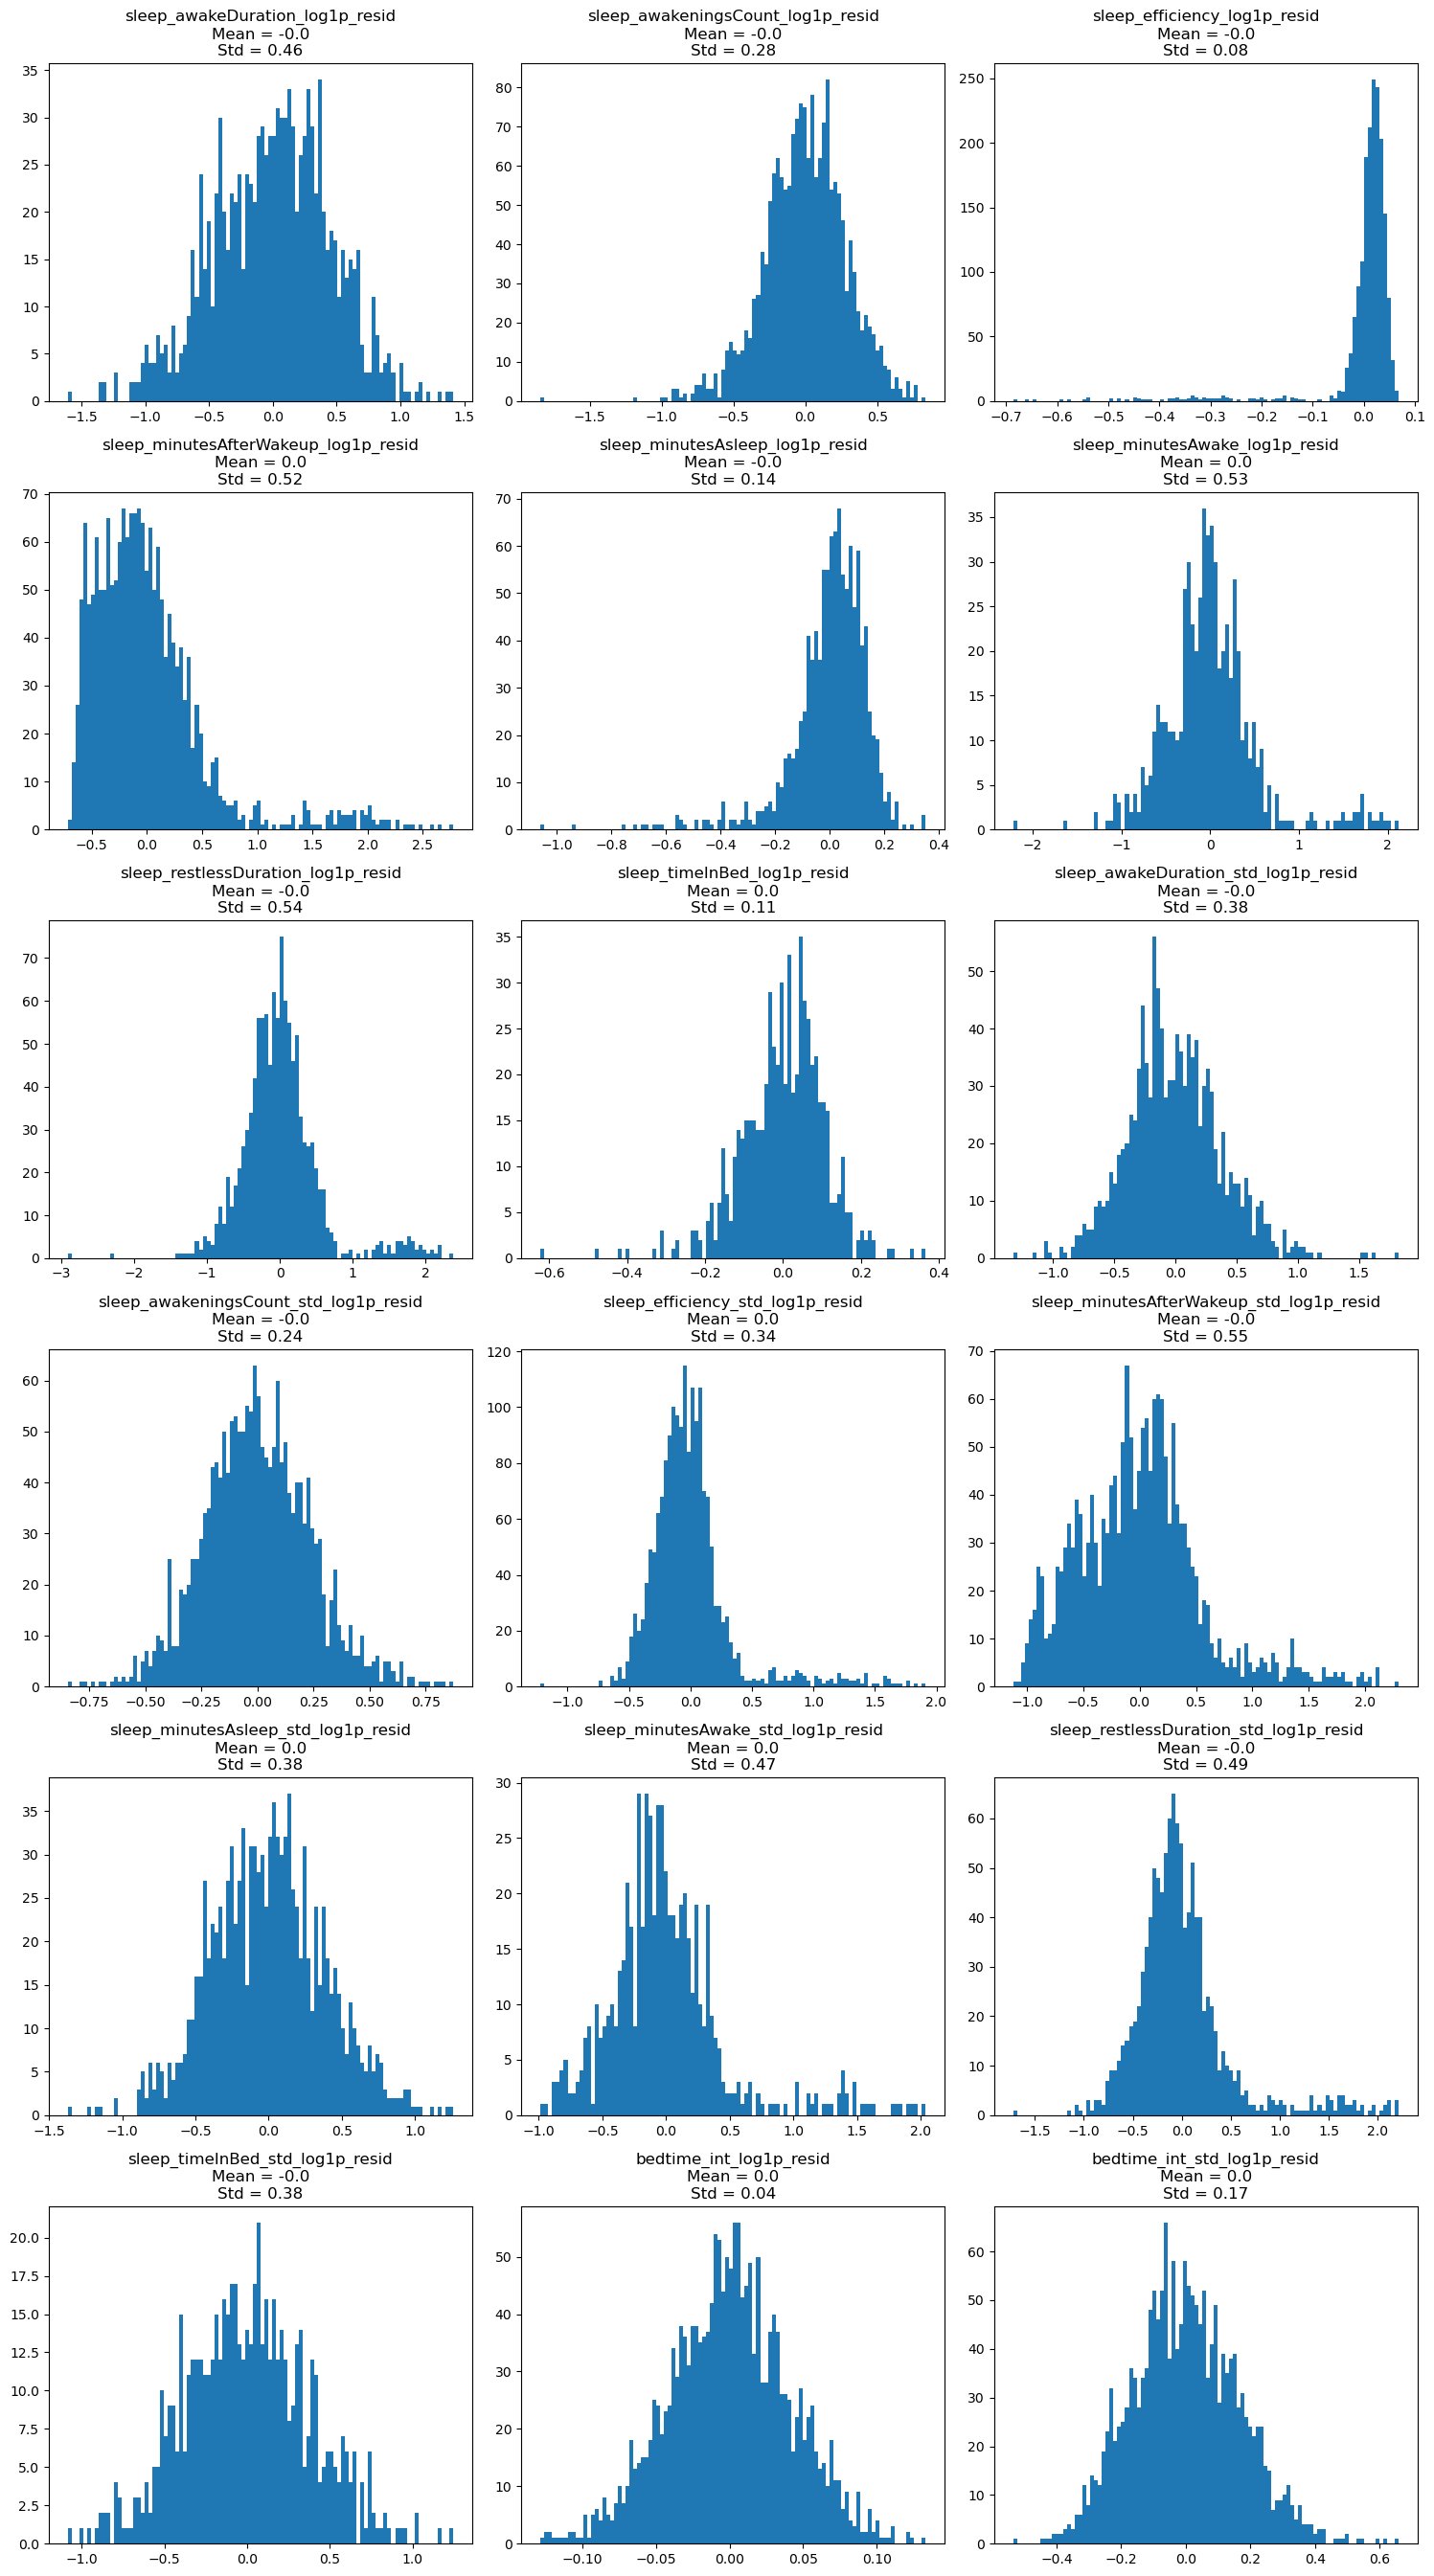

In [23]:
plot_histograms(sleep_merged, features_dict['sleep_features_log1p_resids'])

# Add in microbiome features (binarized microbes, CLR transformed microbes, alpha diversities)

### Add in the microbiome vendor from the Arivale microbiome diversity snapshot

In [24]:
# Add in the microbiome vendor
microbe_vendor = get_snapshot('microbiome_diversity')

In [25]:
# For some reason the snapshot has duplicated public_client_id and days_in_program paired rows
# Good news is that vendor_dashboard is the same value across all duplicate pairs
# We will NOT be using the calculated alpha diversities
dupes = microbe_vendor[microbe_vendor.duplicated(['public_client_id', 'days_in_program'], keep=False)].sort_values(['public_client_id', 'days_in_program'])
dupes

,public_client_id,vendor_observation_id,vendor_dashboard,client_id,vendor_research,days_in_program,days_since_first_call,days_since_first_draw,month,weekday,...,observed_otus_30000,observed_otus_50000,shannon_100000,shannon_20000,shannon_30000,shannon_50000,simpson_100000,simpson_20000,simpson_30000,simpson_50000
379,01074934,22001612562176,research-microbiome,278.0,amagis,1138.0,1123.0,1123.0,Aug,Sat,...,465.0,576.2,3.826866,3.809537,3.816468,3.819241,0.946,0.947,0.946,0.946
380,01074934,22001805511422,research-microbiome,278.0,amagis,1138.0,1123.0,1123.0,Aug,Sat,...,456.2,554.3,4.142941,4.126998,4.133930,4.136009,0.963,0.963,0.963,0.963
1738,01338813,22001805510462,research-microbiome,181392.0,amagis,551.0,546.0,545.0,Dec,Wed,...,442.6,548.6,3.403353,3.389490,3.395035,3.404046,0.913,0.912,0.913,0.913
1739,01338813,22001805511005,research-microbiome,181392.0,amagis,551.0,546.0,545.0,Dec,Wed,...,435.0,550.8,3.774880,3.756165,3.765869,3.770028,0.948,0.947,0.948,0.948
3097,01600788,22001805510257,research-microbiome,158265.0,amagis,660.0,574.0,659.0,Oct,Wed,...,578.2,694.0,4.201165,4.192154,4.190075,4.198392,0.967,0.967,0.967,0.967
3098,01600788,22001805510757,research-microbiome,158265.0,amagis,660.0,574.0,659.0,Oct,Wed,...,704.1,855.2,4.466640,4.444460,4.452084,4.461788,0.976,0.976,0.976,0.976
3877,01766399,22001805510736,research-microbiome,278040.0,amagis,98.0,84.0,74.0,Feb,Fri,...,642.1,766.3,4.407030,4.393167,4.398019,4.400791,0.970,0.970,0.970,0.970
3878,01766399,22001805521396,research-microbiome,278040.0,amagis,98.0,84.0,74.0,Feb,Fri,...,632.6,759.9,4.444460,4.429210,4.431290,4.437528,0.973,0.973,0.973,0.972
5070,HX090706,22001701512377,research-microbiome,246641.0,amagis,73.0,17.0,14.0,May,Fri,...,607.7,742.1,4.106204,4.088182,4.097886,4.102045,0.962,0.962,0.962,0.962
5071,HX090706,22001803513572,research-microbiome,246641.0,amagis,73.0,17.0,14.0,May,Fri,...,586.5,718.8,4.124919,4.107590,4.115908,4.116601,0.962,0.962,0.962,0.962


In [26]:
microbe_vendor.shape

(5237, 37)

In [27]:
sleep_merged.shape

(1796, 132)

In [28]:
sleep_merged = sleep_merged.merge(microbe_vendor[['public_client_id', 'days_in_program', 'vendor_dashboard']].drop_duplicates(), on=['public_client_id', 'days_in_program'], how='left')

In [29]:
# Rename vendor_dashboard to microbiome_vendor
sleep_merged = sleep_merged.rename(columns={'vendor_dashboard': 'microbiome_vendor'})

In [30]:
sleep_merged.microbiome_vendor.info()

<class 'pandas.core.series.Series'>
RangeIndex: 1796 entries, 0 to 1795
Series name: microbiome_vendor
Non-Null Count  Dtype 
--------------  ----- 
1796 non-null   object
dtypes: object(1)
memory usage: 14.2+ KB


In [31]:
sleep_merged.microbiome_vendor.value_counts()

microbiome_vendor
research-microbiome    1231
Second Genome           565
Name: count, dtype: int64

In [32]:
# Add the microbiome_vendor to the features_dict
features_dict['vendor_features'] = ['microbiome_vendor']

### Open and prepare to merge the microbe rarefied count table (for binarized microbes) and microbe count table (not rarefied, for CLR microbes) onto sleep_merged

In [33]:
microbe_raref_count = pd.read_csv('independent_feature_dataframes/rarefied_count_table_genera_crystal_code_01_28_2026.csv', dtype={'Unnamed: 0': object})
microbe_raref_count = microbe_raref_count.rename(columns={'Unnamed: 0': 'public_client_id'})

In [34]:
microbe_raref_count

,public_client_id,Archaea_Euryarchaeota_Methanobacteria_Methanobacteriales_Methanobacteriaceae_Methanobrevibacter,Archaea_Euryarchaeota_Methanobacteria_Methanobacteriales_Methanobacteriaceae_Methanosphaera,Archaea_Euryarchaeota_Methanobacteria_Methanobacteriales_Methanobacteriaceae_nan,Archaea_Euryarchaeota_Thermoplasmata_Methanomassiliicoccales_Methanomassiliicoccaceae_Methanomassiliicoccus,Archaea_Euryarchaeota_Thermoplasmata_Methanomassiliicoccales_Methanomethylophilaceae_Candidatus_Methanogranum,Archaea_Euryarchaeota_Thermoplasmata_Methanomassiliicoccales_Methanomethylophilaceae_Candidatus_Methanomethylophilus,Archaea_Euryarchaeota_Thermoplasmata_Methanomassiliicoccales_Methanomethylophilaceae_nan,Bacteria_Actinobacteria_Acidimicrobiia_Microtrichales_nan_nan,Bacteria_Actinobacteria_Actinobacteria_Actinomycetales_Actinomycetaceae_Actinobaculum,...,Bacteria_Verrucomicrobia_Verrucomicrobiae_Opitutales_Puniceicoccaceae_nan,Bacteria_Verrucomicrobia_Verrucomicrobiae_Pedosphaerales_Pedosphaeraceae_nan,Bacteria_Verrucomicrobia_Verrucomicrobiae_Verrucomicrobiales_Akkermansiaceae_Akkermansia,Bacteria_Verrucomicrobia_Verrucomicrobiae_Verrucomicrobiales_nan_nan,Bacteria_Verrucomicrobia_Verrucomicrobiae_nan_nan_nan,Eukaryota_Euglenozoa_Euglenida_Aphagea_Aphagea_fa_Distigma,Eukaryota_Euglenozoa_Euglenida_Aphagea_Aphagea_fa_nan,Eukaryota_Euglenozoa_Euglenida_nan_nan_nan,Eukaryota_Incertae_Sedis_Incertae_Sedis_cl_Incertae_Sedis_or_Incertae_Sedis_fa_Blastocystis,Eukaryota_Parabasalia_Tritrichomonadea_Tritrichomonadea_or_Tritrichomonadea_fa_Dientamoeba
0,01602320,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,01228476,849,201,0,0,0,0,0,0,0,...,0,0,88,0,0,0,0,0,0,0
2,01788725,0,0,0,0,0,0,0,0,0,...,0,0,45,0,0,0,0,0,0,0
3,01421882,0,0,0,0,0,0,0,0,0,...,0,0,140,0,0,0,0,0,0,0
4,01048590,0,0,0,0,0,0,0,0,0,...,0,0,111,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2207,01946056,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2208,01294182,0,0,0,0,0,0,0,0,0,...,0,0,6,0,0,0,0,0,0,0
2209,01323214,54,0,0,0,0,0,0,0,0,...,39,0,18,0,0,0,0,0,0,0
2210,01395120,0,0,0,0,0,0,0,0,0,...,0,0,126,0,0,0,0,0,0,0


In [35]:
microbe_raref_count.public_client_id.nunique()

2212

In [36]:
microbe_raref_count.shape

(2212, 601)

In [37]:
microbe_count = pd.read_csv('independent_feature_dataframes/crystal_arivale_16S_genera_counts_subsetted_for_sleep_merged_10_14_2025.csv', dtype={'public_client_id': object})
microbe_count = microbe_count.drop(columns='Unnamed: 0')

In [38]:
import re
# Clean column names to repalce any non alphanumeric characters with an underscore
# When you import certain column names into R it changes some of the special characters to dots
# This way the rarefied and nonrarefied count table are back in their matching column names
microbe_raref_count.columns = [re.sub(r'\W+', '_', col) for col in microbe_raref_count.columns]
microbe_count.columns = [re.sub(r'\W+', '_', col) for col in microbe_count.columns]

In [39]:
set1 = set(microbe_raref_count.columns[1:])
set2 = set(microbe_count.columns[2:])

In [40]:
set2 - set1

set()

In [41]:
# Great, the column names are now the same
set1 - set2

set()

In [42]:
microbe_features = microbe_count.columns[2:].tolist()
microbe_binarized_features = [f'{microbe_feature}_binarized' for microbe_feature in microbe_features]

### Binarized Microbe

In [43]:
measure_microbe_binary = microbe_raref_count.copy()
measure_microbe_binary.rename(
    columns={col: f"{col}_binarized" for col in microbe_features},
    inplace=True
)
#microbe_binarized_features = [f'{microbe_feature}_binarized' for microbe_feature in microbe_features]
measure_microbe_binary[microbe_binarized_features] = (measure_microbe_binary[microbe_binarized_features] > 0).astype(int)

In [44]:
# Proportion of 1s in each microbe feature
prop_1s = measure_microbe_binary[microbe_binarized_features].mean()

# Mask for features with 1s between 10% and 90%
mask = (prop_1s > 0.1) & (prop_1s < 0.9)

# Keep only features that pass the mask
microbe_features_binary_10_90 = prop_1s[mask].index.tolist()
print(len(microbe_features_binary_10_90))

150


<Axes: >

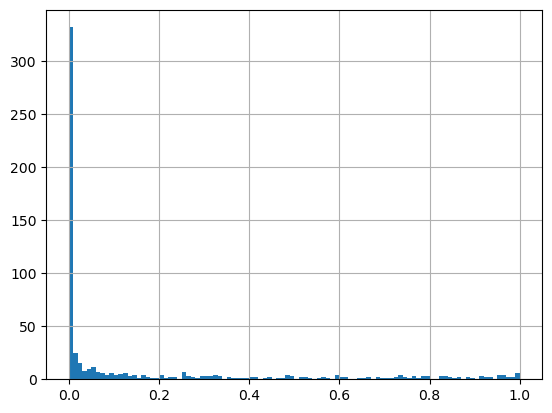

In [45]:
prop_1s.hist(bins=100)

In [46]:
sleep_merged[['days_in_program', 'reference_microbe_dip']]

,days_in_program,reference_microbe_dip
0,1.0,1.0
1,1.0,1.0
2,1.0,1.0
3,1.0,1.0
4,1.0,1.0
...,...,...
1791,435.0,435.0
1792,523.0,523.0
1793,530.0,530.0
1794,773.0,773.0


In [47]:
measure_microbe_binary

,public_client_id,Archaea_Euryarchaeota_Methanobacteria_Methanobacteriales_Methanobacteriaceae_Methanobrevibacter_binarized,Archaea_Euryarchaeota_Methanobacteria_Methanobacteriales_Methanobacteriaceae_Methanosphaera_binarized,Archaea_Euryarchaeota_Methanobacteria_Methanobacteriales_Methanobacteriaceae_nan_binarized,Archaea_Euryarchaeota_Thermoplasmata_Methanomassiliicoccales_Methanomassiliicoccaceae_Methanomassiliicoccus_binarized,Archaea_Euryarchaeota_Thermoplasmata_Methanomassiliicoccales_Methanomethylophilaceae_Candidatus_Methanogranum_binarized,Archaea_Euryarchaeota_Thermoplasmata_Methanomassiliicoccales_Methanomethylophilaceae_Candidatus_Methanomethylophilus_binarized,Archaea_Euryarchaeota_Thermoplasmata_Methanomassiliicoccales_Methanomethylophilaceae_nan_binarized,Bacteria_Actinobacteria_Acidimicrobiia_Microtrichales_nan_nan_binarized,Bacteria_Actinobacteria_Actinobacteria_Actinomycetales_Actinomycetaceae_Actinobaculum_binarized,...,Bacteria_Verrucomicrobia_Verrucomicrobiae_Opitutales_Puniceicoccaceae_nan_binarized,Bacteria_Verrucomicrobia_Verrucomicrobiae_Pedosphaerales_Pedosphaeraceae_nan_binarized,Bacteria_Verrucomicrobia_Verrucomicrobiae_Verrucomicrobiales_Akkermansiaceae_Akkermansia_binarized,Bacteria_Verrucomicrobia_Verrucomicrobiae_Verrucomicrobiales_nan_nan_binarized,Bacteria_Verrucomicrobia_Verrucomicrobiae_nan_nan_nan_binarized,Eukaryota_Euglenozoa_Euglenida_Aphagea_Aphagea_fa_Distigma_binarized,Eukaryota_Euglenozoa_Euglenida_Aphagea_Aphagea_fa_nan_binarized,Eukaryota_Euglenozoa_Euglenida_nan_nan_nan_binarized,Eukaryota_Incertae_Sedis_Incertae_Sedis_cl_Incertae_Sedis_or_Incertae_Sedis_fa_Blastocystis_binarized,Eukaryota_Parabasalia_Tritrichomonadea_Tritrichomonadea_or_Tritrichomonadea_fa_Dientamoeba_binarized
0,01602320,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,01228476,1,1,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
2,01788725,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
3,01421882,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
4,01048590,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2207,01946056,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2208,01294182,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
2209,01323214,1,0,0,0,0,0,0,0,0,...,1,0,1,0,0,0,0,0,0,0
2210,01395120,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0


In [48]:
sleep_merged.shape

(1796, 133)

In [49]:
# merge the transformed microbes onto sleep_merged, which is cleaned fitbit scheme24
# that already has covariates merged on
sleep_merged = pd.merge(sleep_merged, measure_microbe_binary, on='public_client_id')

In [50]:
# Great, another 600 columns were added for the binarized microbe features!
sleep_merged.shape

(1796, 733)

In [51]:
sleep_merged[microbe_binarized_features].mean().describe()

count    600.000000
mean       0.158078
std        0.280220
min        0.000000
25%        0.000557
50%        0.006125
75%        0.160774
max        1.000000
dtype: float64

#### Update features_dict with new main features set (ie binarized_microbe_features)
Don't need to save vendor bc there weren't multiple vendors for this set of microbe samples, also don't need to add a dip bc already did that above "reference_microbe_dip" in the sleep_disorder section above

In [52]:
microbe_binarized_features

['Archaea_Euryarchaeota_Methanobacteria_Methanobacteriales_Methanobacteriaceae_Methanobrevibacter_binarized',
 'Archaea_Euryarchaeota_Methanobacteria_Methanobacteriales_Methanobacteriaceae_Methanosphaera_binarized',
 'Archaea_Euryarchaeota_Methanobacteria_Methanobacteriales_Methanobacteriaceae_nan_binarized',
 'Archaea_Euryarchaeota_Thermoplasmata_Methanomassiliicoccales_Methanomassiliicoccaceae_Methanomassiliicoccus_binarized',
 'Archaea_Euryarchaeota_Thermoplasmata_Methanomassiliicoccales_Methanomethylophilaceae_Candidatus_Methanogranum_binarized',
 'Archaea_Euryarchaeota_Thermoplasmata_Methanomassiliicoccales_Methanomethylophilaceae_Candidatus_Methanomethylophilus_binarized',
 'Archaea_Euryarchaeota_Thermoplasmata_Methanomassiliicoccales_Methanomethylophilaceae_nan_binarized',
 'Bacteria_Actinobacteria_Acidimicrobiia_Microtrichales_nan_nan_binarized',
 'Bacteria_Actinobacteria_Actinobacteria_Actinomycetales_Actinomycetaceae_Actinobaculum_binarized',
 'Bacteria_Actinobacteria_Actinob

In [53]:
features_dict['new_microbe_binarized_features'] = microbe_binarized_features
features_dict['new_microbe_features_binary_10_90'] = microbe_features_binary_10_90

In [54]:
list(features_dict.keys())

['heartrate_features',
 'activity_features',
 'sleep_features',
 'covariate_features',
 'sleep_features_log1p',
 'sleep_features_log1p_resids',
 'activity_features_resids',
 'heartrate_features_resids',
 'vendor_features',
 'new_microbe_binarized_features',
 'new_microbe_features_binary_10_90']

### CLR Transformed Microbes

In [55]:
# find the minimum relative abundance across the entire df
measure_microbe = microbe_count.copy()
min_microbe_count = measure_microbe[microbe_features].replace(0, np.nan).min().min()

In [56]:
# the floral paper suggested doing the minimum divided by 2
min_microbe_count/2

0.5

In [57]:
# I'll use 0.5 as the pseudocount for the zeroes

In [58]:
# DO THIS ONE NEW JAN 30 2025
# CLR transform 
# First CLR transform the microbes then find the original zeroes and replace with Nan

#save a copy of the untransformed df so that you can reference it to find the 0s after the CLR transform
measure_microbe_original = measure_microbe.copy()

#convert 0s to the 0.5 pseudocount that we determined above
measure_microbe[microbe_features] = measure_microbe[microbe_features] + 0.5
measure_microbe['gmean'] = measure_microbe[microbe_features].apply(scipy.stats.mstats.gmean, axis=1,
                                                             nan_policy='raise')

#finish the CLR transform: divide by gmean and log transform
measure_microbe[list(microbe_features) + ["gmean"]] = np.log(measure_microbe[list(microbe_features) + ["gmean"]].divide(measure_microbe["gmean"], axis=0))

# check that the CLR worked, summing the gmean column should print 0 since ln(1) = 0
print(measure_microbe.gmean.sum())
measure_microbe.drop(columns='gmean', inplace=True)

# reference the untransformed measure_microbe_original to find the zeroes
# make a boolean mask that we can use later to identify the zeroes in the transformed
# data after imputing pseudocount and doing the CLR transform
zero_mask = measure_microbe_original[microbe_features] == 0

# use the zero_mask to replace anywhere that was originally a 0 with np.nan
measure_microbe[microbe_features] = measure_microbe[microbe_features].mask(zero_mask, np.nan)

0.0


In [59]:
len(microbe_features)

600

In [60]:
sleep_merged.shape

(1796, 733)

In [61]:
# merge the new transformed microbes onto sleep_merged
sleep_merged = pd.merge(sleep_merged, measure_microbe, on=['public_client_id', 'days_in_program'])

In [62]:
# 600 new columns were added, great!
sleep_merged.shape

(1796, 1333)

In [63]:
features_dict['new_microbe_features'] = microbe_features

### Alpha Diversities

In [64]:
alpha_divs = pd.read_csv('independent_feature_dataframes/alpha_divs_rarefied_crystal_code_01_29_2026.csv', dtype={'public_client_id': object})

In [65]:
diversity_features = alpha_divs.columns[1:].tolist()

In [66]:
sleep_merged = pd.merge(sleep_merged, alpha_divs, on=['public_client_id'])

In [67]:
features_dict['diversity_features'] = diversity_features

# Add blood metabolomics

In [68]:
#metabolome df
metabolites_df = get_snapshot("metabolomics_corrected")
dont_rename = metabolites_df.columns[:8]
metabolites_df = metabolites_df.rename(columns={col:'metabolite_' + col for col in metabolites_df.columns if col not in dont_rename})
metabolite_features = metabolites_df.columns[8:].tolist()
measure_metabolite = metabolites_df[["public_client_id", "days_in_program", "sample_id"] + metabolite_features]
measure_metabolite = measure_metabolite.rename(columns={"sample_id": "blood_sample_id"})
measure_metabolite.days_in_program = measure_metabolite.days_in_program.astype("float64")
measure_metabolite = measure_metabolite.sort_values(by="days_in_program")
measure_metabolite["metabolite_dip"] = measure_metabolite["days_in_program"]

In [69]:
measure_metabolite.shape

(3305, 1300)

In [70]:
# no vendor column for metabolites!! probably all by the same vendor/company
metabolites_df.filter(like='vendor').columns

Index([], dtype='object')

In [71]:
# Keep this, might be useful later when looking at clinical chem?
measure_metabolite["blood_sample_id"].value_counts()

blood_sample_id
A384BN840-008    1
A926BI442-002    1
A000AV155-002    1
A422AU094-002    1
A391BM997-002    1
                ..
A197AX168-002    1
A132BK565-002    1
A197AX065-002    1
A196AX875-002    1
A203BA131-003    1
Name: count, Length: 3305, dtype: int64

In [72]:
# sort by days_in_program for the merge below
sleep_merged = sleep_merged.sort_values(by='days_in_program')
measure_metabolite = measure_metabolite.sort_values(by='days_in_program')

In [73]:
# Merge the metabolites onto sleep merged
sleep_merged = pd.merge_asof(
    sleep_merged,
    measure_metabolite[
        measure_metabolite.public_client_id.isin(sleep_merged.public_client_id)
    ],
    by="public_client_id",
    on="days_in_program",
    direction="nearest",
    tolerance=15
)

In [74]:
sleep_merged.shape

(1796, 2634)

### Update features_dict with dip and new main features set (ie metabolite_features)

In [75]:
sleep_merged.filter(like='dip').columns

Index(['fitbit_dip', 'reference_microbe_dip', 'reference_fitbit_dip',
       'fitbit_dip_std', 'weights_dip',
       'Bacteria_Actinobacteria_Actinobacteria_Propionibacteriales_Propionibacteriaceae_Acidipropionibacterium_binarized',
       'Bacteria_Actinobacteria_Actinobacteria_Propionibacteriales_Propionibacteriaceae_Acidipropionibacterium',
       'metabolite_dip'],
      dtype='object')

In [76]:
features_dict['dip_features'] = ['reference_microbe_dip',
 'weights_dip',
 'fitbit_dip',
 'metabolite_dip']

In [77]:
# check that it worked:
features_dict['dip_features']

['reference_microbe_dip', 'weights_dip', 'fitbit_dip', 'metabolite_dip']

In [78]:
features_dict['metabolite_features'] = metabolite_features

In [79]:
features_dict.keys()

dict_keys(['heartrate_features', 'activity_features', 'sleep_features', 'covariate_features', 'sleep_features_log1p', 'sleep_features_log1p_resids', 'activity_features_resids', 'heartrate_features_resids', 'vendor_features', 'new_microbe_binarized_features', 'new_microbe_features_binary_10_90', 'new_microbe_features', 'diversity_features', 'dip_features', 'metabolite_features'])

# Add in diet features

In [80]:
import pandas as pd

diet = pd.read_csv('independent_feature_dataframes/diet_collapsed_crystal_jacob_03-21-2025.csv', dtype={'public_client_id': object})
diet.rename(columns={'response_percentage': 'response_pct'}, inplace=True)
diet['response_pct'] = diet.response_pct * 100

In [81]:
diet

,public_client_id,vendor,days_in_program,assessment:lifestyle:achohol_type:enum,assessment:diet:alcohol_preference:int,assessment:lifestyle:alcohol_days_a_week:enum,assessment:diet:freq_alcohol:int,assessment:lifestyle:breakfast:enum,assessment:lifestyle:cruciferous_vegetables:enum,assessment:lifestyle:snack:enum,...,assessment:diet:freq_white_fish:int,assessment:diet:freq_yogurt:int,assessment:diet:milk:int,assessment:diet:salt_in_food:int,assessment:diet:slices_of_bread:int,assessment:diet:spread:int,assessment:diet:sugar:int,assessment:diet:sugar_coffee:int,assessment:lifestyle:grains:enum,response_pct
0,01000261,Health 123,37.0,(2) Wine,NaN,(3) 5-6 days,NaN,(0) Daily,(1) 3-4 times per week,(0) Daily,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,(0) Zero/less than 1 per day,23.214286
1,01000552,Assessments,0.0,(2) Wine,(2) Wine,(2) 3-4 days,(4) 2-4 times per week,(1) 3-4 times per week,(3) Once per month,(2) Once per week,...,(3) Once per week,(2) 1-3 times per month,(2) 1-2%,(3) Taste food but only occasionally add salt,(2) 1,(4) Other,(2) No,(3) Yes,(1) 1-2,100.000000
2,01001181,Assessments,0.0,NaN,(7) I do not drink alcohol,(0) I do not drink,(1) Less than once per month,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23.214286
3,01001298,Assessments,0.0,(3) Liquor,(3) Liquor,(2) 3-4 days,(4) 2-4 times per week,(0) Daily,(0) Daily,(0) Daily,...,(4) 2-4 times per week,(2) 1-3 times per month,(7) Do not drink milk,(4) Rarely or never add salt to food,(1) Less than 1,(4) Other,(2) No,(2) No,(1) 1-2,100.000000
4,01001467,Assessments,0.0,(3) Liquor,(3) Liquor,NaN,(2) 1-3 times per month,(0) Daily,(3) Once per month,(0) Daily,...,(2) 1-3 times per month,(3) Once per week,(3) Skimmed,(1) Generally add salt to food without tasting...,(2) 1,(1) Butter,(1) I don't drink tea,(1) I don't drink coffee,(2) 3-4,98.214286
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7690,QIRL,Assessments,903.0,(2) Wine,(2) Wine,(2) 3-4 days,(4) 2-4 times per week,(0) Daily,(1) 3-4 times per week,(0) Daily,...,(1) Less than once per month,(3) Once per week,(3) Skimmed,(4) Rarely or never add salt to food,(1) Less than 1,(3) Low fat spread,(2) No,(1) I don't drink coffee,NaN,96.428571
7691,ZU273983,Assessments,1.0,(3) Liquor,(3) Liquor,NaN,(2) 1-3 times per month,(2) Once per week,(1) 3-4 times per week,(0) Daily,...,(1) Less than once per month,(1) Less than once per month,(7) Do not drink milk,(4) Rarely or never add salt to food,(3) 2-3,(1) Butter,(1) I don't drink tea,(1) I don't drink coffee,(2) 3-4,98.214286
7692,ZU612255,Assessments,0.0,(3) Liquor,(3) Liquor,(0) I do not drink,(1) Less than once per month,(0) Daily,(1) 3-4 times per week,(1) 3-4 times per week,...,(1) Less than once per month,(1) Less than once per month,(4) Other kind,(4) Rarely or never add salt to food,(3) 2-3,(4) Other,(1) I don't drink tea,(3) Yes,(0) Zero/less than 1 per day,100.000000
7693,ZU621944,Assessments,4.0,NaN,(4) Other kind,(0) I do not drink,(1) Less than once per month,(1) 3-4 times per week,(2) Once per week,(1) 3-4 times per week,...,(1) Less than once per month,(3) Once per week,(4) Other kind,(4) Rarely or never add salt to food,(3) 2-3,(1) Butter,(2) No,(2) No,(1) 1-2,98.214286


In [82]:
diet.shape

(7695, 59)

In [83]:
diet[diet.response_pct >= 90].shape

(3810, 59)

In [84]:
diet[diet.response_pct >= 90].public_client_id.nunique()

3060

In [85]:
# only keep data points where >= 90% of the questionnaires were responded to
diet = diet[diet.response_pct >= 90]

In [86]:
# Clean up the column names
def clean_column_name(col):
    col = col.removeprefix("assessment:")  # Remove 'assessment:'
    #col = col.removesuffix(":enum")  # Remove ':enum'
    col = col.replace(":", "_")  # Replace colons with underscores
    return col

# Apply renaming
diet.columns = [clean_column_name(col) for col in diet.columns]

In [87]:
diet.columns

Index(['public_client_id', 'vendor', 'days_in_program',
       'lifestyle_achohol_type_enum', 'diet_alcohol_preference_int',
       'lifestyle_alcohol_days_a_week_enum', 'diet_freq_alcohol_int',
       'lifestyle_breakfast_enum', 'lifestyle_cruciferous_vegetables_enum',
       'lifestyle_snack_enum', 'lifestyle_fruits_enum',
       'lifestyle_vegetables_enum', 'lifestyle_sugary_drinks_enum',
       'lifestyle_water_enum', 'diet_freq_water_int',
       'diet_cookies_cakes_scones_int', 'diet_freq_caffeinated_beverages_int',
       'lifestyle_alcohol_drinks_a_day_enum', 'lifestyle_diet_enum',
       'diet_freq_breakfast_int', 'diet_freq_cruciferous_vegetables_int',
       'diet_freq_snacking_int', 'diet_freq_fresh_fruit_int',
       'diet_freq_raw_vegetables_salad_int', 'diet_freq_soft_drinks_int',
       'diet_avoid_dairy_int', 'diet_bread_int', 'diet_breakfast_cereal_int',
       'diet_freq_beans_legumes_int', 'diet_freq_breakfast_cereal_int',
       'diet_freq_cheese_int', 'diet_freq_c

In [88]:
diet.vendor.value_counts()

vendor
Assessments      3777
Self Reported      33
Name: count, dtype: int64

### First deal with the food freq questions and merge diet onto sleep_merged

In [89]:
food_freq_features = diet.filter(like='freq').columns.tolist()
food_freq_features

['diet_freq_alcohol_int',
 'diet_freq_water_int',
 'diet_freq_caffeinated_beverages_int',
 'diet_freq_breakfast_int',
 'diet_freq_cruciferous_vegetables_int',
 'diet_freq_snacking_int',
 'diet_freq_fresh_fruit_int',
 'diet_freq_raw_vegetables_salad_int',
 'diet_freq_soft_drinks_int',
 'diet_freq_beans_legumes_int',
 'diet_freq_breakfast_cereal_int',
 'diet_freq_cheese_int',
 'diet_freq_cook_home_int',
 'diet_freq_cooked_green_vegetables_int',
 'diet_freq_cooked_root_vegetables_int',
 'diet_freq_eating_out_int',
 'diet_freq_eggs_int',
 'diet_freq_french_fries_int',
 'diet_freq_fruit_juice_int',
 'diet_freq_ice_cream_int',
 'diet_freq_meat_int',
 'diet_freq_nuts_seeds_int',
 'diet_freq_oil_rich_fish_int',
 'diet_freq_pastries_int',
 'diet_freq_plant_based_protein_int',
 'diet_freq_potatoes_pasta_rice_int',
 'diet_freq_poultry_int',
 'diet_freq_processed_meat_int',
 'diet_freq_savory_snacks_int',
 'diet_freq_sweets_chocolates_int',
 'diet_freq_white_fish_int',
 'diet_freq_yogurt_int']

In [90]:
for feature in food_freq_features:
    print('')
    print('')
    print(feature)
    print(sorted(diet[feature].dropna().unique()))



diet_freq_alcohol_int
['(1) Less than once per month', '(2) 1-3 times per month', '(3) Once per week', '(4) 2-4 times per week', '(5) 5-6 times per week', '(6) Once per day', '(7) 2-3 times per day', '(8) 4-5 times per day', '(9) 6+ times per day']


diet_freq_water_int
['(1) Less than once per month', '(2) 1-3 times per month', '(3) Once per week', '(4) 2-4 times per week', '(5) 5-6 times per week', '(6) Once per day', '(7) 2-3 times per day', '(8) 4-5 times per day', '(9) 6+ times per day']


diet_freq_caffeinated_beverages_int
['(1) Less than once per month', '(2) 1-3 times per month', '(3) Once per week', '(4) 2-4 times per week', '(5) 5-6 times per week', '(6) Once per day', '(7) 2-3 times per day', '(8) 4-5 times per day', '(9) 6+ times per day']


diet_freq_breakfast_int
['(1) Less than once per month', '(2) 1-3 times per month', '(3) Once per week', '(4) 2-4 times per week', '(5) 5-6 times per week', '(6) Once per day', '(7) 2-3 times per day', '(8) 4-5 times per day', '(9) 6

In [91]:
diet[food_freq_features].info()

<class 'pandas.core.frame.DataFrame'>
Index: 3810 entries, 1 to 7694
Data columns (total 32 columns):
 #   Column                                 Non-Null Count  Dtype 
---  ------                                 --------------  ----- 
 0   diet_freq_alcohol_int                  3810 non-null   object
 1   diet_freq_water_int                    3810 non-null   object
 2   diet_freq_caffeinated_beverages_int    3807 non-null   object
 3   diet_freq_breakfast_int                3810 non-null   object
 4   diet_freq_cruciferous_vegetables_int   3810 non-null   object
 5   diet_freq_snacking_int                 3810 non-null   object
 6   diet_freq_fresh_fruit_int              3809 non-null   object
 7   diet_freq_raw_vegetables_salad_int     3810 non-null   object
 8   diet_freq_soft_drinks_int              3810 non-null   object
 9   diet_freq_beans_legumes_int            3809 non-null   object
 10  diet_freq_breakfast_cereal_int         3809 non-null   object
 11  diet_freq_cheese_int  

#### ^^^Most questions have a response, only a few with null. Just drop the rows with nan. Also each question has the same set of responses

In [92]:
diet.shape

(3810, 59)

In [93]:
diet.dropna(subset=food_freq_features).shape

(3803, 59)

In [94]:
diet = diet.dropna(subset=food_freq_features)

In [95]:
diet.shape

(3803, 59)

In [96]:
diet.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3803 entries, 1 to 7694
Data columns (total 59 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   public_client_id                       3803 non-null   object 
 1   vendor                                 3803 non-null   object 
 2   days_in_program                        3803 non-null   float64
 3   lifestyle_achohol_type_enum            3236 non-null   object 
 4   diet_alcohol_preference_int            3803 non-null   object 
 5   lifestyle_alcohol_days_a_week_enum     3289 non-null   object 
 6   diet_freq_alcohol_int                  3803 non-null   object 
 7   lifestyle_breakfast_enum               3672 non-null   object 
 8   lifestyle_cruciferous_vegetables_enum  3781 non-null   object 
 9   lifestyle_snack_enum                   3794 non-null   object 
 10  lifestyle_fruits_enum                  3775 non-null   object 
 11  lifestyle

### Merge onto sleep_merged

In [97]:
diet_to_merge = diet.copy()
diet_to_merge['diet_dip'] = diet_to_merge.days_in_program
diet_to_merge.rename(columns={'vendor': 'diet_vendor'}, inplace=True)

In [98]:
diet_to_merge.diet_vendor.value_counts()

diet_vendor
Assessments      3772
Self Reported      31
Name: count, dtype: int64

<Axes: >

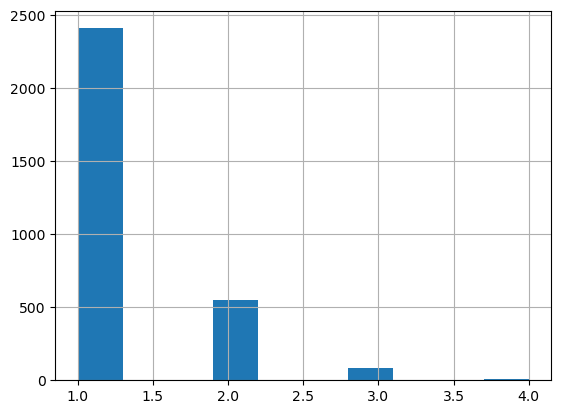

In [99]:
diet_to_merge.groupby('public_client_id').public_client_id.size().hist()

<Axes: >

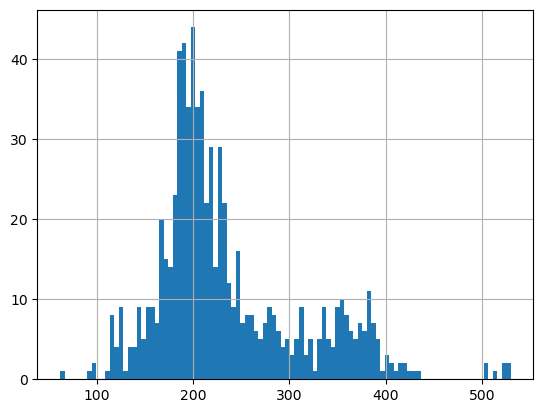

In [100]:
diet_to_merge.groupby('public_client_id')['days_in_program'].diff().hist(bins=100)

In [101]:
diet_to_merge.groupby('public_client_id')['days_in_program'].diff().describe()

count    747.000000
mean     235.430054
std       75.443716
min       62.000000
25%      188.250000
50%      211.000000
75%      270.000000
max      530.000000
Name: days_in_program, dtype: float64

In [102]:
diet_to_merge.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3803 entries, 1 to 7694
Data columns (total 60 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   public_client_id                       3803 non-null   object 
 1   diet_vendor                            3803 non-null   object 
 2   days_in_program                        3803 non-null   float64
 3   lifestyle_achohol_type_enum            3236 non-null   object 
 4   diet_alcohol_preference_int            3803 non-null   object 
 5   lifestyle_alcohol_days_a_week_enum     3289 non-null   object 
 6   diet_freq_alcohol_int                  3803 non-null   object 
 7   lifestyle_breakfast_enum               3672 non-null   object 
 8   lifestyle_cruciferous_vegetables_enum  3781 non-null   object 
 9   lifestyle_snack_enum                   3794 non-null   object 
 10  lifestyle_fruits_enum                  3775 non-null   object 
 11  lifestyle

In [103]:
# sort by days_in_program for the merge below
sleep_merged = sleep_merged.sort_values(by='days_in_program')
diet_to_merge = diet_to_merge.sort_values(by='days_in_program')

In [104]:
# Merge the diet onto sleep_merged
# decided to use 100 days as tolerance, see above, so that hopefully can get another time point for some people
sleep_merged = pd.merge_asof(
    sleep_merged,
    diet_to_merge[
        diet_to_merge.public_client_id.isin(sleep_merged.public_client_id)
    ],
    by="public_client_id",
    on="days_in_program",
    direction="nearest",
    tolerance=100
)

#### Quickly look to see how far away the diet dip are on average from microbe dip

In [105]:
sleep_merged['microbe_diet_dip_diff'] = sleep_merged.reference_microbe_dip - sleep_merged.diet_dip

<Axes: >

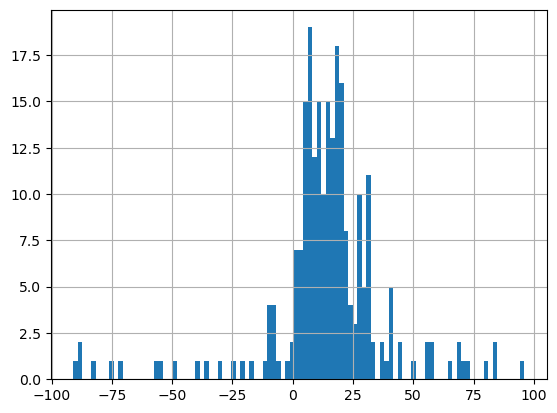

In [106]:
sleep_merged[food_freq_features + ['microbe_diet_dip_diff', 'diet_dip']].dropna(subset=['diet_dip']).microbe_diet_dip_diff.hist(bins=100)

In [107]:
sleep_merged[food_freq_features + ['days_in_program', 'diet_dip']].dropna(subset=['diet_dip']).days_in_program.describe()

count    242.000000
mean      71.764463
std       90.232792
min        5.000000
25%       15.250000
50%       29.000000
75%      104.750000
max      523.000000
Name: days_in_program, dtype: float64

In [108]:
(88-14)*1.5

111.0

In [109]:
14-111

-97

In [110]:
88+111

199

In [111]:
199-28

171

In [112]:
-97-28

-125

In [113]:
# average the distances from 1.5 IQR to the median
(125+171)/2

148.0

In [114]:
# close to 150 days, that's a long time! like 5 months. Let's just stick to 100 days for the merge
150/30

5.0

#### Update features_dict with dip and new main features set (ie food_freq_features)

In [115]:
sleep_merged.filter(like='dip').columns

Index(['fitbit_dip', 'reference_microbe_dip', 'reference_fitbit_dip',
       'fitbit_dip_std', 'weights_dip',
       'Bacteria_Actinobacteria_Actinobacteria_Propionibacteriales_Propionibacteriaceae_Acidipropionibacterium_binarized',
       'Bacteria_Actinobacteria_Actinobacteria_Propionibacteriales_Propionibacteriaceae_Acidipropionibacterium',
       'metabolite_dip', 'diet_dip', 'microbe_diet_dip_diff'],
      dtype='object')

In [116]:
features_dict['dip_features'].append('diet_dip')

In [117]:
# check that it worked:
features_dict['dip_features']

['reference_microbe_dip',
 'weights_dip',
 'fitbit_dip',
 'metabolite_dip',
 'diet_dip']

In [118]:
sleep_merged.diet_vendor.value_counts()

diet_vendor
Assessments      240
Self Reported      2
Name: count, dtype: int64

In [119]:
features_dict['vendor_features'].append('diet_vendor')

In [120]:
# check that it worked:
features_dict['vendor_features']

['microbiome_vendor', 'diet_vendor']

In [121]:
features_dict['food_freq_features'] = food_freq_features

In [122]:
features_dict['food_freq_features']

['diet_freq_alcohol_int',
 'diet_freq_water_int',
 'diet_freq_caffeinated_beverages_int',
 'diet_freq_breakfast_int',
 'diet_freq_cruciferous_vegetables_int',
 'diet_freq_snacking_int',
 'diet_freq_fresh_fruit_int',
 'diet_freq_raw_vegetables_salad_int',
 'diet_freq_soft_drinks_int',
 'diet_freq_beans_legumes_int',
 'diet_freq_breakfast_cereal_int',
 'diet_freq_cheese_int',
 'diet_freq_cook_home_int',
 'diet_freq_cooked_green_vegetables_int',
 'diet_freq_cooked_root_vegetables_int',
 'diet_freq_eating_out_int',
 'diet_freq_eggs_int',
 'diet_freq_french_fries_int',
 'diet_freq_fruit_juice_int',
 'diet_freq_ice_cream_int',
 'diet_freq_meat_int',
 'diet_freq_nuts_seeds_int',
 'diet_freq_oil_rich_fish_int',
 'diet_freq_pastries_int',
 'diet_freq_plant_based_protein_int',
 'diet_freq_potatoes_pasta_rice_int',
 'diet_freq_poultry_int',
 'diet_freq_processed_meat_int',
 'diet_freq_savory_snacks_int',
 'diet_freq_sweets_chocolates_int',
 'diet_freq_white_fish_int',
 'diet_freq_yogurt_int']

### Now look through the columns W/O freq in the column name

In [123]:
non_freq_features = [col for col in diet.columns[8:-1] if col not in food_freq_features]
non_freq_features

['lifestyle_cruciferous_vegetables_enum',
 'lifestyle_snack_enum',
 'lifestyle_fruits_enum',
 'lifestyle_vegetables_enum',
 'lifestyle_sugary_drinks_enum',
 'lifestyle_water_enum',
 'diet_cookies_cakes_scones_int',
 'lifestyle_alcohol_drinks_a_day_enum',
 'lifestyle_diet_enum',
 'diet_avoid_dairy_int',
 'diet_bread_int',
 'diet_breakfast_cereal_int',
 'diet_milk_int',
 'diet_salt_in_food_int',
 'diet_slices_of_bread_int',
 'diet_spread_int',
 'diet_sugar_int',
 'diet_sugar_coffee_int',
 'lifestyle_grains_enum']

In [124]:
for i in range(len(non_freq_features)):
    print('')
    print('')
    print(non_freq_features[i], i)
    print(sorted(diet[non_freq_features[i]].dropna().unique()))



lifestyle_cruciferous_vegetables_enum 0
['(0) Daily', '(1) 3-4 times per week', '(2) Once per week', '(3) Once per month', '(4) Less than once per month']


lifestyle_snack_enum 1
['(0) Daily', '(1) 3-4 times per week', '(2) Once per week', '(3) Once per month', '(4) Less than once per month']


lifestyle_fruits_enum 2
['(0) Zero/less than 1 per day', '(1) 1', '(2) 2-3', '(3) 4-5', '(4) 6 or more']


lifestyle_vegetables_enum 3
['(0) Zero/less than 1 per day', '(1) 1', '(2) 2-3', '(3) 4-5', '(4) 6 or more']


lifestyle_sugary_drinks_enum 4
['(0) Zero/less than 1 per day', '(1) 1', '(2) 2-3', '(3) 4-5', '(4) 6 or more']


lifestyle_water_enum 5
['(0) I don’t usually drink water', '(1) Less than 3 cups per day', '(2) 4-5 cups per day', '(3) 6-8 cups per day']


diet_cookies_cakes_scones_int 6
['(1) Less than 1', '(2) 1', '(3) 2-3', '(4) 4-5', '(5) 6 or more']


lifestyle_alcohol_drinks_a_day_enum 7
['(0) I do not drink', '(1) 1-2 drinks', '(2) 3-4 drinks', '(3) 5-6 drinks', '(4) More t

In [125]:
diet[non_freq_features].info()

<class 'pandas.core.frame.DataFrame'>
Index: 3803 entries, 1 to 7694
Data columns (total 19 columns):
 #   Column                                 Non-Null Count  Dtype 
---  ------                                 --------------  ----- 
 0   lifestyle_cruciferous_vegetables_enum  3781 non-null   object
 1   lifestyle_snack_enum                   3794 non-null   object
 2   lifestyle_fruits_enum                  3775 non-null   object
 3   lifestyle_vegetables_enum              3750 non-null   object
 4   lifestyle_sugary_drinks_enum           3794 non-null   object
 5   lifestyle_water_enum                   3795 non-null   object
 6   diet_cookies_cakes_scones_int          3796 non-null   object
 7   lifestyle_alcohol_drinks_a_day_enum    3373 non-null   object
 8   lifestyle_diet_enum                    3784 non-null   object
 9   diet_avoid_dairy_int                   3803 non-null   object
 10  diet_bread_int                         3801 non-null   object
 11  diet_breakfast_cereal_

In [126]:
# Mark down the indices of food freq Qs where the column name didn't contain freq
food_freq_indices = [0, 1, 2, 3, 4, 5, 6, 7, 14, 18]

# turn the list of indices into a list of features
food_freq_from_non_freq_features = [non_freq_features[i] for i in food_freq_indices if i < len(non_freq_features)]

In [127]:
diet[food_freq_from_non_freq_features].info()

<class 'pandas.core.frame.DataFrame'>
Index: 3803 entries, 1 to 7694
Data columns (total 10 columns):
 #   Column                                 Non-Null Count  Dtype 
---  ------                                 --------------  ----- 
 0   lifestyle_cruciferous_vegetables_enum  3781 non-null   object
 1   lifestyle_snack_enum                   3794 non-null   object
 2   lifestyle_fruits_enum                  3775 non-null   object
 3   lifestyle_vegetables_enum              3750 non-null   object
 4   lifestyle_sugary_drinks_enum           3794 non-null   object
 5   lifestyle_water_enum                   3795 non-null   object
 6   diet_cookies_cakes_scones_int          3796 non-null   object
 7   lifestyle_alcohol_drinks_a_day_enum    3373 non-null   object
 8   diet_slices_of_bread_int               3800 non-null   object
 9   lifestyle_grains_enum                  3371 non-null   object
dtypes: object(10)
memory usage: 326.8+ KB


In [128]:
sleep_merged[food_freq_from_non_freq_features]

,lifestyle_cruciferous_vegetables_enum,lifestyle_snack_enum,lifestyle_fruits_enum,lifestyle_vegetables_enum,lifestyle_sugary_drinks_enum,lifestyle_water_enum,diet_cookies_cakes_scones_int,lifestyle_alcohol_drinks_a_day_enum,diet_slices_of_bread_int,lifestyle_grains_enum
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
1791,(1) 3-4 times per week,(3) Once per month,(2) 2-3,(3) 4-5,(0) Zero/less than 1 per day,(1) Less than 3 cups per day,(1) Less than 1,(0) I do not drink,(2) 1,(2) 3-4
1792,(1) 3-4 times per week,(0) Daily,(1) 1,(2) 2-3,(0) Zero/less than 1 per day,(3) 6-8 cups per day,(2) 1,(1) 1-2 drinks,(1) Less than 1,(1) 1-2
1793,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1794,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Now convert the food freq and food freq from non freq features from categorical to a numeric daily intake

### Start with food freq

In [129]:
sleep_merged[food_freq_features].describe()

,diet_freq_alcohol_int,diet_freq_water_int,diet_freq_caffeinated_beverages_int,diet_freq_breakfast_int,diet_freq_cruciferous_vegetables_int,diet_freq_snacking_int,diet_freq_fresh_fruit_int,diet_freq_raw_vegetables_salad_int,diet_freq_soft_drinks_int,diet_freq_beans_legumes_int,...,diet_freq_oil_rich_fish_int,diet_freq_pastries_int,diet_freq_plant_based_protein_int,diet_freq_potatoes_pasta_rice_int,diet_freq_poultry_int,diet_freq_processed_meat_int,diet_freq_savory_snacks_int,diet_freq_sweets_chocolates_int,diet_freq_white_fish_int,diet_freq_yogurt_int
count,242,242,242,242,242,242,242,242,242,242,...,242,242,242,242,242,242,242,242,242,242
unique,8,7,9,8,8,9,9,9,8,8,...,8,7,9,8,7,7,7,8,7,9
top,(4) 2-4 times per week,(8) 4-5 times per day,(7) 2-3 times per day,(6) Once per day,(4) 2-4 times per week,(7) 2-3 times per day,(6) Once per day,(4) 2-4 times per week,(1) Less than once per month,(4) 2-4 times per week,...,(3) Once per week,(1) Less than once per month,(4) 2-4 times per week,(4) 2-4 times per week,(4) 2-4 times per week,(1) Less than once per month,(4) 2-4 times per week,(4) 2-4 times per week,(2) 1-3 times per month,(1) Less than once per month
freq,64,89,110,140,92,72,58,69,148,76,...,81,87,58,113,134,69,78,74,78,72


#### Below is how the integers map back to the original responses, the integer is in parentheses. And then after each entry is the computed daily numeric intake
- '(1) Less than once per month', daily intake = 0
- '(2) 1-3 times per month', 2days/month = 2/30 = 0.067
- '(3) Once per week', 1day/week = 1/7 = 0.14
- '(4) 2-4 times per week', 3days/week = 3/7 = 0.42
- '(5) 5-6 times per week', 5.5days/week = 5.5/7 = 0.79
- '(6) Once per day', 1/day = 1
- '(7) 2-3 times per day', 2.5/day = 2.5
- '(8) 4-5 times per day', 4.5/day = 4.5
- '(9) 6+ times per day' 6/day = 6

In [130]:
# make a dict to map the integers to the calculated daily intake
food_freq_daily_map = {
    '(1) Less than once per month': 0,
    '(2) 1-3 times per month': 0.067,
    '(3) Once per week': 0.14,
    '(4) 2-4 times per week': 0.42,
    '(5) 5-6 times per week': 0.79,
    '(6) Once per day': 1,
    '(7) 2-3 times per day': 2.5,
    '(8) 4-5 times per day': 4.5,
    '(9) 6+ times per day': 6
}

In [131]:
food_freq_features

['diet_freq_alcohol_int',
 'diet_freq_water_int',
 'diet_freq_caffeinated_beverages_int',
 'diet_freq_breakfast_int',
 'diet_freq_cruciferous_vegetables_int',
 'diet_freq_snacking_int',
 'diet_freq_fresh_fruit_int',
 'diet_freq_raw_vegetables_salad_int',
 'diet_freq_soft_drinks_int',
 'diet_freq_beans_legumes_int',
 'diet_freq_breakfast_cereal_int',
 'diet_freq_cheese_int',
 'diet_freq_cook_home_int',
 'diet_freq_cooked_green_vegetables_int',
 'diet_freq_cooked_root_vegetables_int',
 'diet_freq_eating_out_int',
 'diet_freq_eggs_int',
 'diet_freq_french_fries_int',
 'diet_freq_fruit_juice_int',
 'diet_freq_ice_cream_int',
 'diet_freq_meat_int',
 'diet_freq_nuts_seeds_int',
 'diet_freq_oil_rich_fish_int',
 'diet_freq_pastries_int',
 'diet_freq_plant_based_protein_int',
 'diet_freq_potatoes_pasta_rice_int',
 'diet_freq_poultry_int',
 'diet_freq_processed_meat_int',
 'diet_freq_savory_snacks_int',
 'diet_freq_sweets_chocolates_int',
 'diet_freq_white_fish_int',
 'diet_freq_yogurt_int']

In [132]:
# Make a new columns list for the new columns that will be the food_freq columns converted to daily intake using the dict above
food_freq_features_daily = [col.replace('_int', '') + '_daily' for col in food_freq_features]

In [133]:
food_freq_features_daily

['diet_freq_alcohol_daily',
 'diet_freq_water_daily',
 'diet_freq_caffeinated_beverages_daily',
 'diet_freq_breakfast_daily',
 'diet_freq_cruciferous_vegetables_daily',
 'diet_freq_snacking_daily',
 'diet_freq_fresh_fruit_daily',
 'diet_freq_raw_vegetables_salad_daily',
 'diet_freq_soft_drinks_daily',
 'diet_freq_beans_legumes_daily',
 'diet_freq_breakfast_cereal_daily',
 'diet_freq_cheese_daily',
 'diet_freq_cook_home_daily',
 'diet_freq_cooked_green_vegetables_daily',
 'diet_freq_cooked_root_vegetables_daily',
 'diet_freq_eating_out_daily',
 'diet_freq_eggs_daily',
 'diet_freq_french_fries_daily',
 'diet_freq_fruit_juice_daily',
 'diet_freq_ice_cream_daily',
 'diet_freq_meat_daily',
 'diet_freq_nuts_seeds_daily',
 'diet_freq_oil_rich_fish_daily',
 'diet_freq_pastries_daily',
 'diet_freq_plant_based_protein_daily',
 'diet_freq_potatoes_pasta_rice_daily',
 'diet_freq_poultry_daily',
 'diet_freq_processed_meat_daily',
 'diet_freq_savory_snacks_daily',
 'diet_freq_sweets_chocolates_daily

In [134]:
# add food_freq_features_daily list to features_dict
features_dict['food_freq_features_daily'] = food_freq_features_daily

In [135]:
# Now make new columns of food_freq columns to map on the daily intake
for i in range(len(features_dict['food_freq_features'])):
    sleep_merged[f"{features_dict['food_freq_features_daily'][i]}"] = sleep_merged[features_dict['food_freq_features'][i]].map(food_freq_daily_map)

In [136]:
features_dict.keys()

dict_keys(['heartrate_features', 'activity_features', 'sleep_features', 'covariate_features', 'sleep_features_log1p', 'sleep_features_log1p_resids', 'activity_features_resids', 'heartrate_features_resids', 'vendor_features', 'new_microbe_binarized_features', 'new_microbe_features_binary_10_90', 'new_microbe_features', 'diversity_features', 'dip_features', 'metabolite_features', 'food_freq_features', 'food_freq_features_daily'])

In [137]:
sleep_merged[features_dict['food_freq_features_daily']]

,diet_freq_alcohol_daily,diet_freq_water_daily,diet_freq_caffeinated_beverages_daily,diet_freq_breakfast_daily,diet_freq_cruciferous_vegetables_daily,diet_freq_snacking_daily,diet_freq_fresh_fruit_daily,diet_freq_raw_vegetables_salad_daily,diet_freq_soft_drinks_daily,diet_freq_beans_legumes_daily,...,diet_freq_oil_rich_fish_daily,diet_freq_pastries_daily,diet_freq_plant_based_protein_daily,diet_freq_potatoes_pasta_rice_daily,diet_freq_poultry_daily,diet_freq_processed_meat_daily,diet_freq_savory_snacks_daily,diet_freq_sweets_chocolates_daily,diet_freq_white_fish_daily,diet_freq_yogurt_daily
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1791,0.00,2.5,0.0,0.0,0.42,0.067,1.00,1.00,0.0,0.42,...,0.00,0.000,0.790,0.42,0.00,0.0,0.42,0.420,0.00,0.14
1792,0.42,6.0,1.0,6.0,0.42,6.000,0.42,0.79,0.0,0.42,...,0.42,0.067,0.067,0.42,0.42,0.0,0.42,0.067,0.14,4.50
1793,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1794,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Now convert the food freq from non freq features to daily

In [138]:
food_freq_from_non_freq_features

['lifestyle_cruciferous_vegetables_enum',
 'lifestyle_snack_enum',
 'lifestyle_fruits_enum',
 'lifestyle_vegetables_enum',
 'lifestyle_sugary_drinks_enum',
 'lifestyle_water_enum',
 'diet_cookies_cakes_scones_int',
 'lifestyle_alcohol_drinks_a_day_enum',
 'diet_slices_of_bread_int',
 'lifestyle_grains_enum']

In [139]:
features_dict['food_freq_from_non_freq_features'] = food_freq_from_non_freq_features + ['lifestyle_alcohol_days_a_week_enum', 'lifestyle_breakfast_enum']

In [140]:
features_dict['food_freq_from_non_freq_features']

['lifestyle_cruciferous_vegetables_enum',
 'lifestyle_snack_enum',
 'lifestyle_fruits_enum',
 'lifestyle_vegetables_enum',
 'lifestyle_sugary_drinks_enum',
 'lifestyle_water_enum',
 'diet_cookies_cakes_scones_int',
 'lifestyle_alcohol_drinks_a_day_enum',
 'diet_slices_of_bread_int',
 'lifestyle_grains_enum',
 'lifestyle_alcohol_days_a_week_enum',
 'lifestyle_breakfast_enum']

In [141]:
for i in range(len(features_dict['food_freq_from_non_freq_features'])):
    print('')
    print('')
    print(features_dict['food_freq_from_non_freq_features'][i])
    print(sorted(sleep_merged[features_dict['food_freq_from_non_freq_features'][i]].dropna().unique()))



lifestyle_cruciferous_vegetables_enum
['(0) Daily', '(1) 3-4 times per week', '(2) Once per week', '(3) Once per month', '(4) Less than once per month']


lifestyle_snack_enum
['(0) Daily', '(1) 3-4 times per week', '(2) Once per week', '(3) Once per month', '(4) Less than once per month']


lifestyle_fruits_enum
['(0) Zero/less than 1 per day', '(1) 1', '(2) 2-3', '(3) 4-5', '(4) 6 or more']


lifestyle_vegetables_enum
['(0) Zero/less than 1 per day', '(1) 1', '(2) 2-3', '(3) 4-5', '(4) 6 or more']


lifestyle_sugary_drinks_enum
['(0) Zero/less than 1 per day', '(1) 1', '(2) 2-3', '(3) 4-5', '(4) 6 or more']


lifestyle_water_enum
['(0) I don’t usually drink water', '(1) Less than 3 cups per day', '(2) 4-5 cups per day', '(3) 6-8 cups per day']


diet_cookies_cakes_scones_int
['(1) Less than 1', '(2) 1', '(3) 2-3', '(4) 4-5', '(5) 6 or more']


lifestyle_alcohol_drinks_a_day_enum
['(0) I do not drink', '(1) 1-2 drinks', '(2) 3-4 drinks', '(3) 5-6 drinks', '(4) More than 6 drinks']



In [142]:
# Find the midpoint and then divide as necesarry so it is average daily
# For instance, a response of once per week is converted to 1/7 = 0.14
# Another ex, a response of 3-4 days to the alcohol/week question is
# 3.5/7 (midpoint, 3.5 days, divided by week to get daily), which equals 0.5

food_freq_from_non_freq_daily_map = {
    'lifestyle_cruciferous_vegetables_enum': {
        '(0) Daily': 1,
        '(1) 3-4 times per week': 0.5,
        '(2) Once per week': 0.14,
        '(3) Once per month': 0.033,
        '(4) Less than once per month': 0
    },
    'lifestyle_snack_enum': {
        '(0) Daily': 1,
        '(1) 3-4 times per week': 0.5,
        '(2) Once per week': 0.14,
        '(3) Once per month': 0.033,
        '(4) Less than once per month': 0
    },
    'lifestyle_fruits_enum': {
        '(0) Zero/less than 1 per day': 0,
        '(1) 1': 1,
        '(2) 2-3': 2.5,
        '(3) 4-5': 4.5,
        '(4) 6 or more': 6
    },
    'lifestyle_vegetables_enum': {
        '(0) Zero/less than 1 per day': 0,
        '(1) 1': 1,
        '(2) 2-3': 2.5,
        '(3) 4-5': 4.5,
        '(4) 6 or more': 6
    },
    'lifestyle_sugary_drinks_enum': {
        '(0) Zero/less than 1 per day': 0,
        '(1) 1': 1,
        '(2) 2-3': 2.5,
        '(3) 4-5': 4.5,
        '(4) 6 or more': 6
    },
    'lifestyle_water_enum': {
        '(0) I don’t usually drink water': 0,
        '(1) Less than 3 cups per day': 1.5,
        '(2) 4-5 cups per day': 4.5,
        '(3) 6-8 cups per day': 7.5
    },
    'diet_cookies_cakes_scones_int': {
        '(1) Less than 1': 0,
        '(2) 1': 1,
        '(3) 2-3': 2.5,
        '(4) 4-5': 4.5,
        '(5) 6 or more': 6
    },
    'lifestyle_alcohol_drinks_a_day_enum': {
        '(0) I do not drink': 0,
        '(1) 1-2 drinks': 1.5,
        '(2) 3-4 drinks': 3.5,
        '(3) 5-6 drinks': 5.5,
        '(4) More than 6 drinks': 7
    },
    'diet_slices_of_bread_int': {
        '(1) Less than 1': 0,
        '(2) 1': 1,
        '(3) 2-3': 2.5,
        '(4) 4-5': 4.5,
        '(5) 6 or more': 6
    },
    'lifestyle_grains_enum': {
        '(0) Zero/less than 1 per day': 0,
        '(1) 1-2': 1.5,
        '(2) 3-4': 3.5,
        '(3) 5-6': 5.5
    },
    'lifestyle_alcohol_days_a_week_enum': {
        '(0) I do not drink': 0,
        '(1) 1-2 days': 0.21, 
        '(2) 3-4 days': 0.5,
        '(3) 5-6 days': 0.79,
        '(4) I drink alcohol daily': 1
    },
    'lifestyle_breakfast_enum': {
        '(0) Daily': 1,
        '(1) 3-4 times per week': 0.5,
        '(2) Once per week': 0.14,
        '(3) Once per month': 0.033,
        '(4) Less than once per month': 0
    }
}

In [143]:
# Make a new columns list for the new columns that will be the food_freq columns converted to daily intake using the dict above
food_freq_from_non_freq_features_daily = [f'{col}_daily' for col in features_dict['food_freq_from_non_freq_features']]

In [144]:
food_freq_from_non_freq_features_daily

['lifestyle_cruciferous_vegetables_enum_daily',
 'lifestyle_snack_enum_daily',
 'lifestyle_fruits_enum_daily',
 'lifestyle_vegetables_enum_daily',
 'lifestyle_sugary_drinks_enum_daily',
 'lifestyle_water_enum_daily',
 'diet_cookies_cakes_scones_int_daily',
 'lifestyle_alcohol_drinks_a_day_enum_daily',
 'diet_slices_of_bread_int_daily',
 'lifestyle_grains_enum_daily',
 'lifestyle_alcohol_days_a_week_enum_daily',
 'lifestyle_breakfast_enum_daily']

In [145]:
# add food_freq_features_daily list to features_dict
features_dict['food_freq_from_non_freq_features_daily'] = food_freq_from_non_freq_features_daily

In [146]:
features_dict.keys()

dict_keys(['heartrate_features', 'activity_features', 'sleep_features', 'covariate_features', 'sleep_features_log1p', 'sleep_features_log1p_resids', 'activity_features_resids', 'heartrate_features_resids', 'vendor_features', 'new_microbe_binarized_features', 'new_microbe_features_binary_10_90', 'new_microbe_features', 'diversity_features', 'dip_features', 'metabolite_features', 'food_freq_features', 'food_freq_features_daily', 'food_freq_from_non_freq_features', 'food_freq_from_non_freq_features_daily'])

In [147]:
# Now make new columns of food_freq columns to map on the daily intake, apply to real sleep_merged
for i in range(len(features_dict['food_freq_from_non_freq_features'])):
    sleep_merged[f"{features_dict['food_freq_from_non_freq_features_daily'][i]}"] = sleep_merged[features_dict['food_freq_from_non_freq_features'][i]].map(food_freq_from_non_freq_daily_map[features_dict['food_freq_from_non_freq_features'][i]])

In [148]:
sleep_merged[features_dict['food_freq_from_non_freq_features']]

,lifestyle_cruciferous_vegetables_enum,lifestyle_snack_enum,lifestyle_fruits_enum,lifestyle_vegetables_enum,lifestyle_sugary_drinks_enum,lifestyle_water_enum,diet_cookies_cakes_scones_int,lifestyle_alcohol_drinks_a_day_enum,diet_slices_of_bread_int,lifestyle_grains_enum,lifestyle_alcohol_days_a_week_enum,lifestyle_breakfast_enum
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
1791,(1) 3-4 times per week,(3) Once per month,(2) 2-3,(3) 4-5,(0) Zero/less than 1 per day,(1) Less than 3 cups per day,(1) Less than 1,(0) I do not drink,(2) 1,(2) 3-4,(0) I do not drink,(4) Less than once per month
1792,(1) 3-4 times per week,(0) Daily,(1) 1,(2) 2-3,(0) Zero/less than 1 per day,(3) 6-8 cups per day,(2) 1,(1) 1-2 drinks,(1) Less than 1,(1) 1-2,(2) 3-4 days,NaN
1793,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1794,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [149]:
sleep_merged[features_dict['food_freq_from_non_freq_features_daily']]

,lifestyle_cruciferous_vegetables_enum_daily,lifestyle_snack_enum_daily,lifestyle_fruits_enum_daily,lifestyle_vegetables_enum_daily,lifestyle_sugary_drinks_enum_daily,lifestyle_water_enum_daily,diet_cookies_cakes_scones_int_daily,lifestyle_alcohol_drinks_a_day_enum_daily,diet_slices_of_bread_int_daily,lifestyle_grains_enum_daily,lifestyle_alcohol_days_a_week_enum_daily,lifestyle_breakfast_enum_daily
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
1791,0.5,0.033,2.5,4.5,0.0,1.5,0.0,0.0,1.0,3.5,0.0,0.0
1792,0.5,1.000,1.0,2.5,0.0,7.5,1.0,1.5,0.0,1.5,0.5,NaN
1793,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1794,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [150]:
# Combine the food_freq_features_daily and food_freq_features_from_non_freq_features_daily into 1 set of features to the features_dict
features_dict['diet_daily_features'] = food_freq_features_daily + food_freq_from_non_freq_features_daily

# Add in mental health and sleep disorder questionnaires

In [151]:
mental_health_gut_sleep_q = get_snapshot('assessments_health_history_new')

In [152]:
mental_health_gut_sleep_q = mental_health_gut_sleep_q.filter(regex='public_client_id|vendor|days_in_program|mental*.*self*|gut_gi*.*self*|sleep_condition*.*self*')

In [153]:
mental_health_gut_sleep_q.vendor.value_counts()

vendor
Assessments    6544
Health 123      768
Name: count, dtype: int64

In [154]:
mental_health_gut_sleep_features = mental_health_gut_sleep_q.columns[3:].tolist()

In [155]:
mental_health_gut_sleep_features

['assessment:health-history:gut_gi_gastritis:self_current',
 'assessment:health-history:gut_gi_gastritis:self_past',
 'assessment:health-history:gut_gi_gastritis:self_past_year',
 'assessment:health-history:gut_gi_gastritis:self_past_gt1ya',
 'assessment:health-history:gut_gi_lactose_intolerance:self_current',
 'assessment:health-history:gut_gi_lactose_intolerance:self_past',
 'assessment:health-history:gut_gi_lactose_intolerance:self_past_year',
 'assessment:health-history:gut_gi_lactose_intolerance:self_past_gt1ya',
 'assessment:health-history:gut_gi_non_celiac_gluten_sensitivity:self_current',
 'assessment:health-history:gut_gi_non_celiac_gluten_sensitivity:self_past',
 'assessment:health-history:gut_gi_non_celiac_gluten_sensitivity:self_past_year',
 'assessment:health-history:gut_gi_non_celiac_gluten_sensitivity:self_past_gt1ya',
 'assessment:health-history:gut_gi_other:self_current',
 'assessment:health-history:gut_gi_other:self_past',
 'assessment:health-history:gut_gi_other:self

In [156]:
# Convert all the mental health and gut columns to binary 1 and 0 for True and False
for feature in mental_health_gut_sleep_features:
    mental_health_gut_sleep_q[feature] = mental_health_gut_sleep_q[feature].str.upper().map({'TRUE': 1, 'FALSE': 0})
    print(mental_health_gut_sleep_q[feature].value_counts())
    print('')

assessment:health-history:gut_gi_gastritis:self_current
0.0    3532
1.0      29
Name: count, dtype: int64

assessment:health-history:gut_gi_gastritis:self_past
0.0    3477
1.0      84
Name: count, dtype: int64

assessment:health-history:gut_gi_gastritis:self_past_year
0.0    3531
1.0      30
Name: count, dtype: int64

assessment:health-history:gut_gi_gastritis:self_past_gt1ya
0.0    3500
1.0      61
Name: count, dtype: int64

assessment:health-history:gut_gi_lactose_intolerance:self_current
0.0    3232
1.0     330
Name: count, dtype: int64

assessment:health-history:gut_gi_lactose_intolerance:self_past
0.0    3450
1.0     112
Name: count, dtype: int64

assessment:health-history:gut_gi_lactose_intolerance:self_past_year
0.0    3508
1.0      54
Name: count, dtype: int64

assessment:health-history:gut_gi_lactose_intolerance:self_past_gt1ya
0.0    3486
1.0      76
Name: count, dtype: int64

assessment:health-history:gut_gi_non_celiac_gluten_sensitivity:self_current
0.0    3350
1.0     211


<Axes: >

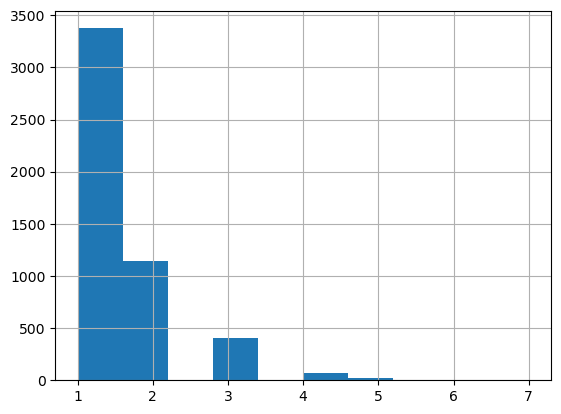

In [157]:
mental_health_gut_sleep_q.groupby('public_client_id').public_client_id.size().hist()

<Axes: >

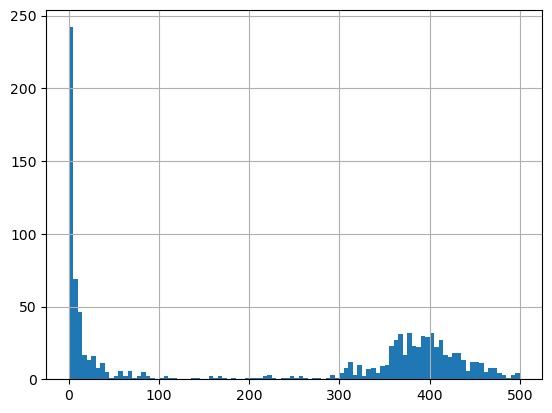

In [158]:
mental_health_gut_sleep_q.groupby('public_client_id')['days_in_program'].diff().hist(bins=100, range=[0,500])

^^^ This looks the same as the sleep disorder questionnaires and similar to diet questionnaires. Will combine rows that are within 30 days of each other.

In [159]:
# Use an adapted version of Crystal's code to combine rows for an individual if they are less than 30 days apart and then average the days in program
def collapse_surveys(df, features_to_go_through):
    df = df.sort_values(by=["public_client_id", "days_in_program"]).copy()
    
    collapsed_rows = []
    conflict_ids = set()

    for _, person_df in df.groupby("public_client_id"):
        person_df = person_df.sort_values("days_in_program")
        merged = person_df.iloc[0].copy()
        
        for i in range(1, len(person_df)):
            next_row = person_df.iloc[i]

            # If within 30 days, merge
            if next_row["days_in_program"] - merged["days_in_program"] < 30:
                # Average days
                merged["days_in_program"] = (merged["days_in_program"] + next_row["days_in_program"]) / 2  
                
                for col in features_to_go_through:
                    #if col not in non_food_cols:  # Exclude non-survey columns
                    val1, val2 = merged[col], next_row[col]
                        # If the first value is an NAN
                    if pd.isna(val1):  
                        merged[col] = val2  # Fill in missing values
                    elif pd.isna(val2):
                        pass  # Keep existing value
                    elif val1 == val2:
                        pass # keep existing value
                    elif val1 != val2:
                        # If they aren't equal, 
                        merged[col] = 1 # If they are not equal, then one of the values was 1 (bc binary columns)
                        conflict_ids.add(merged["public_client_id"])
            else:
                # Append merged row and start new one
                collapsed_rows.append(merged)
                merged = next_row.copy()

        collapsed_rows.append(merged)  # Append last merged row

    collapsed_df = pd.DataFrame(collapsed_rows)
    
    return collapsed_df, list(conflict_ids)

collapsed_df, conflict_ids = collapse_surveys(mental_health_gut_sleep_q, mental_health_gut_sleep_features)

In [160]:
# conflict IDs are those individuals who responded 0 in one entry and 1 in a different entry, or vice versa
# Since they responded 1 at least once, then the final aggregated is 1
conflict_ids

['01082690',
 '01757701',
 '01108803',
 '01243250',
 '01238987',
 'HX908582',
 '01852207',
 '01191231',
 '01451175',
 '01260341',
 '01934271',
 '01513993',
 '01142326',
 '01266726',
 '01549682',
 '01494895',
 '01196574',
 '01010353',
 '01129614',
 '01481024',
 '01593246',
 '01524930',
 '01137393',
 '01185174']

<Axes: >

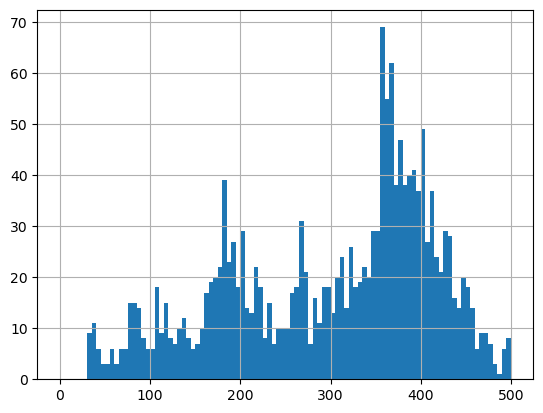

In [161]:
collapsed_df.groupby('public_client_id')['days_in_program'].diff().hist(bins=100, range=[0,500])

In [162]:
mental_health_gut_sleep_collapsed = collapsed_df
mental_health_gut_sleep_collapsed.rename(columns={'vendor': 'mental_health_gut_sleep_q_vendor'}, inplace=True)
mental_health_gut_sleep_collapsed['mental_health_gut_sleep_q_dip'] = mental_health_gut_sleep_collapsed.days_in_program
mental_health_gut_sleep_collapsed = mental_health_gut_sleep_collapsed.dropna(subset=['days_in_program', 'public_client_id'])

In [163]:
mental_health_gut_sleep_collapsed[mental_health_gut_sleep_collapsed.columns[:50]].info()

<class 'pandas.core.frame.DataFrame'>
Index: 6892 entries, 0 to 7310
Data columns (total 50 columns):
 #   Column                                                                                 Non-Null Count  Dtype  
---  ------                                                                                 --------------  -----  
 0   public_client_id                                                                       6892 non-null   object 
 1   mental_health_gut_sleep_q_vendor                                                       6892 non-null   object 
 2   days_in_program                                                                        6892 non-null   float64
 3   assessment:health-history:gut_gi_gastritis:self_current                                3540 non-null   float64
 4   assessment:health-history:gut_gi_gastritis:self_past                                   3540 non-null   float64
 5   assessment:health-history:gut_gi_gastritis:self_past_year                        

In [164]:
mental_health_gut_sleep_collapsed[mental_health_gut_sleep_collapsed.columns[50:]].info()

<class 'pandas.core.frame.DataFrame'>
Index: 6892 entries, 0 to 7310
Data columns (total 82 columns):
 #   Column                                                                           Non-Null Count  Dtype  
---  ------                                                                           --------------  -----  
 0   assessment:health-history:sleep_condition_narcolepsy:self_past_gt1ya             3525 non-null   float64
 1   assessment:health-history:sleep_condition_other:self_current                     3525 non-null   float64
 2   assessment:health-history:sleep_condition_other:self_past                        3525 non-null   float64
 3   assessment:health-history:sleep_condition_other:self_past_year                   3525 non-null   float64
 4   assessment:health-history:sleep_condition_other:self_past_gt1ya                  3525 non-null   float64
 5   assessment:health-history:sleep_condition_restless_leg_syndrome:self_current     3525 non-null   float64
 6   assessment:he

In [165]:
# Each question has 4 different sub questions: current, past, past year, and greater than 1 year ago (gt1ya)
# I will groupby the conditions and then consolidate responses to the subquestions
# These will be called the condition "any" columns, where a response of 1 in any of the subquestions
# indicates that a participant has the condition currently or anytime previous to when they filled out these questions

def consolidate_self_report(df, features_of_interest):
    """
    Collapse return 'any' columns for each condition, where:
    - 1 if participant responded True to any of the subquestions for a condition
    - 0 if participant never responded True but responded to at least one of the subquestions for a condition (ie not all Nan)
    - Nan if all values are nan, ie participant didn't respond to any of the subquestions for a condition
    """
    # Find all the unique conditions
    conditions = list(set([col.split(":")[-2] for col in features_of_interest]))

    for cond in conditions:
        # Find all the columns of a cond
        matching_cols = [col for col in features_of_interest if cond in col and 'self' in col]

        if matching_cols:
            def collapse_row(row):
                if row.isna().all():
                    return np.nan
                return int((row == 1).any())

            df[f"{cond}_self_anytime_before"] = df[matching_cols].apply(collapse_row, axis=1)

    return df

In [166]:
mental_health_gut_sleep_collapsed = consolidate_self_report(mental_health_gut_sleep_collapsed, mental_health_gut_sleep_features)

In [167]:
mental_health_gut_sleep_collapsed[mental_health_gut_sleep_collapsed.columns[80:]].info()

<class 'pandas.core.frame.DataFrame'>
Index: 6892 entries, 0 to 7310
Data columns (total 84 columns):
 #   Column                                                                         Non-Null Count  Dtype  
---  ------                                                                         --------------  -----  
 0   assessment:health-history:gut_gi_diverticulosis:self_past                      6516 non-null   float64
 1   assessment:health-history:gut_gi_gerd:self_past                                6546 non-null   float64
 2   assessment:health-history:gut_gi_ileal_crohns:self_past                        3540 non-null   float64
 3   assessment:health-history:gut_gi_irritable_bowel_syndrome:self_past            6513 non-null   float64
 4   assessment:health-history:gut_gi_peptic_ulcer:self_past                        6562 non-null   float64
 5   assessment:health-history:gut_gi_ulcerative_colitis:self_past                  3540 non-null   float64
 6   assessment:health-history:men

In [168]:
for col in mental_health_gut_sleep_collapsed.filter(like='any').columns:
    print(mental_health_gut_sleep_collapsed[col].value_counts())
    print('')

mental_health_alcohol_abuse_self_anytime_before
0.0    3443
1.0     113
Name: count, dtype: int64

mental_health_binge_eating_disorder_self_anytime_before
0.0    3458
1.0      96
Name: count, dtype: int64

gut_gi_ulcerative_colitis_self_anytime_before
0.0    3516
1.0      24
Name: count, dtype: int64

gut_gi_ileal_crohns_self_anytime_before
0.0    3535
1.0       5
Name: count, dtype: int64

mental_health_anorexia_self_anytime_before
0.0    3481
1.0      73
Name: count, dtype: int64

gut_gi_colonic_crohns_self_anytime_before
0.0    3535
1.0       5
Name: count, dtype: int64

sleep_condition_restless_leg_syndrome_self_anytime_before
0.0    3236
1.0     289
Name: count, dtype: int64

sleep_condition_other_self_anytime_before
0.0    3410
1.0     115
Name: count, dtype: int64

sleep_condition_narcolepsy_self_anytime_before
0.0    3510
1.0      15
Name: count, dtype: int64

mental_health_drug_abuse_self_anytime_before
0.0    3519
1.0      37
Name: count, dtype: int64

gut_gi_irritable_bowel_

In [169]:
# Make the gut, mental health, and sleep disorder feature lists
gut_q_features = mental_health_gut_sleep_collapsed.filter(regex='gut.*.anytime').columns.tolist()
mental_health_q_features = mental_health_gut_sleep_collapsed.filter(regex='mental.*.anytime').columns.tolist()
sleep_disorder_q_features = mental_health_gut_sleep_collapsed.filter(regex='sleep.*.anytime').columns.tolist()

In [170]:
gut_q_features

['gut_gi_ulcerative_colitis_self_anytime_before',
 'gut_gi_ileal_crohns_self_anytime_before',
 'gut_gi_colonic_crohns_self_anytime_before',
 'gut_gi_irritable_bowel_syndrome_self_anytime_before',
 'gut_gi_celiac_disease_self_anytime_before',
 'gut_gi_peptic_ulcer_self_anytime_before',
 'gut_gi_lactose_intolerance_self_anytime_before',
 'gut_gi_gastritis_self_anytime_before',
 'gut_gi_non_celiac_gluten_sensitivity_self_anytime_before',
 'gut_gi_gerd_self_anytime_before',
 'gut_gi_crohns_disease_self_anytime_before',
 'gut_gi_other_self_anytime_before',
 'gut_gi_diverticulosis_self_anytime_before']

In [171]:
mental_health_q_features

['mental_health_alcohol_abuse_self_anytime_before',
 'mental_health_binge_eating_disorder_self_anytime_before',
 'mental_health_anorexia_self_anytime_before',
 'mental_health_drug_abuse_self_anytime_before',
 'mental_health_adhd_add_self_anytime_before',
 'mental_health_anxiety_disorder_self_anytime_before',
 'mental_health_other_self_anytime_before',
 'mental_health_schizophrenia_self_anytime_before',
 'mental_health_bulimia_self_anytime_before',
 'mental_health_sad_self_anytime_before',
 'mental_health_other_eating_disorder_self_anytime_before',
 'mental_health_depression_self_anytime_before',
 'mental_health_obsessive_compulsive_disorder_self_anytime_before',
 'mental_health_bipolar_disorder_self_anytime_before']

In [172]:
sleep_disorder_q_features

['sleep_condition_restless_leg_syndrome_self_anytime_before',
 'sleep_condition_other_self_anytime_before',
 'sleep_condition_narcolepsy_self_anytime_before',
 'sleep_condition_insomnia_self_anytime_before',
 'sleep_condition_apnea_self_anytime_before']

In [173]:
mental_health_gut_sleep_to_merge = mental_health_gut_sleep_collapsed[['public_client_id',
                                                                      'days_in_program',
                                                                      'mental_health_gut_sleep_q_dip',
                                                                      'mental_health_gut_sleep_q_vendor'] + gut_q_features + mental_health_q_features + sleep_disorder_q_features]
mental_health_gut_sleep_to_merge = mental_health_gut_sleep_to_merge.sort_values(by='days_in_program')
sleep_merged = sleep_merged.sort_values(by='days_in_program')

In [174]:
mental_health_gut_sleep_to_merge.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6892 entries, 515 to 416
Data columns (total 36 columns):
 #   Column                                                           Non-Null Count  Dtype  
---  ------                                                           --------------  -----  
 0   public_client_id                                                 6892 non-null   object 
 1   days_in_program                                                  6892 non-null   float64
 2   mental_health_gut_sleep_q_dip                                    6892 non-null   float64
 3   mental_health_gut_sleep_q_vendor                                 6892 non-null   object 
 4   gut_gi_ulcerative_colitis_self_anytime_before                    3540 non-null   float64
 5   gut_gi_ileal_crohns_self_anytime_before                          3540 non-null   float64
 6   gut_gi_colonic_crohns_self_anytime_before                        3540 non-null   float64
 7   gut_gi_irritable_bowel_syndrome_self_anytime_b

In [175]:
# Merge the mental health, gut, and sleep disorder qs onto sleep merged
# Let's use a tolerance of 50 days like the happiness qs
sleep_merged = pd.merge_asof(
    sleep_merged,
    mental_health_gut_sleep_to_merge[
        mental_health_gut_sleep_to_merge.public_client_id.isin(sleep_merged.public_client_id)
    ],
    by="public_client_id",
    on="days_in_program",
    direction="nearest",
    tolerance=100
)

#### Update and clean up the features dict

In [176]:
# add in the question features
features_dict['gut_q_features'] = gut_q_features
features_dict['mental_health_q_features'] = mental_health_q_features
features_dict['sleep_disorder_q_features'] = sleep_disorder_q_features

In [177]:
features_dict['dip_features']

['reference_microbe_dip',
 'weights_dip',
 'fitbit_dip',
 'metabolite_dip',
 'diet_dip']

In [178]:
features_dict['vendor_features']

['microbiome_vendor', 'diet_vendor']

In [179]:
# update the dip and vendor
features_dict['dip_features'].append('mental_health_gut_sleep_q_dip')
features_dict['vendor_features'].append('mental_health_gut_sleep_q_vendor')

In [180]:
features_dict['dip_features']

['reference_microbe_dip',
 'weights_dip',
 'fitbit_dip',
 'metabolite_dip',
 'diet_dip',
 'mental_health_gut_sleep_q_dip']

In [181]:
features_dict['vendor_features']

['microbiome_vendor', 'diet_vendor', 'mental_health_gut_sleep_q_vendor']

In [182]:
list(features_dict.keys())

['heartrate_features',
 'activity_features',
 'sleep_features',
 'covariate_features',
 'sleep_features_log1p',
 'sleep_features_log1p_resids',
 'activity_features_resids',
 'heartrate_features_resids',
 'vendor_features',
 'new_microbe_binarized_features',
 'new_microbe_features_binary_10_90',
 'new_microbe_features',
 'diversity_features',
 'dip_features',
 'metabolite_features',
 'food_freq_features',
 'food_freq_features_daily',
 'food_freq_from_non_freq_features',
 'food_freq_from_non_freq_features_daily',
 'diet_daily_features',
 'gut_q_features',
 'mental_health_q_features',
 'sleep_disorder_q_features']

In [183]:
sleep_merged.shape

(1796, 2771)

# Add in the digestion questionnaires

In [184]:
digestion = get_snapshot('assessments')

In [185]:
digestion = digestion.filter(regex='public_client_id|vendor|days_in_program|digestion*.*enum*')

In [186]:
digestion.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11885 entries, 0 to 11884
Data columns (total 19 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   public_client_id                                     11885 non-null  object 
 1   vendor                                               11885 non-null  object 
 2   days_in_program                                      11877 non-null  float64
 3   assessment:digestion:abdominal-pain:enum             5930 non-null   object 
 4   assessment:digestion:acid_reflux:enum                6691 non-null   object 
 5   assessment:digestion:bloating:enum                   6689 non-null   object 
 6   assessment:digestion:bowel-movement-completion:enum  5927 non-null   object 
 7   assessment:digestion:bowel-movement-ease:enum        5927 non-null   object 
 8   assessment:digestion:bowel-movements:enum            5928 non-null

In [187]:
for col in digestion.columns[3:]:
    print(digestion[col].value_counts())
    print('')

assessment:digestion:abdominal-pain:enum
(4) Not at all                   3488
(3) Less than weekly             1715
(2) More than 1 time per week     579
(1) Daily                         148
Name: count, dtype: int64

assessment:digestion:acid_reflux:enum
(4) Not at all                   3910
(3) Less than weekly             1905
(2) More than 1 time per week     591
(1) Daily                         285
Name: count, dtype: int64

assessment:digestion:bloating:enum
(4) Infrequently or not at all    2993
(3) Once per week or less         2117
(2) Several times per week        1101
(1) Daily                          478
Name: count, dtype: int64

assessment:digestion:bowel-movement-completion:enum
(3) Most of the time    4545
(2) Sometimes           1092
(1) Infrequently         290
Name: count, dtype: int64

assessment:digestion:bowel-movement-ease:enum
(3) Easy to pass           4000
(2) Sometimes difficult    1709
(1) Often difficult         218
Name: count, dtype: int64

assessment

<Axes: >

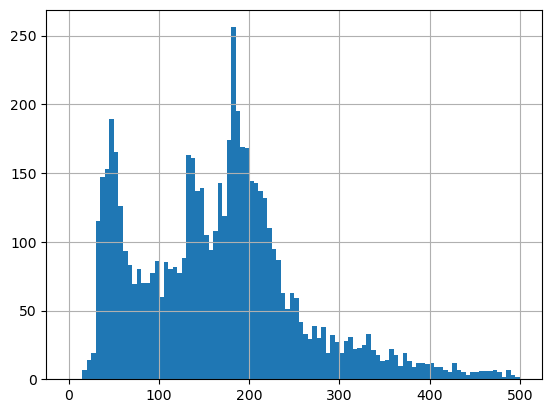

In [188]:
digestion.groupby('public_client_id')['days_in_program'].diff().hist(bins=100, range=[0,500])

In [189]:
import re

# Clean up the column names
def clean_column_name(col):
    col = col.removeprefix("assessment:")  # Remove 'assessment:'
    col = col.removesuffix(":enum")  # Remove ':enum'
    col = re.sub(r'[^a-zA-Z0-9]', '_', col)  # Replace any non alphanumeric character with underscores
    return col

# Apply renaming
digestion.columns = [clean_column_name(col) for col in digestion.columns]

In [190]:
digestion.columns

Index(['public_client_id', 'vendor', 'days_in_program',
       'digestion_abdominal_pain', 'digestion_acid_reflux',
       'digestion_bloating', 'digestion_bowel_movement_completion',
       'digestion_bowel_movement_ease', 'digestion_bowel_movements',
       'digestion_diarrhea', 'digestion_gas', 'digestion_high_appetite',
       'digestion_laxatives', 'digestion_medications', 'digestion_nausea',
       'digestion_poor_or_lack_of_appetite', 'digestion_stress_eating',
       'digestion_supplements', 'digestion_vomiting'],
      dtype='object')

In [191]:
digestion_features = digestion.columns[3:].tolist()

In [192]:
digestion_features

['digestion_abdominal_pain',
 'digestion_acid_reflux',
 'digestion_bloating',
 'digestion_bowel_movement_completion',
 'digestion_bowel_movement_ease',
 'digestion_bowel_movements',
 'digestion_diarrhea',
 'digestion_gas',
 'digestion_high_appetite',
 'digestion_laxatives',
 'digestion_medications',
 'digestion_nausea',
 'digestion_poor_or_lack_of_appetite',
 'digestion_stress_eating',
 'digestion_supplements',
 'digestion_vomiting']

In [193]:
# Prepare digestion to merge to sleep_merged
digestion_to_merge = digestion.copy()
digestion_to_merge.rename(columns={'vendor': 'digestion_vendor'}, inplace=True)
digestion_to_merge['digestion_dip'] = digestion_to_merge.days_in_program
digestion_to_merge = digestion_to_merge.dropna(subset=['public_client_id', 'digestion_vendor', 'days_in_program'])
digestion_to_merge = digestion_to_merge.sort_values(by='days_in_program')

# Sort the sleep_merged by days_in_program for merging
sleep_merged = sleep_merged.sort_values(by='days_in_program')

In [194]:
digestion_to_merge.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11877 entries, 801 to 1779
Data columns (total 20 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   public_client_id                     11877 non-null  object 
 1   digestion_vendor                     11877 non-null  object 
 2   days_in_program                      11877 non-null  float64
 3   digestion_abdominal_pain             5928 non-null   object 
 4   digestion_acid_reflux                6688 non-null   object 
 5   digestion_bloating                   6686 non-null   object 
 6   digestion_bowel_movement_completion  5925 non-null   object 
 7   digestion_bowel_movement_ease        5925 non-null   object 
 8   digestion_bowel_movements            5926 non-null   object 
 9   digestion_diarrhea                   6684 non-null   object 
 10  digestion_gas                        5929 non-null   object 
 11  digestion_high_appetite         

In [195]:
# Merge the digestion qs onto sleep merged
# Let's use a tolerance of 30 days
sleep_merged = pd.merge_asof(
    sleep_merged,
    digestion_to_merge[
        digestion_to_merge.public_client_id.isin(sleep_merged.public_client_id)
    ],
    by="public_client_id",
    on="days_in_program",
    direction="nearest",
    tolerance=30
)

In [196]:
for col in digestion_features:
    print(sleep_merged[col].value_counts())
    print('')

digestion_abdominal_pain
(4) Not at all                   671
(3) Less than weekly             374
(2) More than 1 time per week    144
(1) Daily                         38
Name: count, dtype: int64

digestion_acid_reflux
(4) Not at all                   894
(3) Less than weekly             430
(2) More than 1 time per week    149
(1) Daily                         56
Name: count, dtype: int64

digestion_bloating
(4) Infrequently or not at all    581
(3) Once per week or less         540
(2) Several times per week        276
(1) Daily                         132
Name: count, dtype: int64

digestion_bowel_movement_completion
(3) Most of the time    915
(2) Sometimes           251
(1) Infrequently         61
Name: count, dtype: int64

digestion_bowel_movement_ease
(3) Easy to pass           777
(2) Sometimes difficult    402
(1) Often difficult         48
Name: count, dtype: int64

digestion_bowel_movements
(3) 1-3 times daily              802
(2) 3-6 times per week           360
(1) 2 or

In [197]:
# Let's collapse the first two levels of digestion_laxatives and digestion_nausea and digestion_vomiting
collapse_laxatives_map = {
    "(1) Daily": "(1) Daily or Several times per week COLLAPSED",
    "(2) Several times per week": "(1) Daily or Several times per week COLLAPSED",
    "(3) Once per week or less": "(2) Once per week or less",
    "(4) Not at all": "(3) Not at all"
}

collapse_nausea_map = {
    "(1) Daily": "(1) Daily or Regularly (several times per week) COLLAPSED",
    "(2) Regularly (several times per week)": "(1) Daily or Regularly (several times per week) COLLAPSED",
    "(3) Occasionally (once a week or less)": "(2) Occasionally (once a week or less)",
    "(4) Infrequently or not at all (less than monthly)": "(3) Infrequently or not at all (less than monthly)"
}

collapse_vomiting_map = {
    "(1) Regularly (daily or several times per week)": "(1) Regularly (daily or several times per week) or Occasionally (once a week or less) COLLAPSED",
    "(2) Occasionally (once a week or less)": "(1) Regularly (daily or several times per week) or Occasionally (once a week or less) COLLAPSED",
    "(3) Infrequently or not at all (less than monthly)": "(2) Occasionally (once a week or less)"
}

sleep_merged['digestion_laxatives'] = sleep_merged['digestion_laxatives'].replace(collapse_laxatives_map)
sleep_merged['digestion_nausea'] = sleep_merged['digestion_nausea'].replace(collapse_nausea_map)
sleep_merged['digestion_vomiting'] = sleep_merged['digestion_vomiting'].replace(collapse_vomiting_map)

In [198]:
for col in ['digestion_laxatives', 'digestion_nausea', 'digestion_vomiting']:
    print(sleep_merged[col].value_counts())
    print('')

digestion_laxatives
(3) Not at all                                   1137
(2) Once per week or less                          62
(1) Daily or Several times per week COLLAPSED      28
Name: count, dtype: int64

digestion_nausea
(3) Infrequently or not at all (less than monthly)           1179
(2) Occasionally (once a week or less)                        301
(1) Daily or Regularly (several times per week) COLLAPSED      48
Name: count, dtype: int64

digestion_vomiting
(2) Occasionally (once a week or less)                                                             1213
(1) Regularly (daily or several times per week) or Occasionally (once a week or less) COLLAPSED      14
Name: count, dtype: int64



In [199]:
# Now fix the order of the values so that the text info follows the numeric codings
for col in digestion_features:
    print(col)
    print(sorted(sleep_merged[col].dropna().unique()))
    print('')

digestion_abdominal_pain
['(1) Daily', '(2) More than 1 time per week', '(3) Less than weekly', '(4) Not at all']

digestion_acid_reflux
['(1) Daily', '(2) More than 1 time per week', '(3) Less than weekly', '(4) Not at all']

digestion_bloating
['(1) Daily', '(2) Several times per week', '(3) Once per week or less', '(4) Infrequently or not at all']

digestion_bowel_movement_completion
['(1) Infrequently', '(2) Sometimes', '(3) Most of the time']

digestion_bowel_movement_ease
['(1) Often difficult', '(2) Sometimes difficult', '(3) Easy to pass']

digestion_bowel_movements
['(1) 2 or fewer times per week', '(2) 3-6 times per week', '(3) 1-3 times daily', '(4) 4+ times daily']

digestion_diarrhea
['(1) Daily', '(2) Several times per week', '(3) Once per week or less', '(4) Infrequently or not at all']

digestion_gas
['(1) Daily', '(2) Several times per week', '(3) Once per week or less', '(4) Infrequently or not at all']

digestion_high_appetite
['(1) Regularly (daily or several times 

In [200]:
# Let's fix the ordering of the responses so less frequent is 1 and most frequent is the higher number
abdominal_pain_order_map = {
    "(1) Daily": "(4) Daily",
    "(2) More than 1 time per week": "(3) More than 1 time per week",
    "(3) Less than weekly": "(2) Less than weekly",
    "(4) Not at all": "(1) Not at all"
}
sleep_merged['digestion_abdominal_pain'] = sleep_merged['digestion_abdominal_pain'].replace(abdominal_pain_order_map)

acid_reflux_order_map = {
    "(1) Daily": "(4) Daily",
    "(2) More than 1 time per week": "(3) More than 1 time per week",
    "(3) Less than weekly": "(2) Less than weekly",
    "(4) Not at all": "(1) Not at all"
}
sleep_merged['digestion_acid_reflux'] = sleep_merged['digestion_acid_reflux'].replace(acid_reflux_order_map)

bloating_order_map = {
    "(1) Daily": "(4) Daily",
    "(2) Several times per week": "(3) Several times per week",
    "(3) Once per week or less": "(2) Once per week or less",
    "(4) Infrequently or not at all": "(1) Infrequently or not at all"
}
sleep_merged['digestion_bloating'] = sleep_merged['digestion_bloating'].replace(bloating_order_map)

bowel_movement_ease_order_map = {
    "(1) Often difficult": "(3) Often difficult",
    "(2) Sometimes difficult": "(2) Sometimes difficult",
    "(3) Easy to pass": "(1) Easy to pass"
}
sleep_merged['digestion_bowel_movement_ease'] = sleep_merged['digestion_bowel_movement_ease'].replace(bowel_movement_ease_order_map)

diarrhea_order_map = {
    "(1) Daily": "(4) Daily",
    "(2) Several times per week": "(3) Several times per week",
    "(3) Once per week or less": "(2) Once per week or less",
    "(4) Infrequently or not at all": "(1) Infrequently or not at all"
}
sleep_merged['digestion_diarrhea'] = sleep_merged['digestion_diarrhea'].replace(diarrhea_order_map)

gas_order_map = {
    '(1) Daily': '(4) Daily',
    '(2) Several times per week': '(3) Several times per week',
    '(3) Once per week or less': '(2) Once per week or less', 
    '(4) Infrequently or not at all': '(1) Infrequently or not at all'
}
sleep_merged['digestion_gas'] = sleep_merged['digestion_gas'].replace(gas_order_map)

high_appetite_order_map = {
    '(1) Regularly (daily or several times per week)': '(3) Regularly (daily or several times per week)', 
    '(2) Occasionally (once a week or less)': '(2) Occasionally (once a week or less)', 
    '(3) No': '(1) No'
}
sleep_merged['digestion_high_appetite'] = sleep_merged['digestion_high_appetite'].replace(high_appetite_order_map)

laxatives_order_map = {
    '(1) Daily or Several times per week COLLAPSED': '(3) Daily or Several times per week COLLAPSED', 
    '(2) Once per week or less': '(2) Once per week or less', 
    '(3) Not at all': '(1) Not at all'
}
sleep_merged['digestion_laxatives'] = sleep_merged['digestion_laxatives'].replace(laxatives_order_map)

medications_order_map = {
    '(1) Daily': '(4) Daily', 
    '(2) Several times per week': '(3) Several times per week', 
    '(3) Once per week or less': '(2) Once per week or less', 
    '(4) Not at all': '(1) Not at all'
}
sleep_merged['digestion_medications'] = sleep_merged['digestion_medications'].replace(medications_order_map)

nausea_order_map = {
    '(1) Daily or Regularly (several times per week) COLLAPSED': '(3) Daily or Regularly (several times per week) COLLAPSED', 
    '(2) Occasionally (once a week or less)': '(2) Occasionally (once a week or less)', 
    '(3) Infrequently or not at all (less than monthly)': '(1) Infrequently or not at all (less than monthly)'
}
sleep_merged['digestion_nausea'] = sleep_merged['digestion_nausea'].replace(nausea_order_map)

poor_or_lack_of_appetite_order_map = {
    '(1) Regularly (daily or several times per week)': '(3) Regularly (daily or several times per week)', 
    '(2) Occasionally (once a week or less)': '(2) Occasionally (once a week or less)', 
    '(3) No': '(1) No'
}
sleep_merged['digestion_poor_or_lack_of_appetite'] = sleep_merged['digestion_poor_or_lack_of_appetite'].replace(poor_or_lack_of_appetite_order_map)

stress_eating_order_map = {
    '(1) Daily': '(4) Daily', 
    '(2) Several times per week': '(3) Several times per week',
    '(3) Once per week or less': '(2) Once per week or less', 
    '(4) Not at all': '(1) Not at all'
}
sleep_merged['digestion_stress_eating'] = sleep_merged['digestion_stress_eating'].replace(stress_eating_order_map)

supplements_order_map = {
    '(1) Daily': '(4) Daily', 
    '(2) Several times per week': '(3) Several times per week', 
    '(3) Once per week or less': '(2) Once per week or less', 
    '(4) Not at all': '(1) Not at all'
}
sleep_merged['digestion_supplements'] = sleep_merged['digestion_supplements'].replace(supplements_order_map)

vomiting_order_map = {
    '(1) Regularly (daily or several times per week) or Occasionally (once a week or less) COLLAPSED': '(2) Regularly (daily or several times per week) or Occasionally (once a week or less) COLLAPSED',
    '(2) Occasionally (once a week or less)': '(1) Occasionally (once a week or less)'
}
sleep_merged['digestion_vomiting'] = sleep_merged['digestion_vomiting'].replace(vomiting_order_map)

In [201]:
# Now fix the order of the values so that the text info follows the numeric codings
for col in digestion_features:
    print(col)
    print(sorted(sleep_merged[col].dropna().unique()))
    print('')

digestion_abdominal_pain
['(1) Not at all', '(2) Less than weekly', '(3) More than 1 time per week', '(4) Daily']

digestion_acid_reflux
['(1) Not at all', '(2) Less than weekly', '(3) More than 1 time per week', '(4) Daily']

digestion_bloating
['(1) Infrequently or not at all', '(2) Once per week or less', '(3) Several times per week', '(4) Daily']

digestion_bowel_movement_completion
['(1) Infrequently', '(2) Sometimes', '(3) Most of the time']

digestion_bowel_movement_ease
['(1) Easy to pass', '(2) Sometimes difficult', '(3) Often difficult']

digestion_bowel_movements
['(1) 2 or fewer times per week', '(2) 3-6 times per week', '(3) 1-3 times daily', '(4) 4+ times daily']

digestion_diarrhea
['(1) Infrequently or not at all', '(2) Once per week or less', '(3) Several times per week', '(4) Daily']

digestion_gas
['(1) Infrequently or not at all', '(2) Once per week or less', '(3) Several times per week', '(4) Daily']

digestion_high_appetite
['(1) No', '(2) Occasionally (once a wee

In [202]:
# add digestion features to features_dict and add digestion_dip to dip_features and digestion_vendor to vendor_features
features_dict['digestion_features'] = digestion_features
features_dict['vendor_features'].append('digestion_vendor')
features_dict['dip_features'].append('digestion_dip')

# Add in medication and supplement self reports

In [203]:
meds = get_snapshot('assessments_health_history_misc')

In [204]:
meds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9734 entries, 0 to 9733
Data columns (total 87 columns):
 #   Column                                                                      Non-Null Count  Dtype  
---  ------                                                                      --------------  -----  
 0   public_client_id                                                            9734 non-null   object 
 1   vendor                                                                      9734 non-null   object 
 2   days_in_program                                                             9729 non-null   float64
 3   days_since_first_call                                                       9095 non-null   float64
 4   days_since_first_draw                                                       9097 non-null   float64
 5   month                                                                       9734 non-null   object 
 6   weekday                                         

In [205]:
meds.vendor.value_counts()

vendor
Assessments    8862
Health 123      872
Name: count, dtype: int64

In [206]:
meds['assessment:health-history:supplement_use:int'].value_counts()

assessment:health-history:supplement_use:int
(2) Yes                    2703
(0) No                      552
(1) Rarely/Occasionally     338
Name: count, dtype: int64

In [207]:
# couldn't find any info on this question, thought it would be nice to compare to fitbit bedtime
meds['assessment:lifestyle:chronotype:int'].value_counts()

assessment:lifestyle:chronotype:int
(4) Agree                         1235
(5) Strongly agree                1071
(3) Neither disagree nor agree    1061
(2) Disagree                       951
(1) Strongly disagree              609
Name: count, dtype: int64

In [208]:
meds['assessment:health-history:drugs_psychiatric:int'].value_counts()

assessment:health-history:drugs_psychiatric:int
(0) Never        2738
(1) Currently     569
(2) Formerly      285
Name: count, dtype: int64

In [209]:
meds['assessment:health-history:over_the_counter_medication_use:int'].value_counts()

assessment:health-history:over_the_counter_medication_use:int
(1) Rarely/Occasionally    1814
(2) Yes                     968
(0) No                      810
Name: count, dtype: int64

In [210]:
meds['assessment:vitals:supplements:text'].tolist()

['vitamin C\r\nB vitamins \r\ncalcium \r\nfish oil\r\nvitamin D',
 'vit d 5000iu 2x/ wk, Nutrafol 4 capsules daily, occ nutragenic omega 3ss',
 'vitamin c',
 'Multiple vitamin B vitamins ',
 'Turmeric supplement',
 'One a day Vitamin/Fish Oil/Glucosamine',
 'B12 ',
 'sometimes multi-vitamin pills',
 'bayer 80mg 1x daily--hair skin nails 2x daily--vit d 5000mg 1x daily--coq 10 1x daily--',
 'Multi vitamin, vitamin D3, Citracal, Plant Sterol, fish oil, vitamin C, Red Rice Yeast and probiotic.',
 nan,
 'one a day mens',
 'Vitamins, fish oil, magnesium, probiotics, glucosamine ',
 'Occasionally I imbibe in marijuana and alcoholic beverages.',
 nan,
 'Multi-vitamin, 2000 iu Vit D, 1000 Vit C, ',
 nan,
 '1 Multi-vitamin, 2000mg Omega 3, 2000mg Vitamin C & 8000iu Vitamin D',
 'Vegan Omega 3 DHA/ EPA (195 mg EPA), vegan multivitamin, 100 mg iron, 5000 iu vitamin D, b12',
 nan,
 'Multi-vitamin. B-12 shots. Iron. Vitamin D. Vegan Omega fatty acids. Probiotics. Digestive enzymes.',
 nan,
 nan,
 n

#### Use regex to capture several different supplements:
Look for:
- melatonin
- vitamin D
- any vitamins NOT vit D (ie multivitamins, B vitamins, vitamin K, etc.)
- turmeric/curcumin
- fish oil/omega 3 (liver, krill, fish, DHA)
- probiotics
- milk thistle
- prebiotic/metamucil/fiber/flax/psyllium
- magnesium

In [211]:
import re
import pandas as pd

# Dictionary mapping supplement categories to regex patterns
supplement_patterns = {
    "melatonin": r'\b(me[a-e]*l[a-z]*t[a-z]*n)\b',
    "vitD": r'\b(vit[\s\-]*d|d3|\s*d\s*|vitamin[\s\-]*d)\b',
    # multivitamin or any non vitamin D
    "multiVit": r'\b(?:multi[\s\-]*vit(?![\s\-]*d\b)|vitamin[s]?(?![\s\-]*d\b)|vit[\s\-]*[abck]|b[\s\-]*?complex|niacin|multi|[\s\-]?[cka]|b[\s\-]*12)\b',
    "turmeric": r'\b(tur[a-z]*ic|curcumin|[a-z]*urcum[a-z]*|cu[a-z]*umin)\b',
    # fish oil, or DHA, krill oil, omega 3, cod liver oil
    "omega3": r'\b(omeg[a-z]*[\s\-]*3*|fish[\s\-]*oil|krill[\s\-]*oil|cod[\s\-]*liver[\s\-]*oil|dha|fatty[\s\-]*acid)\b',
    "probio": r'\b(pro[\s\-]*b[a-z]*|lacto[a-z]*)\b',
    "milkThistle": r'\b(milk[\s\-]*this[a-z]*)\b',
    # any kind of fiber supplement or prebiotic, metamucil, flax seed, psyllium
    "prebio": r'\b(pre[\s\-]*b[a-z]*|met[a-z]*mu[a-z]*il|fiber|flax[\s\-]*seed(?!\s*oil)|psy[a-z]*lium)\b',
    # any mineral: magnesium, calcium, zinc, iron, or combinations
    "mineral_mag_cal_zinc": r'\b(magn[a-z]*m|mag|calc[a-z]*|[\s\-]cal|zinc)\b'
    #"cysteine": r'\b(cyst[a-z]*ne)\b'
}

# Function to find supplements in text
def find_supplements(text):
    text = text.lower()  # make all text lowercase
    found_supplements = ''
    for supplement, pattern in supplement_patterns.items():
        if re.search(pattern, text):
            found_supplements += f' {supplement}'
    return found_supplements

In [212]:
# Apply the function to extract supplements
meds["supplements_detected_supplements"] = meds['assessment:vitals:supplements:text'].dropna().apply(find_supplements)
meds["supplements_detected_otc"] = meds['assessment:vitals:over_the_counter:text'].dropna().apply(find_supplements)
meds["supplements_detected_prescription"] = meds['assessment:vitals:prescriptions:text'].dropna().apply(find_supplements)

In [213]:
meds.supplements_detected_supplements.value_counts()

supplements_detected_supplements
                                                 877
 multiVit                                        577
 vitD multiVit omega3                            423
 vitD omega3                                     412
 vitD multiVit                                   317
                                                ... 
 vitD turmeric omega3 prebio                       1
 melatonin turmeric omega3                         1
 vitD turmeric omega3 probio prebio                1
 melatonin vitD multiVit omega3 milkThistle        1
 vitD probio milkThistle mineral_mag_cal_zinc      1
Name: count, Length: 169, dtype: int64

In [214]:
meds[["supplements_detected_supplements", "assessment:vitals:supplements:text"]]

,supplements_detected_supplements,assessment:vitals:supplements:text
0,vitD multiVit omega3 mineral_mag_cal_zinc,vitamin C\r\nB vitamins \r\ncalcium \r\nfish o...
1,vitD omega3,"vit d 5000iu 2x/ wk, Nutrafol 4 capsules daily..."
2,multiVit,vitamin c
3,multiVit,Multiple vitamin B vitamins
4,turmeric,Turmeric supplement
...,...,...
9729,probio,RepHresh Pro-B
9730,multiVit probio,"Probiotics, vitamins"
9731,NaN,NaN
9732,NaN,NaN


In [215]:
meds[["supplements_detected_supplements", "assessment:vitals:supplements:text"]].loc[9729].tolist()

[' probio', 'RepHresh Pro-B']

In [216]:
meds[["supplements_detected_supplements", "assessment:vitals:supplements:text"]].loc[81].tolist()

[' multiVit', 'Multi-vitamin Gummies (not regularly)']

In [217]:
meds[["supplements_detected_supplements", "assessment:vitals:supplements:text"]].loc[5555].tolist()

[' vitD', 'vit. D3- 2000IU daily']

In [218]:
meds[["supplements_detected_supplements", "assessment:vitals:supplements:text"]].loc[5293].tolist()

[' vitD', 'Mega 3   Vitamin D    but again not consistent']

In [219]:
meds[["supplements_detected_supplements", "assessment:vitals:supplements:text"]].loc[20].tolist()

[' vitD multiVit omega3 probio',
 'Multi-vitamin. B-12 shots. Iron. Vitamin D. Vegan Omega fatty acids. Probiotics. Digestive enzymes.']

In [220]:
meds[["supplements_detected_supplements", "assessment:vitals:supplements:text"]].loc[359].tolist()

[' vitD multiVit', 'Vitamin D 1,000 per day; Super B complex ']

In [221]:
meds[["supplements_detected_supplements", "assessment:vitals:supplements:text"]].loc[42].tolist()

[' vitD multiVit',
 'multi vitamin, vitamin D, vitamin d  and hemp 875mg all occasionally']

In [222]:
meds[["supplements_detected_supplements", "assessment:vitals:supplements:text"]].loc[279].tolist()

[' multiVit omega3',
 'Fish oil, B-12, B compiles, C, lysine, l-tgeanine, e, coenzyme q, collagen kind of irregular with most of these']

In [223]:
meds[["supplements_detected_supplements", "assessment:vitals:supplements:text"]].loc[300].tolist()

[' vitD multiVit omega3',
 'Caltrate 600 D3, CoQ10 300mg, Centrum Specialist Energy, Triple Omega oil, Vitamin C 1000MG']

In [224]:
meds[["supplements_detected_supplements", "assessment:vitals:supplements:text"]].loc[2534].tolist()

[' melatonin vitD multiVit probio mineral_mag_cal_zinc',
 "RAW Probiotic Men 50+ 1 daily\r\nFlaxseed oil 1000mg 1 daily\r\nvitamin D liquid drop 2000mg ( 1drop ) daily\r\ngrapefruit seed extract 10 drops daily \r\nchelated magnesium 250mg daily ( Country Life )\r\nubiquinol 100mg active CoQ10 - 1daily\r\nmelatonin 5- 10mg if needed for sleep\r\nNew Chapter every man's one daily Multi vitamin - 1 daily\r\nVitamin A 10,000u -1 daily\r\nNatural Factors mixed BetaCareAll 25,000 IU  - 1daily\r\nIP-6 & Inositol ( Cell Forte ) - 1daily\r\nSolgar 7 Joint support - 1daily\r\nRed Yeast Rice 600mg + Phytosterols ( Weider ) - 2daily\r\nVitamin B12 1000mg sublingual - 1 daily\r\nOrac -Energy Greens - 1 scoop ( 6 grams ) in large glass of water daily"]

In [225]:
# Convert supplements_detected column into binary columns of all supplements
supplements_binary_supplements = meds["supplements_detected_supplements"].str.get_dummies(sep=" ")
supplements_binary_otc = meds["supplements_detected_otc"].str.get_dummies(sep=" ")
supplements_binary_prescription = meds["supplements_detected_prescription"].str.get_dummies(sep=" ")

In [226]:
supplements_binary_supplements

,melatonin,milkThistle,mineral_mag_cal_zinc,multiVit,omega3,prebio,probio,turmeric,vitD
0,0,0,1,1,1,0,0,0,1
1,0,0,0,0,1,0,0,0,1
2,0,0,0,1,0,0,0,0,0
3,0,0,0,1,0,0,0,0,0
4,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...
9729,0,0,0,0,0,0,1,0,0
9730,0,0,0,1,0,0,1,0,0
9731,0,0,0,0,0,0,0,0,0
9732,0,0,0,0,0,0,0,0,0


In [227]:
supplements_binary_otc

,melatonin,milkThistle,mineral_mag_cal_zinc,multiVit,omega3,prebio,probio,turmeric,vitD
0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...
9729,0,0,0,0,0,0,0,0,0
9730,0,0,0,0,0,0,0,0,0
9731,0,0,0,0,0,0,0,0,0
9732,0,0,0,0,0,0,0,0,0


In [228]:
supplements_binary_prescription

,melatonin,milkThistle,mineral_mag_cal_zinc,multiVit,omega3,prebio,probio,turmeric,vitD
0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...
9729,0,0,0,0,0,0,0,0,0
9730,0,0,0,0,0,0,0,0,0
9731,0,0,0,0,0,0,0,0,0
9732,0,0,0,0,0,0,0,0,0


### Now combine all the responses into 1 df

In [229]:
supplements_all_responses = supplements_binary_supplements + supplements_binary_otc + supplements_binary_prescription

In [230]:
supplements_all_responses

,melatonin,milkThistle,mineral_mag_cal_zinc,multiVit,omega3,prebio,probio,turmeric,vitD
0,0,0,1,1,1,0,0,0,1
1,0,0,0,0,1,0,0,0,1
2,0,0,0,1,0,0,0,0,0
3,0,0,0,1,0,0,0,0,0
4,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...
9729,0,0,0,0,0,0,1,0,0
9730,0,0,0,1,0,0,1,0,0
9731,0,0,0,0,0,0,0,0,0
9732,0,0,0,0,0,0,0,0,0


In [231]:
# Sometimes there are duplicate responses
# ie, row 9733 responded with multivit and vitD across both supplements response and prescription response
# convert the supplements_all_responses so that any value greater than 0 is 1
supplements_all_responses = (supplements_all_responses > 0).astype(int)

In [232]:
supplement_features = supplements_all_responses.columns.tolist()

In [233]:
meds = pd.concat([meds, supplements_all_responses], axis=1)

In [234]:
meds.probio.sum()

1056

In [235]:
# since all cells are either 0 or 1 now the mean of each column is the proportion of yes responses
meds[supplement_features].mean().sort_values(ascending=False)

multiVit                0.333779
vitD                    0.307171
omega3                  0.270187
mineral_mag_cal_zinc    0.143107
probio                  0.108486
turmeric                0.030923
melatonin               0.021677
prebio                  0.019725
milkThistle             0.005137
dtype: float64

#### Check out the NON assessment medications snapshot to compare to what we found in the free response
Can skip this section, I take a better approach to compare these two dfs below

In [236]:
meds_not_assess = get_snapshot('medications')

In [237]:
meds_not_assess[meds_not_assess["name"].str.contains(supplement_patterns['probio'], regex=True, na=False, case=False)]

,medication_id,public_client_id,product_id,product_type,name,frequency,frequency_unit,predecessor_id,notes,annotations
49,9405,01002183,153327.0,supplement,Nature'S Bounty Probiotic Acidophilus,1.0,day,NaN,1 billion per chewable capsule,NaN
97,3771,01003411,141101.0,supplement,Higher Nature Probio-Easy Probiotic Powder 25g,1.0,day,NaN,"Recommended by ND. 10 billion CFU, combinatio...",NaN
295,30253,01010353,NaN,supplement,Garden of Life Probiotic,NaN,NaN,NaN,NaN,NaN
348,17937,01011640,184185.0,supplement,Vsl#3 Probiotic Medical Food,2.0,day,NaN,NaN,NaN
361,28895,01012322,184165.0,supplement,Probiotics,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
31338,8905,HX978690,143823.0,supplement,Jarrow Formulas Enhanced Probiotic System Jarr...,1.0,day,NaN,NaN,NaN
31357,20861,HX980884,184165.0,supplement,Probiotics,NaN,NaN,NaN,NaN,NaN
31393,5198,QIRL,124975.0,supplement,Culturelle Culturelle Probiotic,1.0,day,NaN,Culturelle Pro-Well probiotic,NaN
31406,997,ZU612255,169265.0,supplement,Rephresh Pro-B,NaN,NaN,NaN,vaginal health,NaN


In [238]:
# Double check this worked
meds_not_assess[meds_not_assess["name"].str.contains(supplement_patterns['probio'], regex=True, na=False, case=False)].name.value_counts()

name
Probiotics                                                      387
Vsl#3 Probiotic Medical Food                                     38
Culturelle Health And Wellness Daily Probiotic                   25
Jarrow Formulas Enhanced Probiotic System Jarro-Dophilus Eps     23
Klaire Labs Lactoprime Plus                                      19
                                                               ... 
Lactoprime Probiotic                                              1
Probiotic (Essential Stack)                                       1
Shaklee Optiflora Probiotic Complex                               1
Saccharomyces boulardii probiotic                                 1
Nature's Way Probiotic                                            1
Name: count, Length: 169, dtype: int64

In [239]:
meds_not_assess[meds_not_assess.name == 'Multivitamin']

,medication_id,public_client_id,product_id,product_type,name,frequency,frequency_unit,predecessor_id,notes,annotations
33,29855,01001661,184158.0,supplement,Multivitamin,NaN,NaN,NaN,NaN,NaN
152,28535,01004575,184158.0,supplement,Multivitamin,NaN,NaN,NaN,"One-A-Day formula, for women, per assessments",NaN
175,16554,01004750,NaN,supplement,Multivitamin,NaN,NaN,NaN,NaN,NaN
223,28166,01007074,184158.0,supplement,Multivitamin,NaN,NaN,NaN,NaN,NaN
296,30254,01010353,184158.0,supplement,Multivitamin,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
31170,14275,HX872254,184158.0,supplement,Multivitamin,4.0,day,NaN,Started prior to Arivale,NaN
31258,6381,HX923111,184158.0,supplement,Multivitamin,NaN,NaN,NaN,NaN,NaN
31263,13809,HX927178,184158.0,supplement,Multivitamin,NaN,NaN,NaN,Women's chewy vitamins from Costco,NaN
31355,20856,HX980884,184158.0,supplement,Multivitamin,NaN,NaN,NaN,NaN,NaN


Looks like the 'medications' snapshot underestimates the number of people reporting taking different supplements compared to the medications assessment free response questions

#### Try to find sleep meds in the free response columns

In [240]:
import re
import pandas as pd

# Use Crystal's dictionary of drug names for sleep meds
# Note that alprazolam, diazepam, and lorazepam are used to treat anxiety
# They are not ideal for treating sleep disorders as there are better options
# They are also prone to addiction and dependence
# Crystal kept them here as they *may* make one sleepy

sleep_drug_patterns = {
    "alprazolam": r'\b(alprazolam|xanax)\b',
    "diazepam": r'\b(diazepam|valium|ketamine|neurotin)\b',
    "lorazepam": r'\b(lorazepam|ativan)\b',
    "eszopiclone": r'\b(eszopiclone|lunesta)\b',
    "trazodone": r'\b(trazodone|desyrel)\b',
    "temazepam": r'\b(temazepam|restoril)\b',
    "triazolam": r'\b(triazolam|halcion)\b',
    "zaleplon": r'\b(zaleplon|sonata)\b',
    "zolpidem": r'\b(zolpidem|ambien|edluar)\b'
}

# Function to find supplements in text
def find_sleep(text):
    text = text.lower()  # make all text lowercase
    found_sleep = ''
    for sleep, pattern in sleep_drug_patterns.items():
        if re.search(pattern, text):
            found_sleep += f' {sleep}'
    return found_sleep

In [241]:
# Apply the function to extract supplements
meds["sleep_detected_supplements"] = meds['assessment:vitals:supplements:text'].dropna().apply(find_sleep)
meds["sleep_detected_otc"] = meds['assessment:vitals:over_the_counter:text'].dropna().apply(find_sleep)
meds["sleep_detected_prescription"] = meds['assessment:vitals:prescriptions:text'].dropna().apply(find_sleep)

In [242]:
meds.sleep_detected_supplements.value_counts()

sleep_detected_supplements
              5734
 trazodone       1
Name: count, dtype: int64

In [243]:
meds[meds.sleep_detected_supplements == ' trazodone']

,public_client_id,vendor,days_in_program,days_since_first_call,days_since_first_draw,month,weekday,season,assessment:health-history:biological_sex:int,assessment:health-history:blood_donation:int,...,mineral_mag_cal_zinc,multiVit,omega3,prebio,probio,turmeric,vitD,sleep_detected_supplements,sleep_detected_otc,sleep_detected_prescription
4231,01448060,Assessments,373.0,NaN,359.0,Apr,Wed,spring,(0) Male,(3) More than a year ago,...,1,1,1,1,1,0,1,trazodone,NaN,


In [244]:
meds[meds.sleep_detected_supplements == ' trazodone']['assessment:vitals:supplements:text'].tolist()

["1.\t1 325 mg asprin (12/2012)\n2.\tNamenda XR 21mg (7/2017)\n3.\tRivastigmine 13.3 mg (9/2017)\n4.\tTrazodone - as sleeping aid 50 mg (2 daily)\n5.\tCurcuBrain (400 mg) 1 to 2 daily.\n6.\t2 Famotidine 20 mg (2 daily) (2015)\n7.\tGlycine 3000 mg (a couple of times a week) (2015)\n8.\tCostco Krill Oil (2) (3/2013)\n9.\tAlign: Probiotic (1 daily) (2013)\n10.\tKirkland: triple action joint health\n11.\tTotal Restore (Dr. Gundy) Gut lining\n12.\tSaw Palmetto: 1070 mg daily (2015)\n13.\t5,000 iu vitamin D daily (2010)\n14.\t0 Calciam/Magnesium in green food base.(Trader Joe's) (0) (2011)\n15.\tQuo Q10 (Quionol) (1)  (2012)\n16.\t 0 Costco - Adult multi-vitamin (0) (2015)\n17.\tAmazing Grass: Green Super Food: Antioxidant Blend, EFA Fiber Blend, Digestive Enzyme & Active Culter Pre/Probiotic Blend. (2016)\n18.\tLIVfit SUPERFOOD blend (with protien) Vegies/Berries/Protien (Antioxidants, fiber of protien from pea, hemp, hia, quinoa, cranberries, cherries, blueberries, spinach, broccoli, beets

In [245]:
meds.sleep_detected_otc.value_counts()

sleep_detected_otc
    5305
Name: count, dtype: int64

In [246]:
meds[meds.sleep_detected_otc == ' diazepam']

,public_client_id,vendor,days_in_program,days_since_first_call,days_since_first_draw,month,weekday,season,assessment:health-history:biological_sex:int,assessment:health-history:blood_donation:int,...,mineral_mag_cal_zinc,multiVit,omega3,prebio,probio,turmeric,vitD,sleep_detected_supplements,sleep_detected_otc,sleep_detected_prescription


In [247]:
meds[meds.sleep_detected_otc == ' diazepam']['assessment:vitals:over_the_counter:text'].tolist()

[]

^^^^ This person is using Voltaren Emilgel, which is a pain relief gel, not the same as oral diazepam. Fixed the regex dictionary for diazepam above to get rid of voltaren which is apparently a topical gel for pain.

In [248]:
meds.sleep_detected_prescription.value_counts()

sleep_detected_prescription
                                 4181
 zolpidem                         103
 alprazolam                        67
 trazodone                         37
 lorazepam                         21
 diazepam                          15
 eszopiclone                       11
 temazepam                          7
 zaleplon                           6
 alprazolam zolpidem                5
 lorazepam zolpidem                 3
 diazepam trazodone                 3
 alprazolam lorazepam               2
 alprazolam trazodone               2
 eszopiclone temazepam              1
 lorazepam trazodone zolpidem       1
 alprazolam temazepam               1
 trazodone zolpidem                 1
 triazolam                          1
 lorazepam eszopiclone              1
 alprazolam zaleplon                1
 diazepam zolpidem                  1
Name: count, dtype: int64

In [249]:
meds.sleep_detected_prescription.value_counts().sum() - 4179

292

In [250]:
# Convert sleep_detected column into binary columns
sleep_binary_prescription = meds["sleep_detected_prescription"].str.get_dummies(sep=" ")

In [251]:
sleep_binary_prescription.iloc[4231:4232]

,alprazolam,diazepam,eszopiclone,lorazepam,temazepam,trazodone,triazolam,zaleplon,zolpidem
4231,0,0,0,0,0,0,0,0,0


^^^ The row found above didn't report anything in prescription but did report something in supplements, update sleep_binary_prescription for this row.

In [252]:
sleep_binary_prescription.iloc[4231, 5] = 1

In [253]:
sleep_binary_prescription.iloc[4231:4232]

,alprazolam,diazepam,eszopiclone,lorazepam,temazepam,trazodone,triazolam,zaleplon,zolpidem
4231,0,0,0,0,0,1,0,0,0


In [254]:
med_features = sleep_binary_prescription.columns.tolist()

In [255]:
meds = pd.concat([meds, sleep_binary_prescription], axis=1)

In [256]:
meds.zolpidem.sum()

114

In [257]:
meds[med_features].mean().sort_values(ascending=False)

zolpidem       0.011712
alprazolam     0.008013
trazodone      0.004623
lorazepam      0.002877
diazepam       0.001952
eszopiclone    0.001336
temazepam      0.000925
zaleplon       0.000719
triazolam      0.000103
dtype: float64

In [258]:
meds_not_assess[meds_not_assess["name"].str.contains(sleep_drug_patterns['alprazolam'], regex=True, na=False, case=False)]

,medication_id,public_client_id,product_id,product_type,name,frequency,frequency_unit,predecessor_id,notes,annotations
885,16891,01031395,183882.0,medication,alprazolam (Xanax),NaN,as needed,NaN,NaN,"Benzodiazepine [EPC],Benzodiazepines [Chemical..."
1496,4335,01050730,183882.0,medication,alprazolam (Xanax),NaN,as needed,NaN,NaN,"Benzodiazepine [EPC],Benzodiazepines [Chemical..."
2737,15757,01090306,183882.0,medication,alprazolam (Xanax),NaN,as needed,NaN,NaN,"Benzodiazepine [EPC],Benzodiazepines [Chemical..."
2903,29503,01097466,183882.0,medication,alprazolam (Xanax),NaN,NaN,NaN,NaN,"Benzodiazepine [EPC],Benzodiazepines [Chemical..."
3317,2090,01110652,183882.0,medication,alprazolam (Xanax),0.0,as needed,NaN,NaN,"Benzodiazepine [EPC],Benzodiazepines [Chemical..."
...,...,...,...,...,...,...,...,...,...,...
29507,24899,01984952,183882.0,medication,alprazolam (Xanax),NaN,NaN,NaN,NaN,"Benzodiazepine [EPC],Benzodiazepines [Chemical..."
29880,4522,01995304,183882.0,medication,alprazolam (Xanax),NaN,as needed,NaN,NaN,"Benzodiazepine [EPC],Benzodiazepines [Chemical..."
31057,2031,HX811414,183882.0,medication,alprazolam (Xanax),NaN,as needed,NaN,Only when flying - Claustaphobia,"Benzodiazepine [EPC],Benzodiazepines [Chemical..."
31114,16196,HX836051,183882.0,medication,alprazolam (Xanax),NaN,as needed,NaN,2x/week at most for anxiety,"Benzodiazepine [EPC],Benzodiazepines [Chemical..."


In [259]:
meds.alprazolam.sum()

78

In [260]:
meds_not_assess[meds_not_assess["name"].str.contains(sleep_drug_patterns['alprazolam'], regex=True, na=False, case=False)].name.value_counts()

name
alprazolam (Xanax)    69
Name: count, dtype: int64

Again, like above, the medications snapshot underestimates

In [261]:
med_features

['alprazolam',
 'diazepam',
 'eszopiclone',
 'lorazepam',
 'temazepam',
 'trazodone',
 'triazolam',
 'zaleplon',
 'zolpidem']

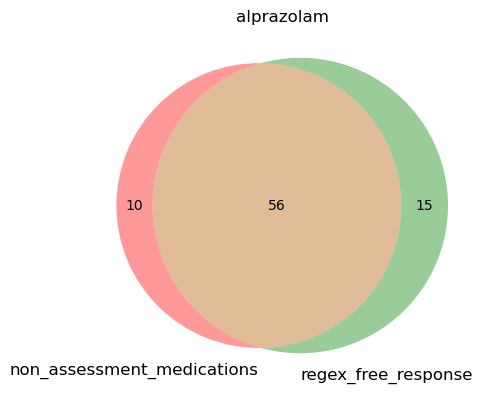

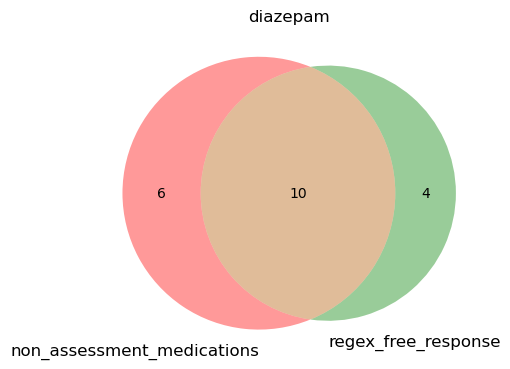

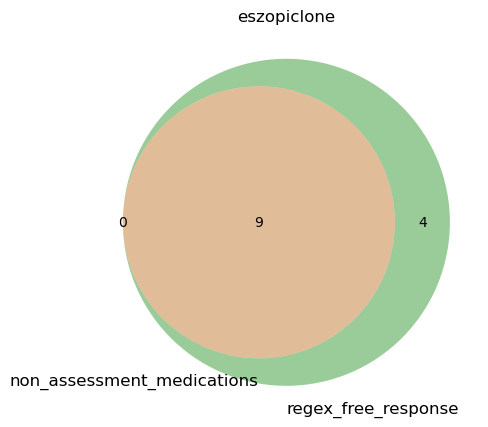

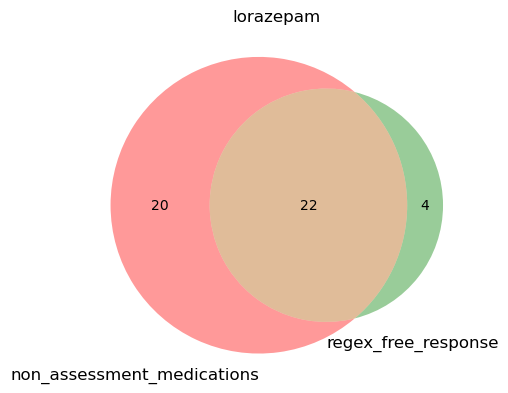

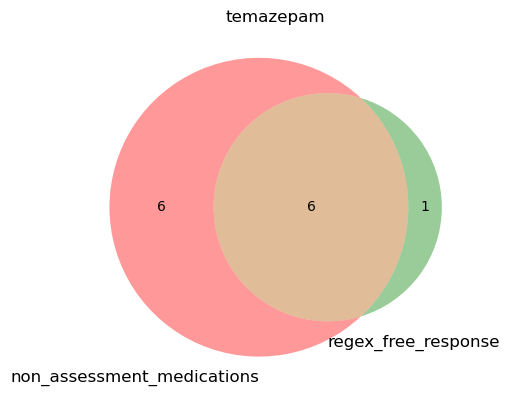

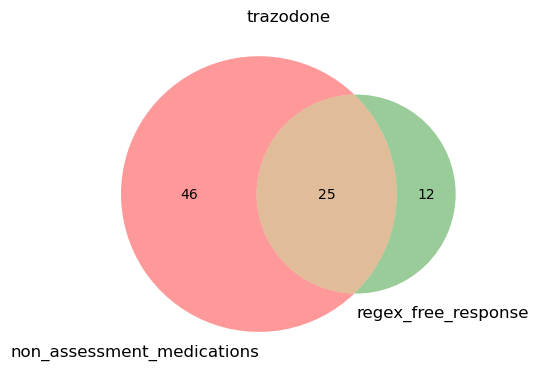

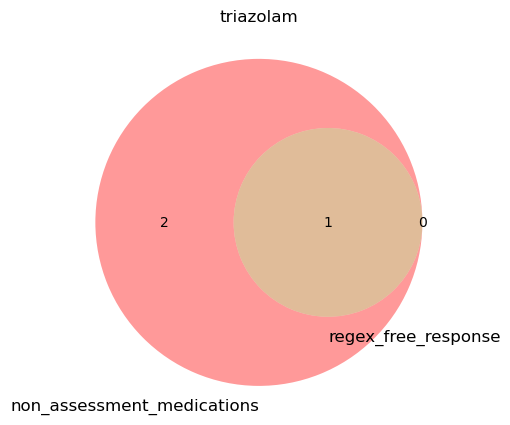

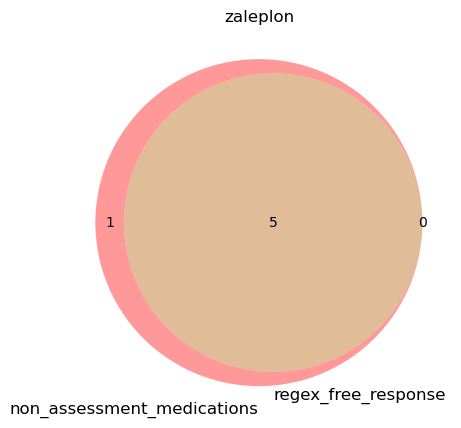

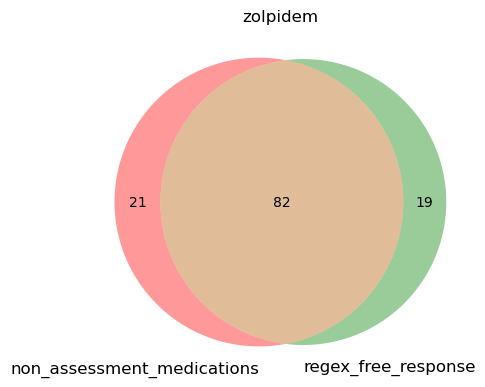

In [262]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn2
import pandas as pd
import numpy as np

regex_unique_by_feature = {}

for feature in med_features:
    df1 = meds_not_assess[meds_not_assess["name"].str.contains(sleep_drug_patterns[feature], regex=True, na=False, case=False)]
    df2 = meds[meds[feature] == True]
    
    set1 = set(df1['public_client_id'])
    set2 = set(df2['public_client_id'])
    
    # IDs in df2 (regex) but not in df1 (non-assessment)
    only_regex_ids = set2 - set1
    df2_unique = df2[df2['public_client_id'].isin(only_regex_ids)]
    
    # Store or process df2_unique as needed
    regex_unique_by_feature[feature] = df2_unique
    
    # Optional: Show Venn diagram
    plt.figure(figsize=(5,5))
    venn = venn2([set1, set2], set_labels=('non_assessment_medications', 'regex_free_response'))
    plt.title(f"{feature}")
    plt.show()


In [263]:
# Let's look through some of the hits from free response that did NOT show up (green slices in venn diagrams above)
# Note, there's 3 more entries than the green slice in the venn diagram above, that's bc some people have multiple responses
# and the venn diagram is only showing unique individuals

# Also, looks good! These are not false positives. It could be that they don't have a medications entry bc they
# already provided the dose in the free responses (below)?
regex_unique_by_feature['alprazolam']["assessment:vitals:prescriptions:text"].tolist()

['Levothyroxine/day, 25mcg, Atenolol 25mg/day, Trazodone 50mg/day, Acyclovir 400mg as needed, Alprazolam .25 mg as needed, Tretinoin Cream 0.05%, Yuvafem 10mcg 2/week',
 'Finesertide (daily), Alprazolam (2x weekly 5 mg?)',
 'Bupropion 150mg BID, Alprazolam 0.25mg as needed',
 'xanax .25mg prn',
 'Levothyroxine - 137\nLevothyronine 5\nXanax - occasionally 5',
 'DEXILANT ORAL 60 MG 1 X DAY\nMUTIVITAMIN ORAL 1 X DAY \ncoenzyme Q10 100mg 3 @ bedtime \nLutein 20 MG  1 @ bedtime \nPRISTIQ 100MG Tb 24 1 @ bedtime \nALPRAZolam 1mg 1 @ bedtime \nCOREG CR ORAL 20 MG 1 @ bedtime\nfurosemide 20 mg 2 1 X day\natorvastatin 40mg 1 @ bedtime\ndigestive probiotic oral 1 @ bedtime\naspirin 325 mg 1 @ bedtime\nLosartan 50 mg 2 1 X day',
 'Synthroid 75 Mcg, Trazadone 50mg, Xanax as needed',
 'Hydrachlorathyazide (25 mg, 1 x day), Lisinopril (30 mg, 1 x day), Rosuvastatin (5 mg, 1 x day), Alprazolam (.5 mg, as needed - maybe a pill every other week), Amoxicillin (2000 mg, only when I go to the dentist - ev

#### Now trying comparing the regex found supplements to the medications df like above

In [264]:
supplement_features

['melatonin',
 'milkThistle',
 'mineral_mag_cal_zinc',
 'multiVit',
 'omega3',
 'prebio',
 'probio',
 'turmeric',
 'vitD']

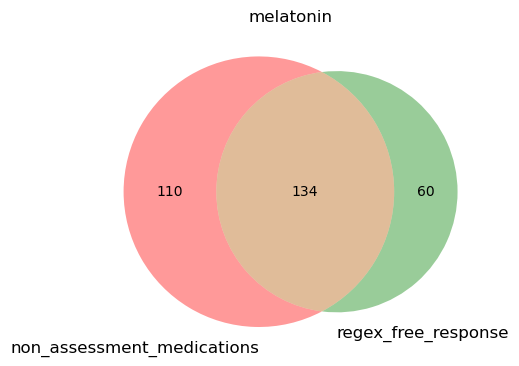

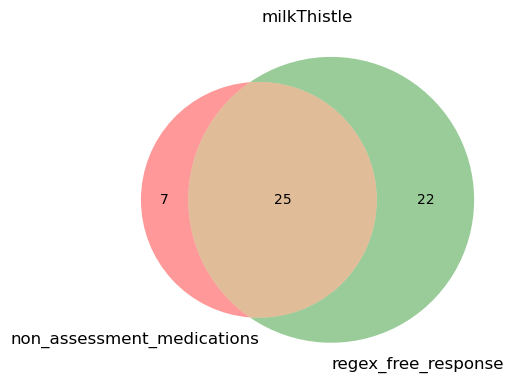

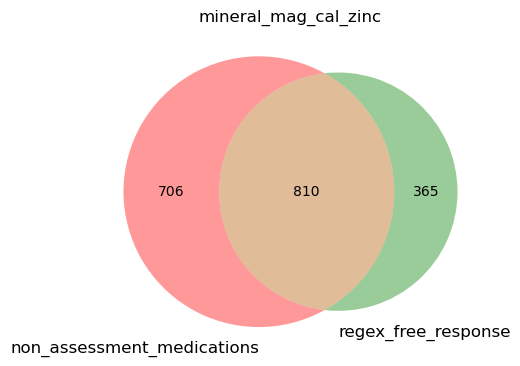

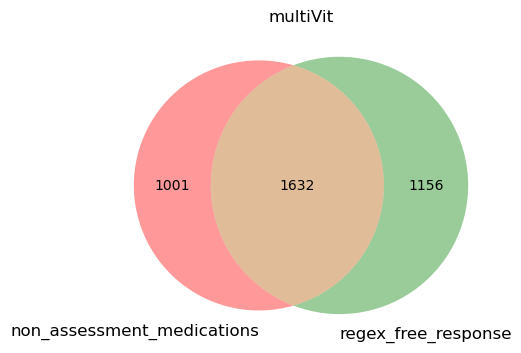

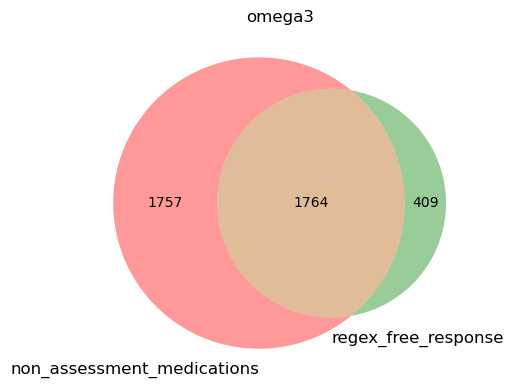

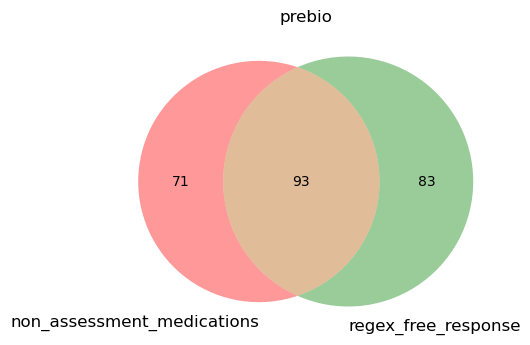

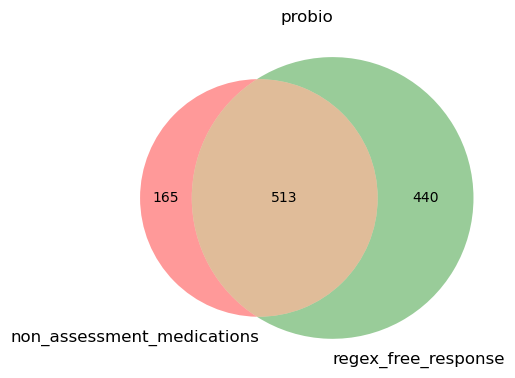

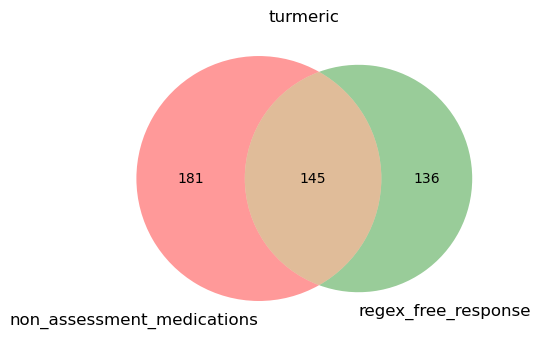

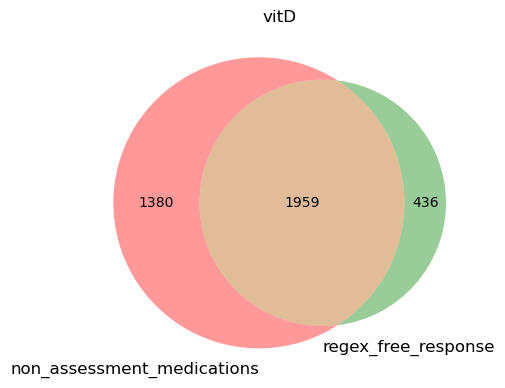

In [265]:
# Use the same approach as above use the supplement_patterns dict w the regex
for feature in supplement_features:
    df1 = meds_not_assess[meds_not_assess["name"].str.contains(supplement_patterns[feature], regex=True, na=False, case=False)]
    df2 = meds[meds[feature] == True]
    
    # Create sets of public_client_id
    set1 = set(df1['public_client_id'])
    set2 = set(df2['public_client_id'])

    # Plot Venn diagram
    plt.figure(figsize=(5, 5))
    venn2([set1, set2], set_labels=('non_assessment_medications', 'regex_free_response'))
    plt.title(f"{feature}")
    plt.show()

#### ^^^Will be including ALL regex_free_response observations. Notably, a subset of these observations also have complement entries in non_assessment_medications, which contains dosage data (but NOT days_in_program).

### Merge onto sleep_merged

<Axes: >

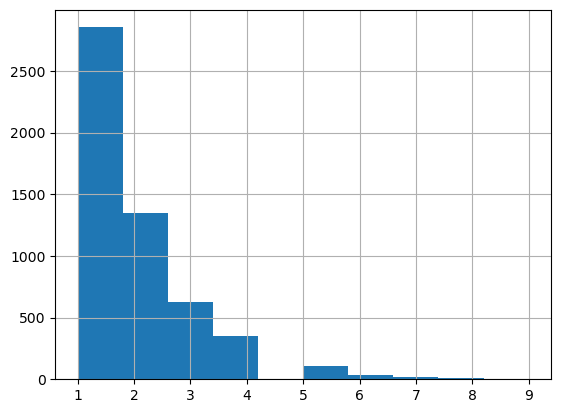

In [266]:
meds.groupby('public_client_id').public_client_id.size().hist()

<Axes: >

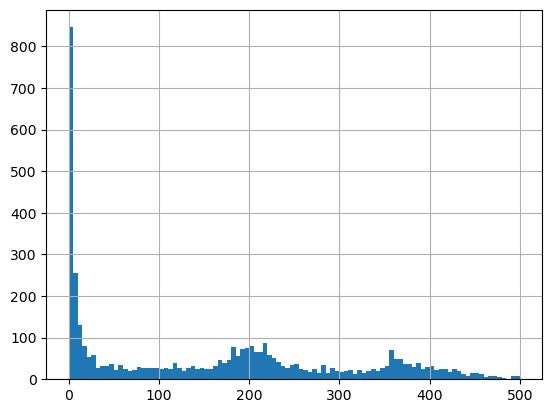

In [267]:
meds.groupby('public_client_id')['days_in_program'].diff().hist(bins=100, range=[0,500])

In [268]:
meds.rename(columns={'vendor': 'supp_meds_vendor'}, inplace=True)
meds_to_merge = meds[['supp_meds_vendor', 'days_in_program', 'public_client_id'] + supplement_features + med_features]
meds_to_merge['supp_meds_dip'] = meds_to_merge.days_in_program
meds_to_merge = meds_to_merge.dropna(subset=['days_in_program', 'public_client_id'])

In [269]:
meds_to_merge.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9729 entries, 0 to 9733
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   supp_meds_vendor      9729 non-null   object 
 1   days_in_program       9729 non-null   float64
 2   public_client_id      9729 non-null   object 
 3   melatonin             9729 non-null   int64  
 4   milkThistle           9729 non-null   int64  
 5   mineral_mag_cal_zinc  9729 non-null   int64  
 6   multiVit              9729 non-null   int64  
 7   omega3                9729 non-null   int64  
 8   prebio                9729 non-null   int64  
 9   probio                9729 non-null   int64  
 10  turmeric              9729 non-null   int64  
 11  vitD                  9729 non-null   int64  
 12  alprazolam            9729 non-null   int64  
 13  diazepam              9729 non-null   int64  
 14  eszopiclone           9729 non-null   int64  
 15  lorazepam             9729

In [270]:
# sort by days_in_program for the merge below
sleep_merged = sleep_merged.sort_values(by='days_in_program')
meds_to_merge = meds_to_merge.sort_values(by='days_in_program')

In [271]:
sleep_merged.shape

(1796, 2789)

In [272]:
# Merge the supplements onto sleep_merged
# decided to use 100 days as tolerance, see above, so that hopefully can get another time point for some people
sleep_merged = pd.merge_asof(
    sleep_merged,
    meds_to_merge[
        meds_to_merge.public_client_id.isin(sleep_merged.public_client_id)
    ],
    by="public_client_id",
    on="days_in_program",
    direction="nearest",
    tolerance=100
)

In [273]:
sleep_merged.shape

(1796, 2809)

#### Update features_dict with dip, vendor, and new main features set

In [274]:
sleep_merged.filter(like='dip').columns

Index(['fitbit_dip', 'reference_microbe_dip', 'reference_fitbit_dip',
       'fitbit_dip_std', 'weights_dip',
       'Bacteria_Actinobacteria_Actinobacteria_Propionibacteriales_Propionibacteriaceae_Acidipropionibacterium_binarized',
       'Bacteria_Actinobacteria_Actinobacteria_Propionibacteriales_Propionibacteriaceae_Acidipropionibacterium',
       'metabolite_dip', 'diet_dip', 'microbe_diet_dip_diff',
       'mental_health_gut_sleep_q_dip', 'digestion_dip', 'supp_meds_dip'],
      dtype='object')

In [275]:
features_dict['dip_features'].append('supp_meds_dip')

In [276]:
# check that it worked:
features_dict['dip_features']

['reference_microbe_dip',
 'weights_dip',
 'fitbit_dip',
 'metabolite_dip',
 'diet_dip',
 'mental_health_gut_sleep_q_dip',
 'digestion_dip',
 'supp_meds_dip']

In [277]:
sleep_merged.supp_meds_vendor.value_counts()

supp_meds_vendor
Assessments    1405
Health 123      343
Name: count, dtype: int64

In [278]:
features_dict['vendor_features'].append('supp_meds_vendor')

In [279]:
# check that it worked:
features_dict['vendor_features']

['microbiome_vendor',
 'diet_vendor',
 'mental_health_gut_sleep_q_vendor',
 'digestion_vendor',
 'supp_meds_vendor']

In [280]:
supplement_features

['melatonin',
 'milkThistle',
 'mineral_mag_cal_zinc',
 'multiVit',
 'omega3',
 'prebio',
 'probio',
 'turmeric',
 'vitD']

In [281]:
med_features

['alprazolam',
 'diazepam',
 'eszopiclone',
 'lorazepam',
 'temazepam',
 'trazodone',
 'triazolam',
 'zaleplon',
 'zolpidem']

In [282]:
features_dict['supplement_features'] = supplement_features
features_dict['med_features'] = med_features

In [283]:
features_dict['supplement_features']

['melatonin',
 'milkThistle',
 'mineral_mag_cal_zinc',
 'multiVit',
 'omega3',
 'prebio',
 'probio',
 'turmeric',
 'vitD']

In [284]:
features_dict['med_features']

['alprazolam',
 'diazepam',
 'eszopiclone',
 'lorazepam',
 'temazepam',
 'trazodone',
 'triazolam',
 'zaleplon',
 'zolpidem']

# Add in clinical chemistries

In [285]:
chem_metadata = get_snapshot('chemistries_metadata')

In [286]:
chem_metadata

,Name,Display Name,Labcorp ID,Labcorp Name,Labcorp LOINC ID,Labcorp LOINC Name,Quest ID,Quest Name,Quest LOINC ID
0,A/G RATIO,A/G ratio,12047.0,A/G Ratio,1759-0,Albumin/Globulin,XGR,A/G RATIO,1759-0
1,"ADIPONECTIN, SERUM",Adiponectin,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ALAT (SGPT),Alanine Transaminase,1545.0,ALT (SGPT),1742-6,Alanine aminotransferase,XGP,ALAT (SGPT),1742-6
3,ALBUMIN,Albumin,1081.0,Albumin,1751-7,Albumin,XAL,ALBUMIN,1751-7
4,ALKALINE PHOSPHATASE,Alkaline Phosphatase,1107.0,Alkaline Phosphatase,6768-6,Alkaline phosphatase,XLK,ALKALINE PHOSPHATASE,6768-6
...,...,...,...,...,...,...,...,...,...
123,WHITE CELL COUNT,White Blood Cell Count,5025.0,WBC,6690-2,Leukocytes,WBC,WHITE CELL COUNT,6690-2
124,ZINC,Zinc,NaN,NaN,NaN,NaN,NaN,NaN,NaN
125,"ZINC, RBC","Zinc, RBC",NaN,NaN,NaN,NaN,ZRBCC,"ZINC, RBC",5761-2
126,leptin,Leptin,NaN,NaN,NaN,NaN,NaN,NaN,NaN


^^^^ Was this used to clean up the clinical chem tsv already?

In [287]:
clinical_chem = get_snapshot('chemistries')

In [288]:
clinical_chem.columns[:13]

Index(['public_client_id', 'vendor', 'vendor_observation_id', 'observation_id',
       'reflexive', 'fasting', 'days_in_program', 'days_since_first_call',
       'days_since_first_draw', 'month', 'weekday', 'season', 'A/G RATIO'],
      dtype='object')

In [289]:
clinical_chem.columns[12:]

Index(['A/G RATIO', 'ADIPONECTIN, SERUM', 'ALAT (SGPT)', 'ALBUMIN',
       'ALKALINE PHOSPHATASE', 'ANTIOXID CAP, TOTAL', 'ARACHIDONIC ACID',
       'ARSENIC, BLOOD', 'ASAT (SGOT)', 'BASOPHILS',
       ...
       'VITAMIN D3, 25-OH', 'VLDL LDL PARTICLE NUMBER', 'VLDL PARTICLE NUMBER',
       'VLDL SIZE PERCENTILE', 'VLDL TRIGLYCERIDES', 'WHITE CELL COUNT',
       'ZINC', 'ZINC, RBC', 'leptin', 'zinc_plasma_or_serum'],
      dtype='object', length=128)

In [290]:
clinical_features = clinical_chem.columns[12:].tolist()

In [291]:
len(clinical_features)

128

In [292]:
clinical_chem.vendor.value_counts()

vendor
LCA      10379
Quest      788
Name: count, dtype: int64

What's 'reflexive' mean? Does it mean if several of a participant's blood tests return past some thresholds then they autmatically get additional tests (in contrast to 'reflective', which I think means a human/clinician manually decides if and which additional tests to do)
https://journals.sagepub.com/doi/full/10.1177/0004563219888541

In [293]:
clinical_chem.reflexive.value_counts()

reflexive
False    7646
True     3521
Name: count, dtype: int64

In [294]:
clinical_chem.reflexive.dtype

dtype('bool')

In [295]:
clinical_chem.fasting.value_counts()

fasting
TRUE     10889
FALSE      225
Name: count, dtype: int64

In [296]:
clinical_chem.fasting.dtype

dtype('O')

#### Interesting, chemistries contains measurements of some of the supplements?

In [297]:
clinical_chem.filter(like='MAG').columns

Index(['MAGNESIUM, SERUM'], dtype='object')

<Axes: >

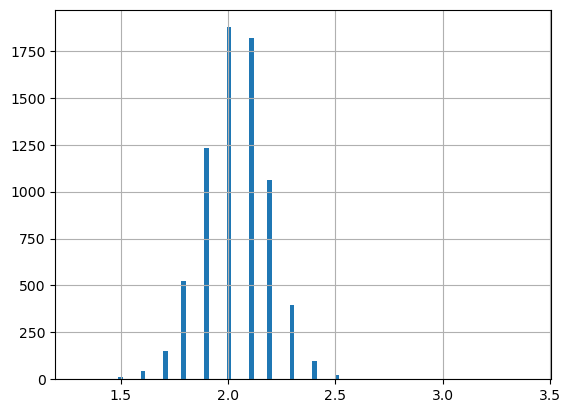

In [298]:
clinical_chem['MAGNESIUM, SERUM'].hist(bins=100)

In [299]:
clinical_chem.filter(like='D3').columns

Index(['VITAMIN D3, 25-OH'], dtype='object')

<Axes: >

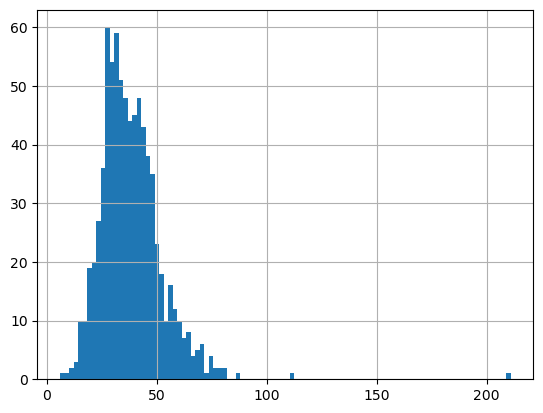

In [300]:
clinical_chem['VITAMIN D3, 25-OH'].hist(bins=100)

In [301]:
clinical_chem.filter(like='DHA').columns

Index(['DHA'], dtype='object')

<Axes: >

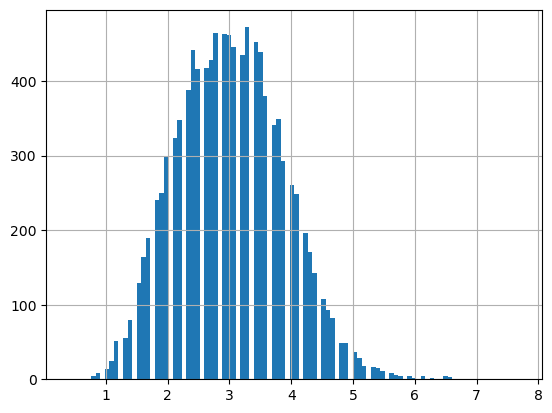

In [302]:
clinical_chem['DHA'].hist(bins=100)

#### Look at how many responses each person has

<Axes: >

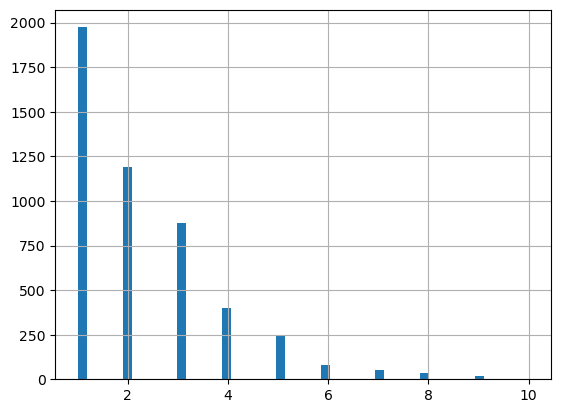

In [303]:
clinical_chem.groupby('public_client_id').public_client_id.size().hist(bins=50)

<Axes: >

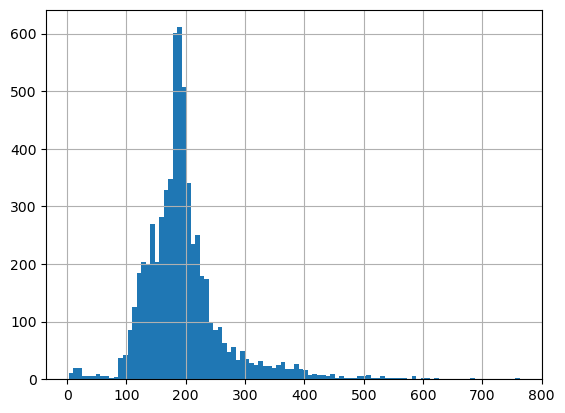

In [304]:
clinical_chem.groupby('public_client_id')['days_in_program'].diff().hist(bins=100)

A lot of people have more than 1 timepoint for clinical chem! And the everage distance between clinical chem collections for an individual is 200ish days

#### Clean up the column names so they are in a nice format for regression formula

In [305]:
import re

def clean_column_name(name):
    # Lowercase
    name = name.lower()
    # Replace any non-alphanumeric characters (except spaces and commas) with underscore
    name = re.sub(r'[^a-z0-9]', '_', name)
    # Remove leading/trailing underscores and collapse multiple underscores
    name = re.sub(r'_+', '_', name).strip('_')
    return name

In [306]:
# Create cleaned column names and mapping
clinical_features_cleaned = [clean_column_name(col) for col in clinical_features]
cleaned_to_original_clinical_feature_names_dict = dict(zip(clinical_features_cleaned, clinical_features))

#### Merge the clinical chemistries onto sleep_merged

In [307]:
clinical_chem_to_merge = clinical_chem[['public_client_id', 'days_in_program', 'vendor', 'reflexive', 'fasting']+clinical_features]

In [308]:
# map the new column names to the df
clinical_chem_to_merge.rename(columns=dict(zip(clinical_features, clinical_features_cleaned)), inplace=True)

In [309]:
clinical_chem_to_merge

,public_client_id,days_in_program,vendor,reflexive,fasting,a_g_ratio,adiponectin_serum,alat_sgpt,albumin,alkaline_phosphatase,...,vitamin_d3_25_oh,vldl_ldl_particle_number,vldl_particle_number,vldl_size_percentile,vldl_triglycerides,white_cell_count,zinc,zinc_rbc,leptin,zinc_plasma_or_serum
0,01000261,65,Quest,False,TRUE,2.0,10.4,12.0,4.5,43.0,...,58.0,NaN,NaN,NaN,NaN,5.9,980.0,9.8,NaN,NaN
1,01000261,198,LCA,False,TRUE,2.0,12.4,12.0,4.3,40.0,...,NaN,1753.0,45.5,48.9,69.1,4.9,1410.0,NaN,NaN,NaN
2,01001298,7,LCA,False,TRUE,1.8,NaN,25.0,4.2,63.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,01001467,15,LCA,False,TRUE,1.3,NaN,24.0,4.0,55.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,01001467,223,LCA,True,TRUE,1.7,NaN,33.0,4.5,58.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11162,ZU273983,1,LCA,False,TRUE,1.5,NaN,13.0,4.4,113.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11163,ZU612255,3,LCA,True,TRUE,1.2,3.4,11.0,3.9,67.0,...,NaN,NaN,NaN,NaN,NaN,10.6,NaN,NaN,NaN,83.0
11164,ZU621944,6,LCA,False,TRUE,1.6,3.5,52.0,4.3,56.0,...,NaN,NaN,NaN,NaN,NaN,5.7,NaN,NaN,NaN,79.0
11165,ZU621944,222,LCA,True,TRUE,1.6,NaN,78.0,4.3,65.0,...,NaN,NaN,NaN,NaN,NaN,5.8,NaN,NaN,NaN,NaN


In [310]:
clinical_chem_to_merge['reflexive'] = clinical_chem_to_merge['reflexive'].astype('Int64')
clinical_chem_to_merge['fasting'] = clinical_chem_to_merge['fasting'].str.upper().map({'TRUE': 1, 'FALSE': 0}).astype('Int64')
clinical_chem_to_merge['days_in_program'] = clinical_chem_to_merge['days_in_program'].astype(float)
clinical_chem_to_merge = clinical_chem_to_merge.dropna(subset=['public_client_id', 'days_in_program'])

In [311]:
# make sure the dtype conversion worked for reflexive and fasting columns
clinical_chem_to_merge.reflexive.value_counts()

reflexive
0    7646
1    3521
Name: count, dtype: Int64

In [312]:
clinical_chem_to_merge.reflexive.dtype

Int64Dtype()

In [313]:
clinical_chem_to_merge.fasting.value_counts()

fasting
1    10889
0      225
Name: count, dtype: Int64

In [314]:
clinical_chem_to_merge.fasting.dtype

Int64Dtype()

In [315]:
clinical_chem_to_merge['clinical_dip'] = clinical_chem_to_merge.days_in_program
clinical_chem_to_merge.rename(columns={'vendor': 'clinical_vendor'}, inplace=True)

In [316]:
# sort by days_in_program for the merge below
sleep_merged = sleep_merged.sort_values(by='days_in_program')
clinical_chem_to_merge = clinical_chem_to_merge.sort_values(by='days_in_program')

In [317]:
# Merge the diet onto sleep_merged
# decided to use 15 days as tolerance, see below there is good amount of N for each column
sleep_merged = pd.merge_asof(
    sleep_merged,
    clinical_chem_to_merge[
        clinical_chem_to_merge.public_client_id.isin(sleep_merged.public_client_id)
    ],
    by="public_client_id",
    on="days_in_program",
    direction="nearest",
    tolerance=15
)

<Axes: >

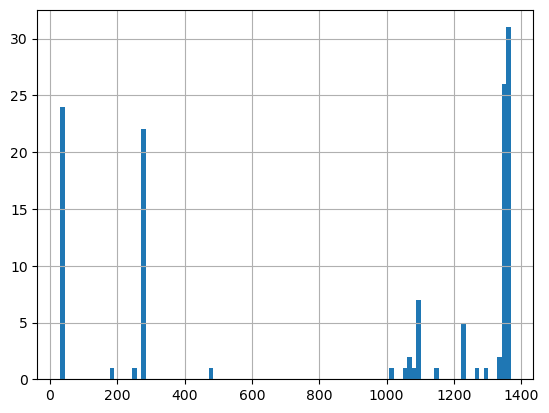

In [318]:
sleep_merged[clinical_features_cleaned].count().hist(bins=100)

In [319]:
sleep_merged[clinical_features_cleaned].count().describe()

count     128.000000
mean      864.734375
std       569.312882
min        30.000000
25%       276.000000
50%      1224.500000
75%      1352.250000
max      1369.000000
dtype: float64

^^^ Great! Most columns have more than 200 non null values

#### Quickly look to see how far away the diet dip are on average from microbe dip
first run cell above with NO TOLERNACE (comment out tolerance in the merge), to see average time of days in program between microbiome dip and clinical chem dip

In [320]:
sleep_merged['microbe_clinical_dip_diff'] = sleep_merged.reference_microbe_dip - sleep_merged.clinical_dip

<Axes: >

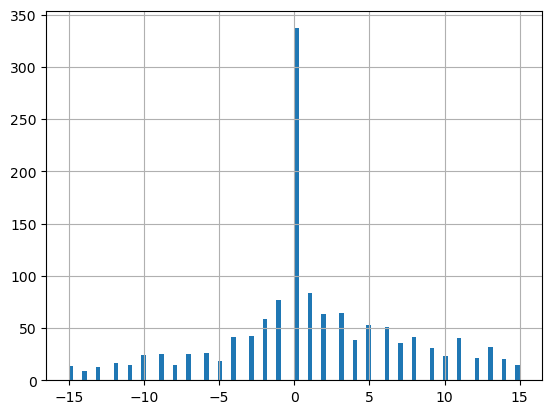

In [321]:
sleep_merged[clinical_features_cleaned + ['microbe_clinical_dip_diff', 'clinical_dip']].dropna(subset=['clinical_dip']).microbe_clinical_dip_diff.hist(bins=100)

In [322]:
sleep_merged[clinical_features_cleaned + ['microbe_clinical_dip_diff', 'clinical_dip']].dropna(subset=['clinical_dip']).microbe_clinical_dip_diff.between(-100, 100).sum()

1370

In [323]:
sleep_merged[clinical_features_cleaned + ['microbe_clinical_dip_diff', 'clinical_dip']].dropna(subset=['clinical_dip']).microbe_clinical_dip_diff.between(-15, 15).sum()

1370

In [324]:
sleep_merged.clinical_dip.info()

<class 'pandas.core.series.Series'>
RangeIndex: 1796 entries, 0 to 1795
Series name: clinical_dip
Non-Null Count  Dtype  
--------------  -----  
1370 non-null   float64
dtypes: float64(1)
memory usage: 14.2 KB


### Update features_dict with dip, vendor, and new main features set (ie clinical_features)

In [325]:
sleep_merged.filter(like='dip').columns

Index(['fitbit_dip', 'reference_microbe_dip', 'reference_fitbit_dip',
       'fitbit_dip_std', 'weights_dip',
       'Bacteria_Actinobacteria_Actinobacteria_Propionibacteriales_Propionibacteriaceae_Acidipropionibacterium_binarized',
       'Bacteria_Actinobacteria_Actinobacteria_Propionibacteriales_Propionibacteriaceae_Acidipropionibacterium',
       'metabolite_dip', 'diet_dip', 'microbe_diet_dip_diff',
       'mental_health_gut_sleep_q_dip', 'digestion_dip', 'supp_meds_dip',
       'adiponectin_serum', 'clinical_dip', 'microbe_clinical_dip_diff'],
      dtype='object')

In [326]:
features_dict['dip_features'].append('clinical_dip')

In [327]:
# check that it worked:
features_dict['dip_features']

['reference_microbe_dip',
 'weights_dip',
 'fitbit_dip',
 'metabolite_dip',
 'diet_dip',
 'mental_health_gut_sleep_q_dip',
 'digestion_dip',
 'supp_meds_dip',
 'clinical_dip']

In [328]:
sleep_merged.clinical_vendor.value_counts()

clinical_vendor
LCA      1094
Quest     276
Name: count, dtype: int64

In [329]:
features_dict['vendor_features'].append('clinical_vendor')

In [330]:
# check that it worked:
features_dict['vendor_features']

['microbiome_vendor',
 'diet_vendor',
 'mental_health_gut_sleep_q_vendor',
 'digestion_vendor',
 'supp_meds_vendor',
 'clinical_vendor']

In [331]:
features_dict['clinical_features'] = clinical_features_cleaned

In [332]:
features_dict['clinical_features']

['a_g_ratio',
 'adiponectin_serum',
 'alat_sgpt',
 'albumin',
 'alkaline_phosphatase',
 'antioxid_cap_total',
 'arachidonic_acid',
 'arsenic_blood',
 'asat_sgot',
 'basophils',
 'basophils_absolute',
 'bilirubin_direct',
 'bilirubin_indirect',
 'bilirubin_total',
 'bun_creat_ratio',
 'calcium',
 'carbon_dioxide_co2',
 'chloride',
 'cholesterol_total',
 'copper_rbc',
 'creatinine_enz_ser',
 'crp_high_sensitivity',
 'dha',
 'dpa',
 'eosinophils',
 'eosinophils_absolute',
 'epa',
 'epa_aa',
 'ferritin',
 'folic_acid_serum',
 'gfr_mdrd',
 'gfr_mdrd_african_am',
 'ggt',
 'globulin',
 'glucose',
 'glutathione_total',
 'glycohemoglobin_a1c',
 'hdl_chol_direct',
 'hdl_large',
 'hdl_particle_number',
 'hdl_particle_percentile',
 'hdl_size_percentile',
 'hematocrit',
 'hemoglobin',
 'homa_ir',
 'homocysteine_serum',
 'idl_particle_number',
 'il_6',
 'il_8',
 'immature_granulocytes',
 'immature_granulocytes_absolute',
 'insulin',
 'lactic_dehydrogenase',
 'large_hdl_particle_percentile',
 'large_

# Add in proteomics

In [333]:
proteomics = get_snapshot('proteomics_corrected')

In [334]:
proteomics.columns[:20]

Index(['public_client_id', 'sample_id', 'Chip_ID_CAM', 'Chip_ID_CRE',
       'Chip_ID_CVD2', 'Chip_ID_CVD3', 'Chip_ID_DEV', 'Chip_ID_INF',
       'Chip_ID_IRE', 'Chip_ID_MET', 'Chip_ID_NEU1', 'Chip_ID_NEX',
       'Chip_ID_ODA', 'Chip_ID_ONC2', 'Chip_ID_ONC3', 'days_in_program',
       'days_since_first_call', 'days_since_first_draw', 'month', 'weekday'],
      dtype='object')

In [335]:
# List of all "Chip_ID_" columns
chip_columns = [col for col in proteomics.columns if col.startswith("Chip_ID_")]

# Permissible non-null columns
required_present = ['Chip_ID_CVD2', 'Chip_ID_CVD3', 'Chip_ID_INF']

# All other "Chip_ID_" columns must be null
required_null = [col for col in chip_columns if col not in required_present]

# Apply the filter
filtered_proteomics = proteomics[
    proteomics[required_null].isna().all(axis=1)        # All other chip columns must be null
]

In [336]:
filtered_proteomics[chip_columns].info()

<class 'pandas.core.frame.DataFrame'>
Index: 5460 entries, 0 to 6111
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Chip_ID_CAM   0 non-null      object
 1   Chip_ID_CRE   0 non-null      object
 2   Chip_ID_CVD2  5460 non-null   object
 3   Chip_ID_CVD3  5460 non-null   object
 4   Chip_ID_DEV   0 non-null      object
 5   Chip_ID_INF   5460 non-null   object
 6   Chip_ID_IRE   0 non-null      object
 7   Chip_ID_MET   0 non-null      object
 8   Chip_ID_NEU1  0 non-null      object
 9   Chip_ID_NEX   0 non-null      object
 10  Chip_ID_ODA   0 non-null      object
 11  Chip_ID_ONC2  0 non-null      object
 12  Chip_ID_ONC3  0 non-null      object
dtypes: object(13)
memory usage: 597.2+ KB


In [337]:
nonzero_cols = filtered_proteomics.columns[21:][filtered_proteomics[filtered_proteomics.columns[21:]].notna().sum() > 0].tolist()

In [338]:
nonzero_cols

['CVD2_O00182',
 'CVD2_O00220',
 'CVD2_O00253',
 'CVD2_O14763',
 'CVD2_O14836',
 'CVD2_O43915',
 'CVD2_O94907',
 'CVD2_P00797',
 'CVD2_P01127',
 'CVD2_P01241',
 'CVD2_P01730',
 'CVD2_P01833',
 'CVD2_P02760',
 'CVD2_P04179',
 'CVD2_P04792',
 'CVD2_P05231',
 'CVD2_P06858',
 'CVD2_P07204',
 'CVD2_P07585',
 'CVD2_P07711',
 'CVD2_P09237',
 'CVD2_P09341',
 'CVD2_P09601',
 'CVD2_P09874',
 'CVD2_P10147',
 'CVD2_P12104',
 'CVD2_P12931',
 'CVD2_P13726',
 'CVD2_P16860',
 'CVD2_P18510',
 'CVD2_P19883',
 'CVD2_P21583',
 'CVD2_P21980',
 'CVD2_P22004',
 'CVD2_P24394',
 'CVD2_P25116',
 'CVD2_P26022',
 'CVD2_P27352',
 'CVD2_P29965',
 'CVD2_P31994',
 'CVD2_P31997',
 'CVD2_P35218',
 'CVD2_P35318',
 'CVD2_P35442',
 'CVD2_P35475',
 'CVD2_P39900',
 'CVD2_P40225',
 'CVD2_P41159',
 'CVD2_P47992',
 'CVD2_P49763',
 'CVD2_P51161',
 'CVD2_P51888',
 'CVD2_P78380',
 'CVD2_Q02763',
 'CVD2_Q04760',
 'CVD2_Q12866',
 'CVD2_Q13043',
 'CVD2_Q13219',
 'CVD2_Q14005',
 'CVD2_Q14116',
 'CVD2_Q14242',
 'CVD2_Q15109',
 'CVD2_Q

In [339]:
len(nonzero_cols)

276

In [340]:
# Column distributions look pretty centered!
filtered_proteomics[nonzero_cols].describe()

,CVD2_O00182,CVD2_O00220,CVD2_O00253,CVD2_O14763,CVD2_O14836,CVD2_O43915,CVD2_O94907,CVD2_P00797,CVD2_P01127,CVD2_P01241,...,INF_Q99748,INF_Q9BZW8,INF_Q9GZV9,INF_Q9H5V8,INF_Q9NRJ3,INF_Q9NSA1,INF_Q9NYY1,INF_Q9NZQ7,INF_Q9P0M4,INF_Q9UHF4
count,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,...,5459.000000,5459.000000,5459.000000,5459.000000,5459.000000,5459.000000,5459.000000,5459.000000,5459.000000,5459.000000
mean,9.427847,3.149386,4.723724,5.571709,9.606637,7.816899,9.744586,8.075090,10.971322,8.331390,...,0.660563,6.973927,3.004760,3.138486,2.540680,4.573817,1.079744,4.921926,1.151781,-0.108701
std,0.360225,0.341102,0.466492,0.507787,0.411753,0.411885,0.635480,0.733036,0.728380,2.143574,...,0.491040,0.508724,0.522455,0.581335,0.410474,1.228435,0.407772,0.494696,0.489403,0.551173
min,4.448690,1.773425,2.195340,3.885390,5.487900,3.370610,4.946350,2.057820,6.135715,2.846270,...,-0.390435,4.471155,0.876305,-0.406985,1.325385,0.877810,-0.875615,2.763200,-0.075305,-1.193925
25%,9.196085,2.935701,4.433389,5.335899,9.357768,7.565968,9.346941,7.627842,10.634765,6.600977,...,0.433580,6.650597,2.697788,2.747055,2.282822,3.743247,0.888040,4.643421,0.846777,-0.406517
50%,9.414130,3.131221,4.717425,5.537343,9.592164,7.832305,9.769550,8.045358,11.103805,8.246881,...,0.589215,6.941565,2.956480,3.071040,2.498555,4.561045,1.016595,4.874025,1.095435,-0.236530
75%,9.656475,3.342135,5.002936,5.761798,9.843966,8.091885,10.159615,8.460671,11.470337,10.161976,...,0.759435,7.254235,3.242075,3.454450,2.741890,5.427390,1.171148,5.124425,1.370458,0.006367
max,11.436965,8.502525,8.786525,13.695045,12.820050,9.016165,12.011570,11.436205,13.028555,12.730075,...,7.475858,10.164780,8.820055,6.887445,5.979355,10.739100,6.590350,9.657005,8.565430,5.815925


<Axes: >

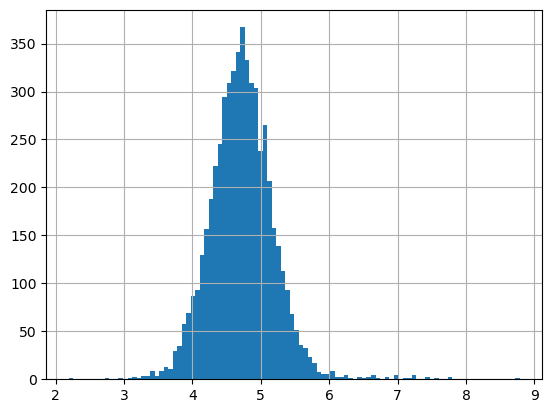

In [341]:
filtered_proteomics.CVD2_O00253.hist(bins=100)

In [342]:
features_dict['proteomics_features'] = nonzero_cols

In [343]:
proteomics_to_merge = filtered_proteomics[['public_client_id', 'days_in_program'] + features_dict['proteomics_features']]
proteomics_to_merge = proteomics_to_merge.dropna(subset=['public_client_id', 'days_in_program'])
proteomics_to_merge['days_in_program'] = proteomics_to_merge.days_in_program.astype('float')
proteomics_to_merge['proteomics_dip'] = proteomics_to_merge.days_in_program
proteomics_to_merge = proteomics_to_merge.sort_values(by='days_in_program')

In [344]:
import re
# Clean column names to repalce any non alphanumeric characters with an underscore
proteomics_to_merge.columns = [re.sub(r'\W+', '_', col) for col in proteomics_to_merge.columns]

In [345]:
features_dict['proteomics_features'] = proteomics_to_merge.columns.tolist()[2:-1]

In [346]:
features_dict['dip_features'].append('proteomics_dip')

In [347]:
features_dict['dip_features']

['reference_microbe_dip',
 'weights_dip',
 'fitbit_dip',
 'metabolite_dip',
 'diet_dip',
 'mental_health_gut_sleep_q_dip',
 'digestion_dip',
 'supp_meds_dip',
 'clinical_dip',
 'proteomics_dip']

In [348]:
proteomics_to_merge.shape

(5460, 279)

In [349]:
# Merge proteomics onto sleep merged using a tolerance of 15 days
sleep_merged = pd.merge_asof(
    sleep_merged,
    proteomics_to_merge[
        proteomics_to_merge.public_client_id.isin(sleep_merged.public_client_id)
    ],
    by="public_client_id",
    on="days_in_program",
    direction="nearest",
    tolerance=15
)

In [350]:
len(features_dict['proteomics_features'])

276

In [351]:
features_dict['proteomics_features']

['CVD2_O00182',
 'CVD2_O00220',
 'CVD2_O00253',
 'CVD2_O14763',
 'CVD2_O14836',
 'CVD2_O43915',
 'CVD2_O94907',
 'CVD2_P00797',
 'CVD2_P01127',
 'CVD2_P01241',
 'CVD2_P01730',
 'CVD2_P01833',
 'CVD2_P02760',
 'CVD2_P04179',
 'CVD2_P04792',
 'CVD2_P05231',
 'CVD2_P06858',
 'CVD2_P07204',
 'CVD2_P07585',
 'CVD2_P07711',
 'CVD2_P09237',
 'CVD2_P09341',
 'CVD2_P09601',
 'CVD2_P09874',
 'CVD2_P10147',
 'CVD2_P12104',
 'CVD2_P12931',
 'CVD2_P13726',
 'CVD2_P16860',
 'CVD2_P18510',
 'CVD2_P19883',
 'CVD2_P21583',
 'CVD2_P21980',
 'CVD2_P22004',
 'CVD2_P24394',
 'CVD2_P25116',
 'CVD2_P26022',
 'CVD2_P27352',
 'CVD2_P29965',
 'CVD2_P31994',
 'CVD2_P31997',
 'CVD2_P35218',
 'CVD2_P35318',
 'CVD2_P35442',
 'CVD2_P35475',
 'CVD2_P39900',
 'CVD2_P40225',
 'CVD2_P41159',
 'CVD2_P47992',
 'CVD2_P49763',
 'CVD2_P51161',
 'CVD2_P51888',
 'CVD2_P78380',
 'CVD2_Q02763',
 'CVD2_Q04760',
 'CVD2_Q12866',
 'CVD2_Q13043',
 'CVD2_Q13219',
 'CVD2_Q14005',
 'CVD2_Q14116',
 'CVD2_Q14242',
 'CVD2_Q15109',
 'CVD2_Q

# Add in MICOM predicted metabolites

In [2]:
micom_wide = pd.read_csv('independent_feature_dataframes/micom_metabolites_wide_06-12-2025.csv', dtype={'public_client_id': object})

In [3]:
micom_wide

,public_client_id,micom_0,micom_1,micom_10,micom_100,micom_101,micom_102,micom_103,micom_104,micom_105,...,micom_90,micom_91,micom_92,micom_93,micom_94,micom_95,micom_96,micom_97,micom_98,micom_99
0,01002183,11.039158,4.332710,0.000477,47.706174,0.643140,0.149817,0.465461,0.448077,3.805691,...,5.233558,1.848037,0.248628,0.025224,0.000654,25.007138,25.651636,30.380144,1.133334,5.846328
1,01002192,9.422306,6.302439,0.000480,25.258484,7.758520,0.133274,0.458905,0.460661,7.517042,...,5.710737,8.991745,0.284024,0.027661,0.000730,21.065836,40.933027,21.333236,0.130094,3.602499
2,01002885,4.272377,4.712637,0.000477,27.144682,0.684603,0.252827,0.175379,0.148076,10.947923,...,6.286834,1.620396,0.299061,0.000388,0.000708,23.698634,38.545496,17.404565,0.100588,13.653692
3,01003411,7.063549,2.362768,0.000441,19.807848,10.987223,0.204262,0.268669,0.233535,7.218252,...,5.319521,12.134873,0.283866,0.004383,0.000640,17.060062,34.179053,28.223654,0.145194,4.719768
4,01003555,1.933662,5.608756,0.000442,13.978230,17.639725,0.124210,0.361183,0.380121,15.886021,...,4.997650,18.846729,0.278694,NaN,0.000741,21.280255,23.248794,18.853176,0.106626,5.160401
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1788,HX821762,5.428197,3.200666,0.000465,9.170614,14.283174,0.253639,NaN,NaN,16.979737,...,6.042084,16.485133,0.321782,0.004511,0.000769,23.965796,26.213207,24.843840,0.301970,4.530447
1789,HX908582,0.765598,10.860955,0.000390,18.272484,2.370971,0.307669,NaN,NaN,0.964738,...,4.867190,14.489923,0.300237,0.005700,0.000684,18.192886,30.712192,14.086170,1.513676,9.164803
1790,HX932346,7.674790,22.458428,0.000494,43.496542,1.092591,0.125972,0.494407,0.457489,14.683232,...,7.105817,1.573840,0.253080,0.027713,0.000715,23.130548,39.323425,27.755719,0.143568,8.113963
1791,HX963635,7.867461,23.028922,0.000471,39.312161,9.417001,0.155188,0.467975,0.443200,8.496613,...,5.581670,12.945983,0.292340,0.272560,0.000749,21.015806,37.485797,18.253797,0.900425,8.710307


In [10]:
(micom_wide == 0).any().sum()

0

In [12]:
import itertools

identical_pairs = []

for col1, col2 in itertools.combinations(micom_wide.columns, 2):
    if micom_wide[col1].equals(micom_wide[col2]):
        identical_pairs.append((col1, col2))

identical_pairs

[('micom_10', 'micom_11'),
 ('micom_10', 'micom_129'),
 ('micom_10', 'micom_9'),
 ('micom_11', 'micom_129'),
 ('micom_11', 'micom_9'),
 ('micom_129', 'micom_9')]

In [34]:
# Open the dict with the micom codes to names
with open('independent_feature_dataframes/micom_features_codes_to_names.json', 'r') as f:
    micom_name_dict = json.load(f)

In [36]:
micom_name_dict['micom_129']

'3-Deoxy-D-manno-2-octulosonate'

In [40]:
# All the duplicate columns are rare sugars in rhamnogalacturonan II
pd.Series(micom_name_dict)[
    pd.Series(micom_name_dict).str.contains('rhamno', case=False)
]

micom_9     2-o-methylfucose (rare sugar in rhamnogalactur...
micom_10    2-O-methylxylose (rare sugar in rhamnogalactur...
micom_11    3-deoxy-d-lyxo-heptulosaric acid (rare sugar i...
micom_33    Aceric acid (3-C-carboxy-5-deoxy-l-xylose) (ra...
micom_51       D-Apiose (rare sugar in rhamnogalacturonan II)
dtype: object

^^ These are ALL components of rhamnogalacturonan II (https://pubmed.ncbi.nlm.nih.gov/15377216/ https://pubmed.ncbi.nlm.nih.gov/7997476/), including octulosonate (https://pubchem.ncbi.nlm.nih.gov/compound/119228#section=Food-Additives-and-Ingredients). What is rhamnogalacturonan II? It is a polysaccharide component of pectin in plants: https://en.wikipedia.org/wiki/Rhamnogalacturonan-II

In [355]:
micom_features = micom_wide.columns.tolist()[1:]

In [356]:
sleep_merged = pd.merge(sleep_merged, micom_wide, on='public_client_id', how='inner')

In [357]:
sleep_merged.shape

(1793, 3843)

In [358]:
len(micom_features)

624

In [359]:
features_dict['micom_features'] = micom_features

In [360]:
features_dict.keys()

dict_keys(['heartrate_features', 'activity_features', 'sleep_features', 'covariate_features', 'sleep_features_log1p', 'sleep_features_log1p_resids', 'activity_features_resids', 'heartrate_features_resids', 'vendor_features', 'new_microbe_binarized_features', 'new_microbe_features_binary_10_90', 'new_microbe_features', 'diversity_features', 'dip_features', 'metabolite_features', 'food_freq_features', 'food_freq_features_daily', 'food_freq_from_non_freq_features', 'food_freq_from_non_freq_features_daily', 'diet_daily_features', 'gut_q_features', 'mental_health_q_features', 'sleep_disorder_q_features', 'digestion_features', 'supplement_features', 'med_features', 'clinical_features', 'proteomics_features', 'micom_features'])

# Check numeric feature sets and decide on transformations

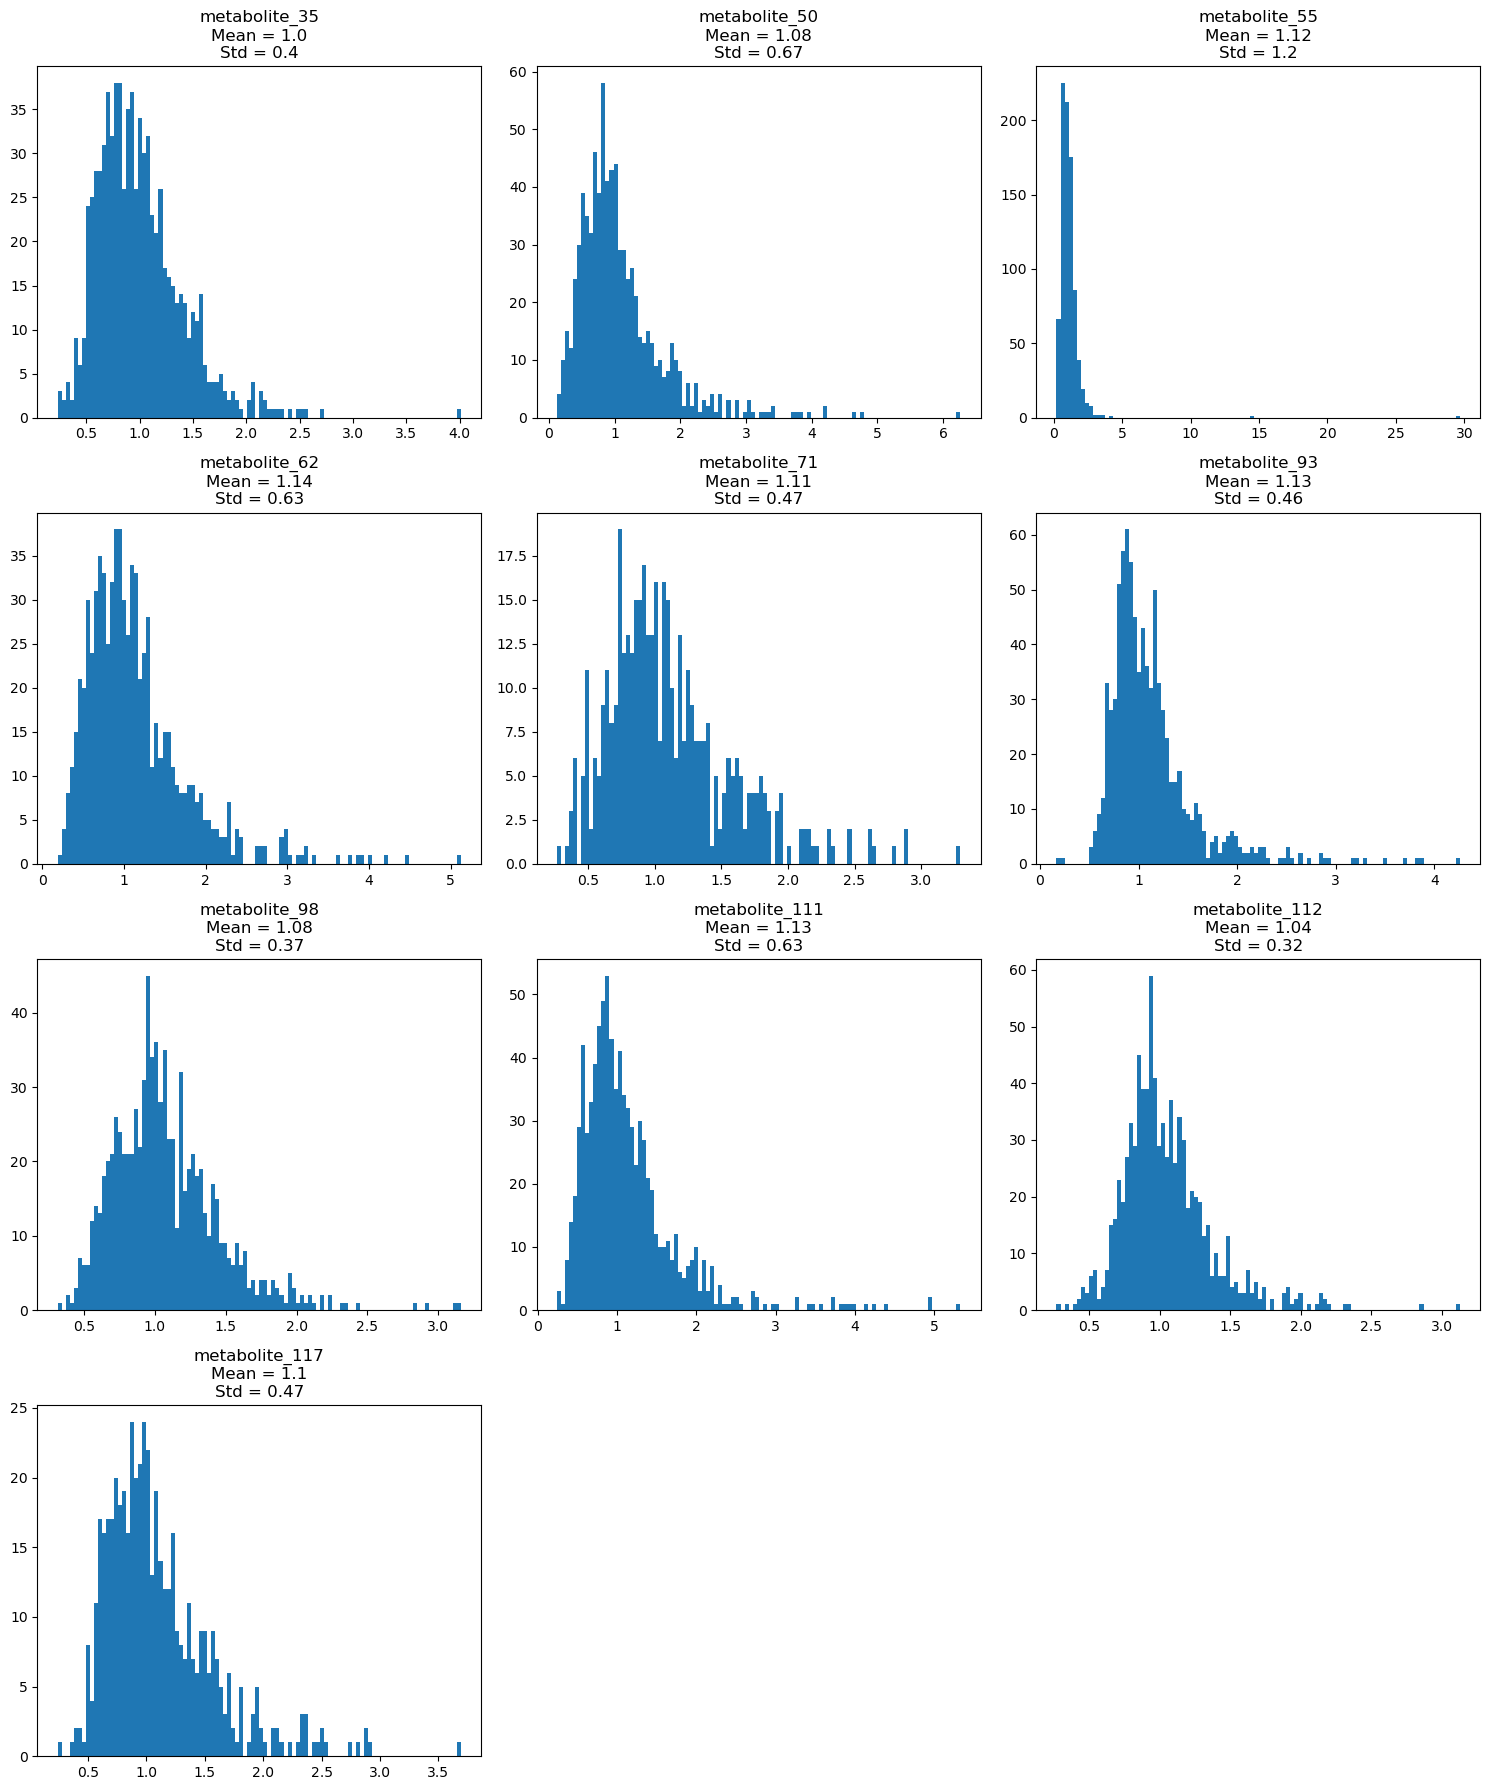

In [361]:
# these will need log transform
plot_histograms(sleep_merged, features_dict['metabolite_features'][:10])

In [362]:
sleep_merged[features_dict['metabolite_features']].describe()

,metabolite_35,metabolite_50,metabolite_55,metabolite_62,metabolite_71,metabolite_93,metabolite_98,metabolite_111,metabolite_112,metabolite_117,...,metabolite_999953114,metabolite_999953157,metabolite_999953172,metabolite_999953266,metabolite_999953267,metabolite_999954831,metabolite_999954832,metabolite_999954834,metabolite_999954839,metabolite_999954840
count,795.000000,777.000000,849.000000,766.000000,433.000000,844.000000,841.000000,853.000000,849.000000,513.000000,...,689.000000,760.000000,630.000000,509.000000,679.000000,362.000000,368.000000,365.000000,370.000000,670.000000
mean,0.999504,1.083142,1.116201,1.142866,1.109708,1.126728,1.075882,1.132010,1.044689,1.103037,...,1.098138,1.076760,1.106398,1.245884,1.150469,1.008757,1.028252,1.034523,1.239653,1.130479
std,0.403233,0.674704,1.198682,0.626961,0.474142,0.458306,0.373037,0.626843,0.317955,0.465904,...,0.540061,0.476303,0.685200,0.844282,0.637702,0.090727,0.240853,0.224879,1.025756,0.947717
min,0.232199,0.124644,0.209632,0.189714,0.264614,0.167351,0.315394,0.243119,0.267626,0.239885,...,0.203655,0.148926,0.085560,0.111320,0.202700,0.804878,0.634143,0.659046,0.112007,0.237470
25%,0.710659,0.667077,0.708192,0.722285,0.779882,0.847159,0.818486,0.750079,0.849280,0.773245,...,0.737251,0.761491,0.665345,0.648603,0.795186,0.953918,0.872755,0.892045,0.588545,0.731812
50%,0.934468,0.928676,0.959422,1.004791,1.014378,1.021516,1.017026,0.984352,0.986142,0.997235,...,0.985380,0.999878,0.957514,1.047552,1.041174,0.991603,0.979522,0.985246,0.955781,0.988973
75%,1.197135,1.298921,1.317324,1.378238,1.337552,1.253064,1.264030,1.330519,1.180273,1.314714,...,1.339382,1.292661,1.386181,1.646040,1.352194,1.060569,1.109394,1.104629,1.495847,1.321812
max,4.012930,6.264434,29.671239,5.127817,3.295586,4.258424,3.159263,5.328386,3.127110,3.692737,...,4.321933,3.844116,6.191819,6.124908,9.026948,1.400176,2.395892,2.155511,7.742192,16.020440


In [363]:
(sleep_merged[features_dict['metabolite_features']] == 0).any().sum()

0

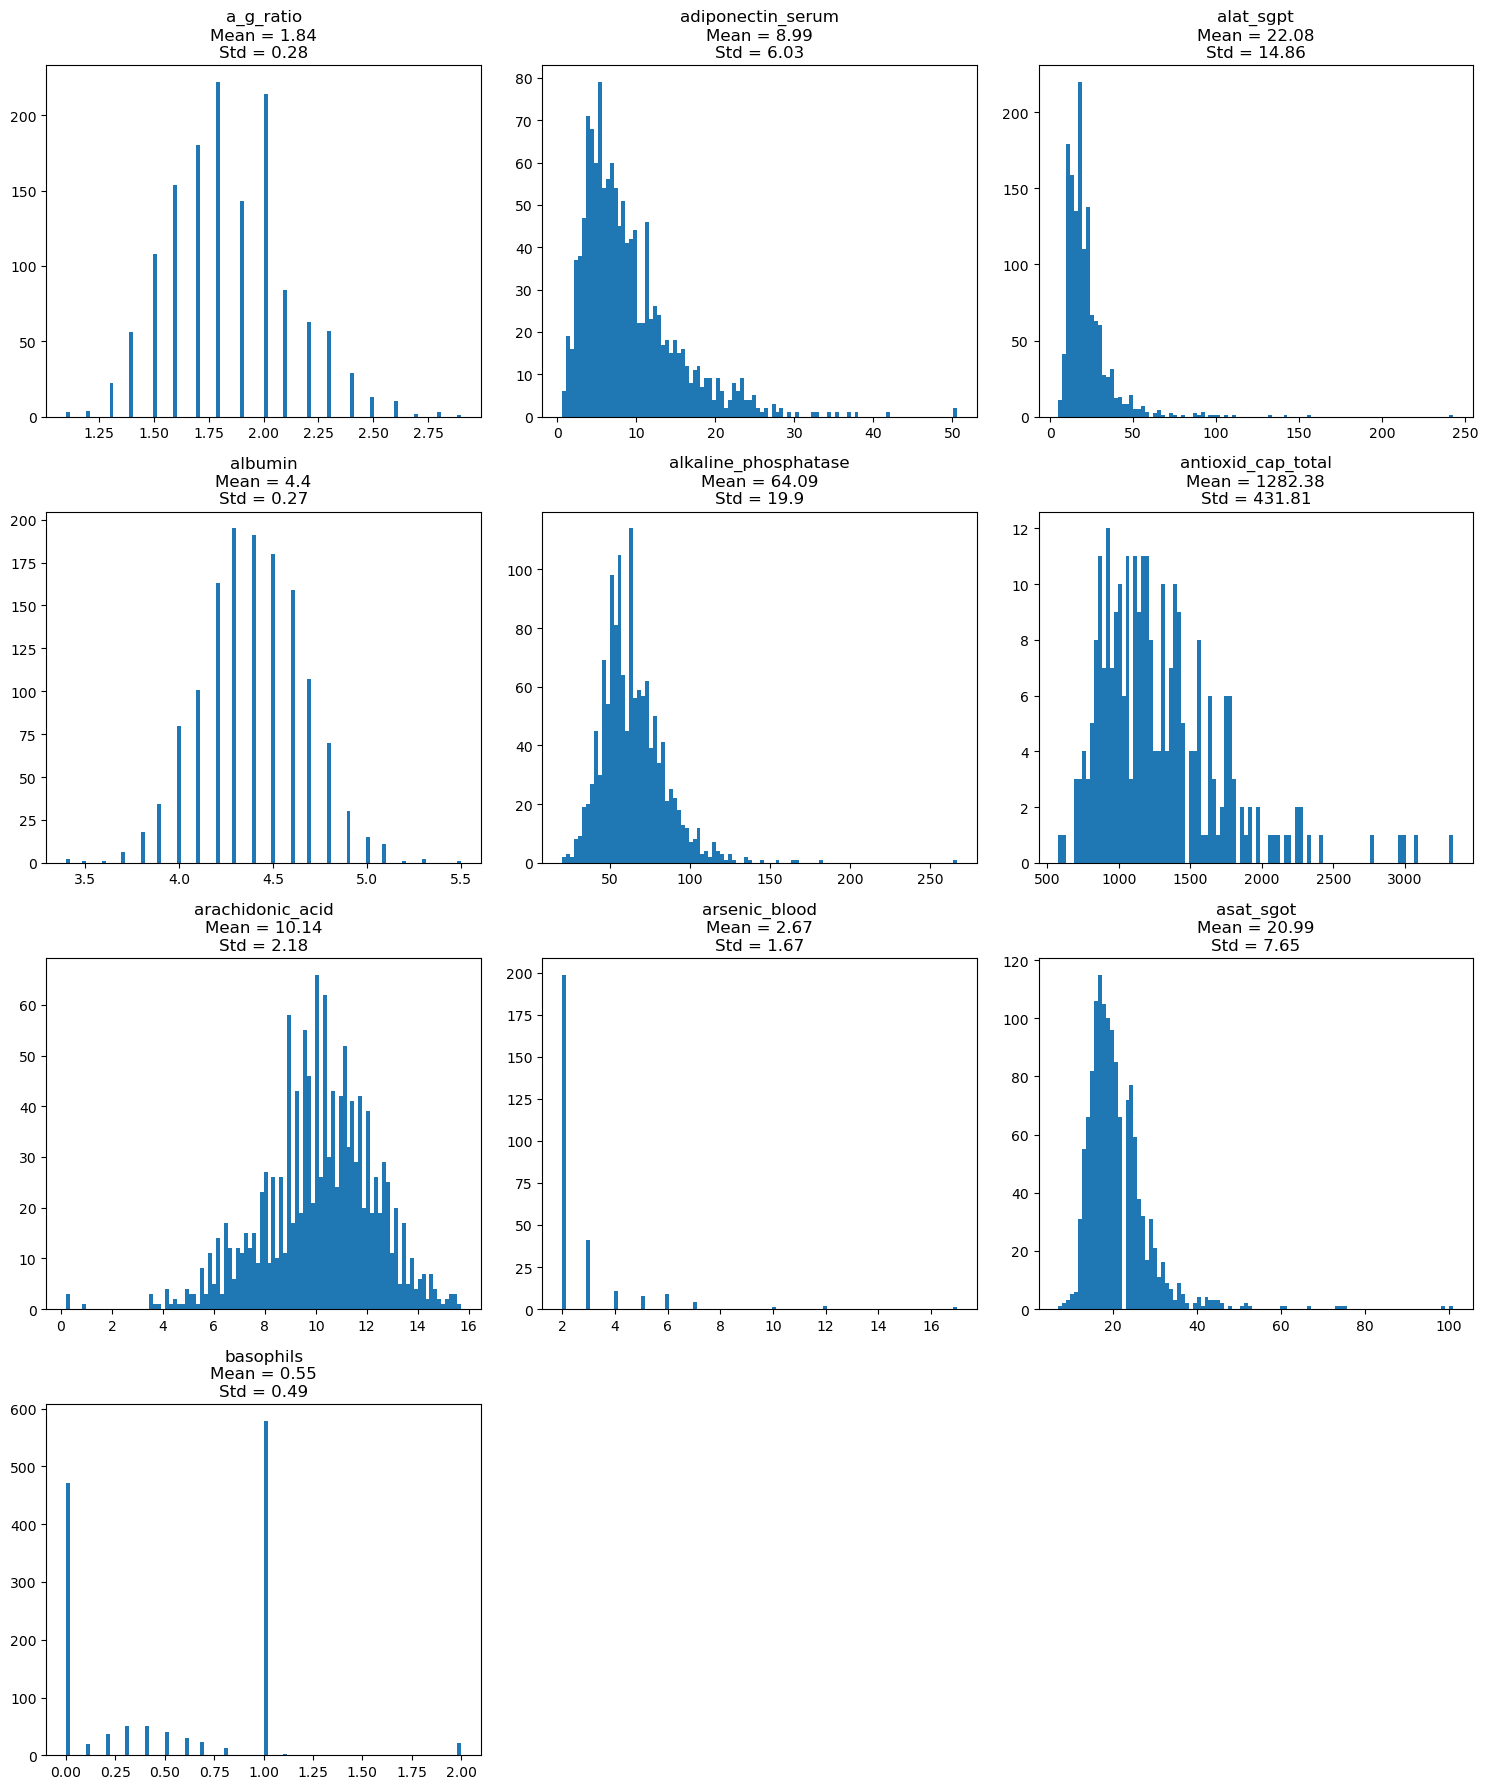

In [364]:
# these will need log(1+x) transform
plot_histograms(sleep_merged, features_dict['clinical_features'][:10])

In [365]:
sleep_merged[features_dict['clinical_features']].describe()

,a_g_ratio,adiponectin_serum,alat_sgpt,albumin,alkaline_phosphatase,antioxid_cap_total,arachidonic_acid,arsenic_blood,asat_sgot,basophils,...,vitamin_d3_25_oh,vldl_ldl_particle_number,vldl_particle_number,vldl_size_percentile,vldl_triglycerides,white_cell_count,zinc,zinc_rbc,leptin,zinc_plasma_or_serum
count,1368.000000,1301.000000,1368.000000,1368.000000,1368.000000,275.000000,1349.000000,276.000000,1368.000000,1343.000000,...,275.000000,34.000000,34.000000,34.000000,34.000000,1345.000000,1150.000000,276.000000,30.000000,187.000000
mean,1.841886,8.985012,22.075292,4.396491,64.085526,1282.376000,10.142698,2.673913,20.994152,0.552271,...,36.418182,1292.558824,52.964706,38.661765,68.361765,5.493086,1299.910435,10.484783,24.226667,83.732620
std,0.275253,6.033779,14.856131,0.273779,19.896532,431.810205,2.181936,1.667499,7.645872,0.491425,...,12.787555,399.006660,25.492541,26.343650,36.501773,1.402895,251.220425,1.546346,18.938229,11.176163
min,1.100000,0.600000,5.000000,3.400000,20.000000,576.200000,0.200000,2.000000,7.000000,0.000000,...,10.000000,581.000000,16.200000,0.400000,23.600000,2.300000,90.000000,0.900000,2.800000,54.000000
25%,1.600000,4.700000,14.000000,4.200000,51.000000,975.050000,8.900000,2.000000,16.000000,0.000000,...,28.000000,915.750000,33.900000,13.400000,44.375000,4.500000,1124.500000,9.700000,10.275000,76.000000
50%,1.800000,7.400000,18.000000,4.400000,62.000000,1187.500000,10.300000,2.000000,20.000000,0.600000,...,34.000000,1337.000000,50.700000,38.600000,58.050000,5.300000,1295.000000,10.550000,16.700000,83.000000
75%,2.000000,11.500000,25.000000,4.600000,74.000000,1452.200000,11.600000,3.000000,24.000000,1.000000,...,42.000000,1557.000000,66.775000,57.425000,83.725000,6.300000,1455.000000,11.325000,33.200000,91.000000
max,2.900000,50.600000,243.000000,5.500000,267.000000,3338.500000,15.700000,17.000000,101.000000,2.000000,...,86.000000,2041.000000,118.000000,93.400000,174.300000,12.900000,3639.000000,15.000000,87.500000,118.000000


In [366]:
# note some of these 
(sleep_merged[features_dict['clinical_features']] == 0).any().sum()

14

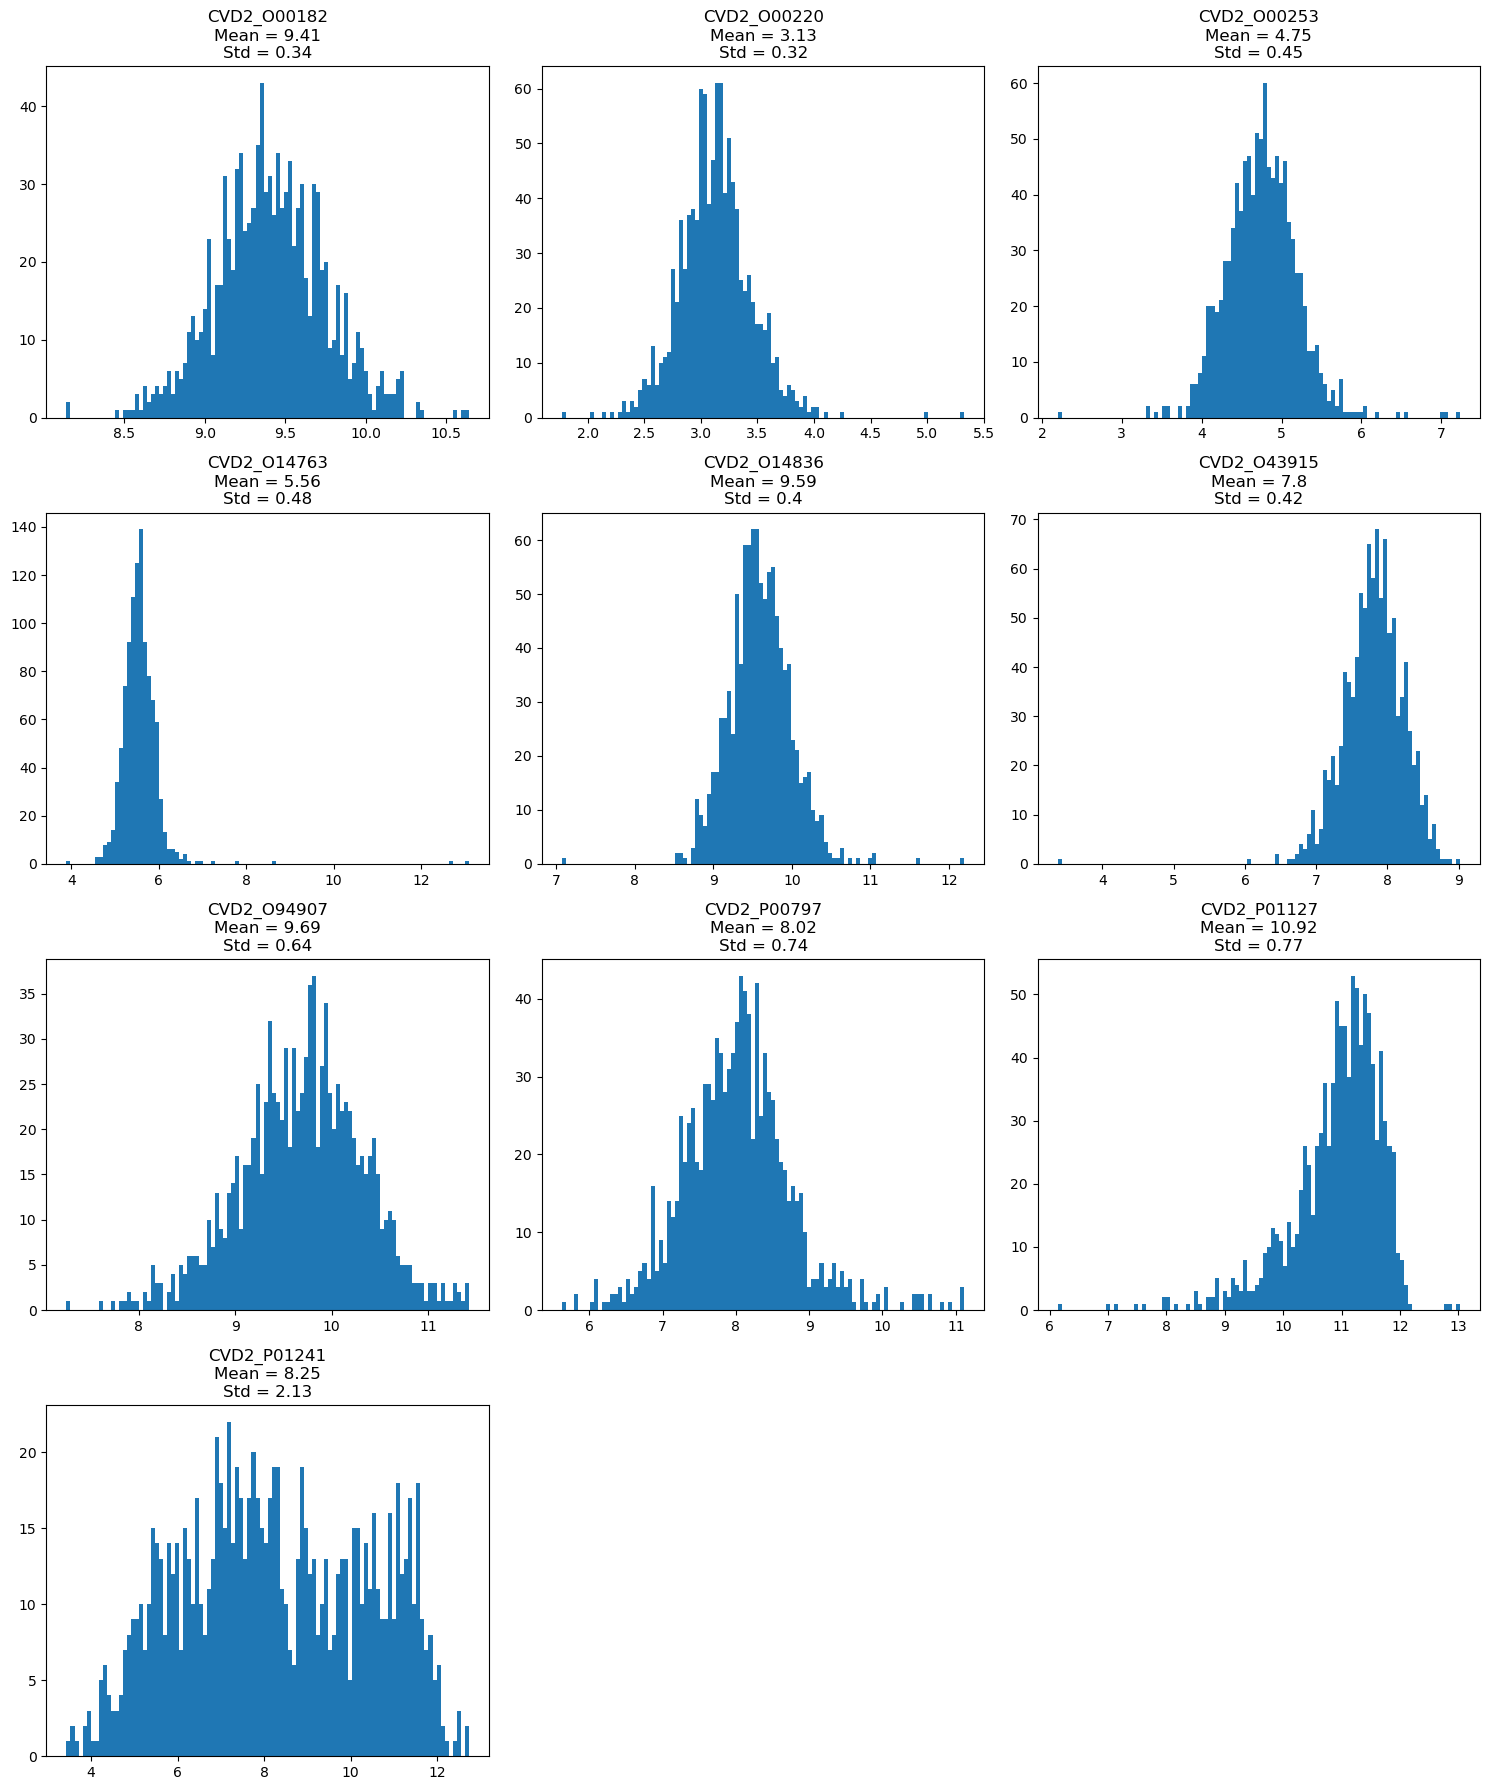

In [367]:
# proteomics does NOT need transform
plot_histograms(sleep_merged, features_dict['proteomics_features'][:10])

In [368]:
sleep_merged[features_dict['proteomics_features']].describe()

,CVD2_O00182,CVD2_O00220,CVD2_O00253,CVD2_O14763,CVD2_O14836,CVD2_O43915,CVD2_O94907,CVD2_P00797,CVD2_P01127,CVD2_P01241,...,INF_Q99748,INF_Q9BZW8,INF_Q9GZV9,INF_Q9H5V8,INF_Q9NRJ3,INF_Q9NSA1,INF_Q9NYY1,INF_Q9NZQ7,INF_Q9P0M4,INF_Q9UHF4
count,1029.000000,1029.000000,1029.000000,1029.000000,1029.000000,1029.000000,1029.000000,1029.000000,1029.000000,1029.000000,...,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,9.409928,3.130168,4.753583,5.560600,9.592241,7.801678,9.690751,8.017759,10.922081,8.245801,...,0.628194,6.915913,3.000864,3.077249,2.528882,4.449682,1.090571,4.888998,1.073485,-0.125220
std,0.339849,0.319733,0.445494,0.477511,0.396562,0.422573,0.640071,0.735670,0.772751,2.126457,...,0.524795,0.539728,0.562760,0.562114,0.429518,1.232402,0.442508,0.505681,0.500162,0.563371
min,8.139805,1.773425,2.195340,3.885390,7.072075,3.370610,7.252500,5.629528,6.135715,3.431660,...,-0.131645,4.471155,1.406415,1.430175,1.325655,1.340630,0.423300,2.763200,-0.049655,-0.948000
25%,9.191505,2.936770,4.463625,5.333125,9.342825,7.557775,9.292792,7.564578,10.585140,6.590805,...,0.384075,6.566558,2.677293,2.709519,2.264934,3.562451,0.897705,4.606666,0.786698,-0.433596
50%,9.396700,3.125240,4.755875,5.539110,9.576675,7.814793,9.729255,8.023485,11.060265,8.095510,...,0.532072,6.874325,2.929220,3.034070,2.481300,4.502200,1.014885,4.835610,1.019820,-0.264132
75%,9.625680,3.305470,5.025635,5.752350,9.831772,8.072945,10.123980,8.422628,11.444965,10.111650,...,0.735078,7.222131,3.229472,3.371956,2.726541,5.311704,1.165200,5.080360,1.266155,-0.031035
max,10.640060,5.327273,7.234125,13.093375,12.196130,9.016165,11.419155,11.115715,13.028555,12.730075,...,7.475858,9.978030,7.775700,5.999525,5.659160,8.422982,6.590350,9.657005,8.565430,5.775300


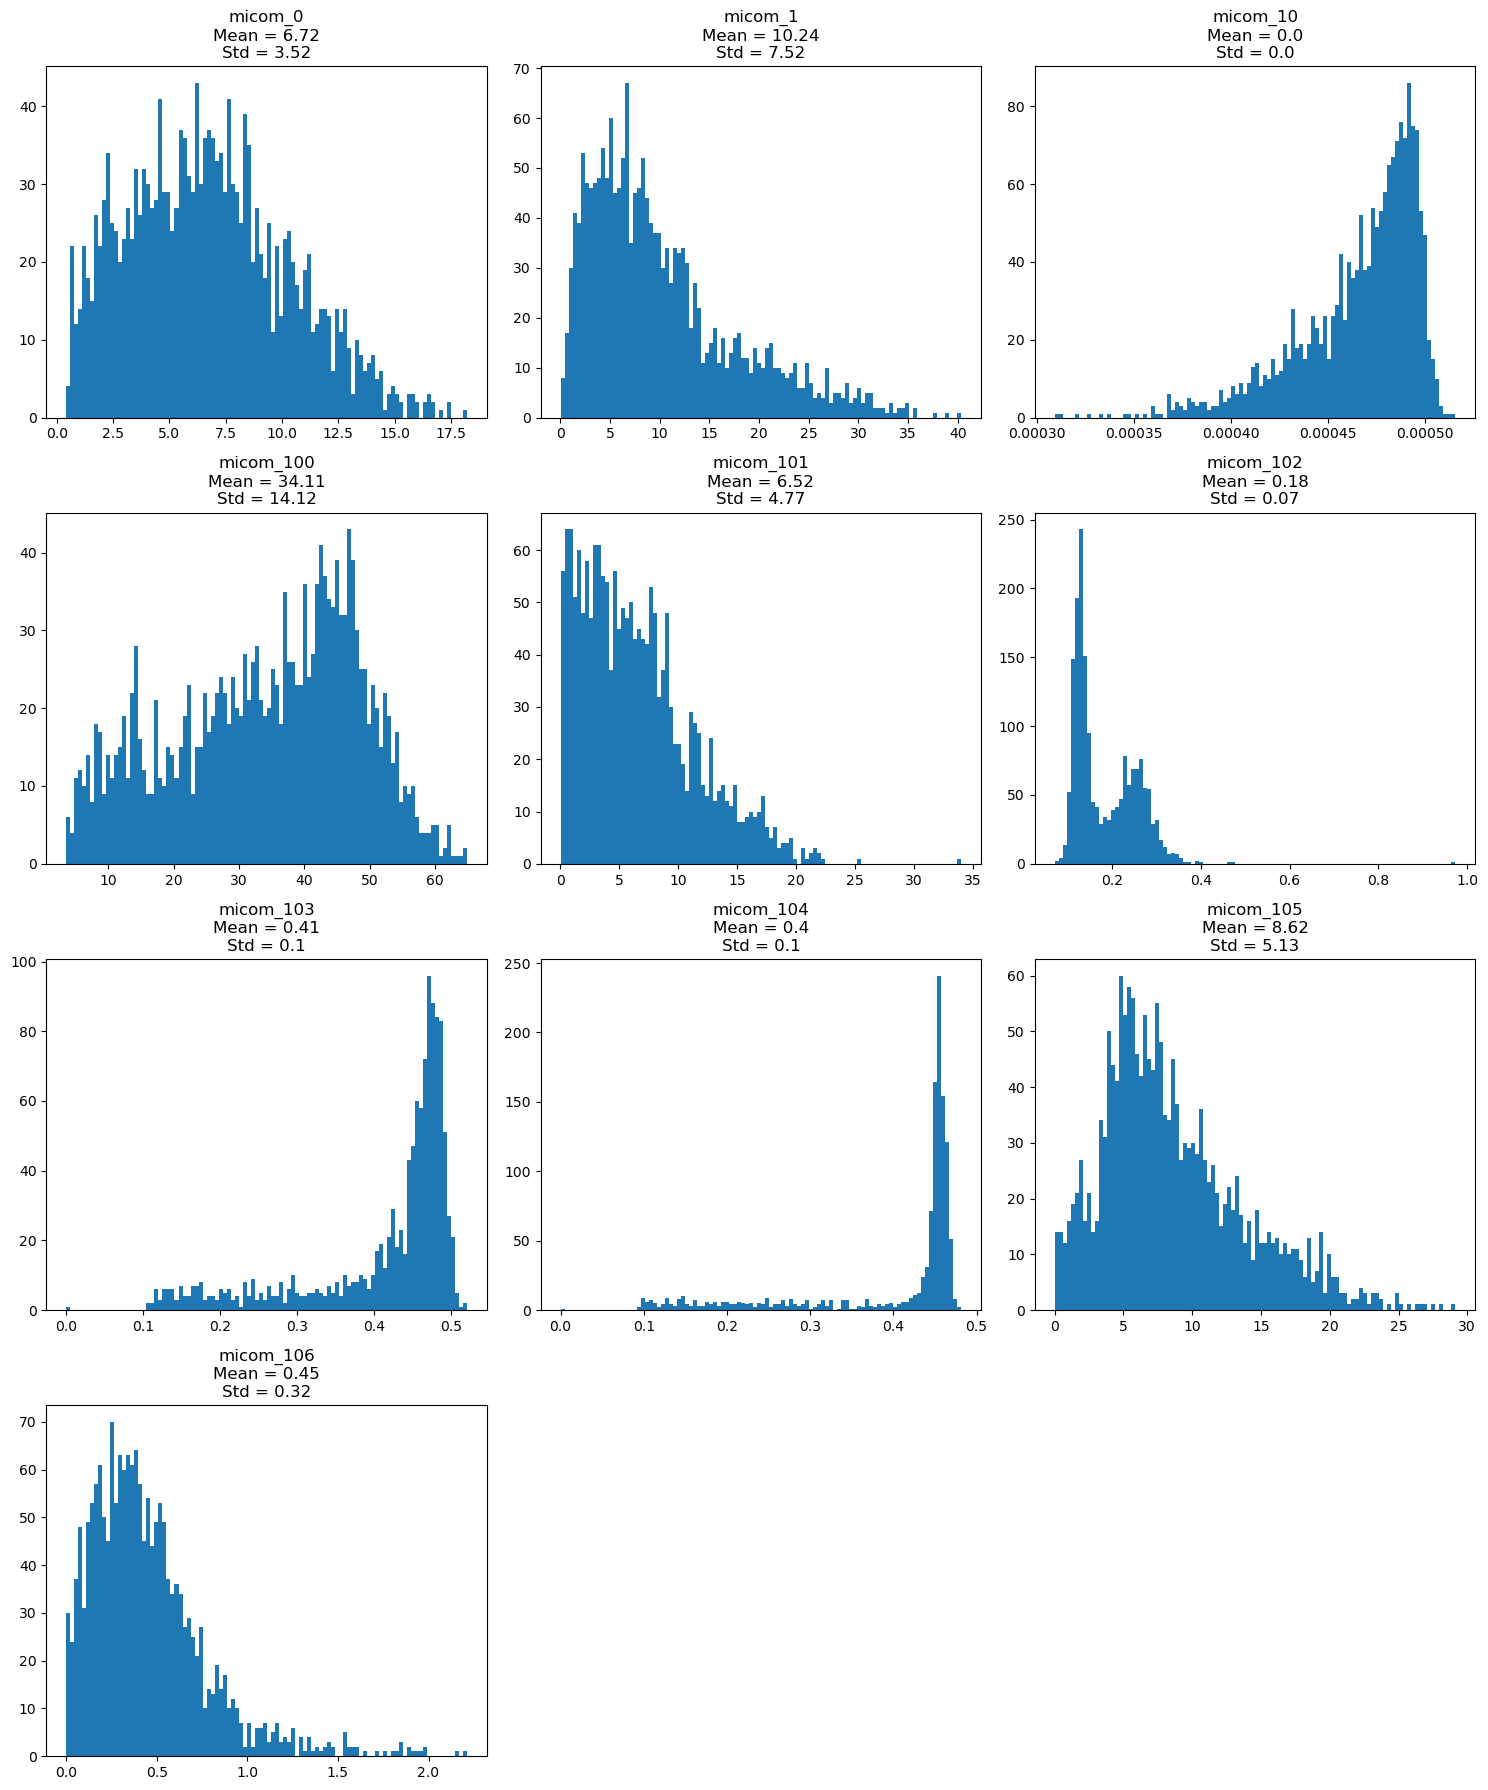

In [369]:
# micom features will need log transform
plot_histograms(sleep_merged, features_dict['micom_features'][:10])

In [370]:
sleep_merged[features_dict['micom_features']].describe()

,micom_0,micom_1,micom_10,micom_100,micom_101,micom_102,micom_103,micom_104,micom_105,micom_106,...,micom_90,micom_91,micom_92,micom_93,micom_94,micom_95,micom_96,micom_97,micom_98,micom_99
count,1792.000000,1793.000000,1766.000000,1793.000000,1792.000000,1793.000000,1207.000000,1207.000000,1782.000000,1775.000000,...,1779.000000,1793.000000,1793.000000,1.279000e+03,1790.000000,1793.000000,1793.000000,1793.000000,1606.000000,1793.000000
mean,6.719196,10.241452,0.000466,34.113679,6.520138,0.183295,0.413034,0.400477,8.615639,0.450605,...,5.339316,8.599160,0.287341,6.150480e-02,0.000707,24.197449,31.723897,22.307547,0.400121,6.483985
std,3.519885,7.518705,0.000031,14.117851,4.770946,0.069569,0.100182,0.104515,5.129607,0.323107,...,1.203842,7.155928,0.031008,3.659338e-01,0.000087,5.791077,7.629449,5.706597,0.797972,3.118542
min,0.425226,0.040322,0.000309,3.587188,0.036819,0.071387,0.000014,0.000006,0.013050,0.001453,...,0.463300,0.334700,0.194240,4.628978e-07,0.000048,3.039575,5.999673,2.473171,0.048549,0.498915
25%,3.967662,4.656035,0.000450,23.743490,2.763683,0.126529,0.393188,0.414264,4.951628,0.225005,...,4.573126,4.000216,0.267624,4.197495e-03,0.000674,20.598774,26.561522,18.335783,0.105461,4.405694
50%,6.513862,8.321228,0.000475,36.552064,5.670081,0.151864,0.456976,0.452070,7.514311,0.390204,...,5.257383,7.219758,0.285708,1.046997e-02,0.000709,23.754764,32.028210,21.947482,0.211411,5.787759
75%,8.984743,13.615099,0.000489,45.309882,9.148314,0.242588,0.477791,0.458151,11.503763,0.591734,...,6.040910,10.990598,0.305028,2.219778e-02,0.000747,27.274989,37.663786,26.018714,0.452464,7.879745
max,18.211505,40.316417,0.000515,64.870080,34.011570,0.973445,0.520906,0.481441,29.127936,2.211537,...,11.554566,68.306451,0.613125,8.840648e+00,0.000918,51.363792,50.154517,44.319306,22.802166,25.862366


In [371]:
# no 0s great
(sleep_merged[features_dict['micom_features']] == 0).any().sum()

0

## log1p or log transform the variables as determined above

In [372]:
for feature in features_dict['metabolite_features']:
    sleep_merged[f"{feature}_log"] = np.log(sleep_merged[feature])

In [373]:
for feature in features_dict['clinical_features']:
    sleep_merged[f"{feature}_log1p"] = np.log1p(sleep_merged[feature])

In [374]:
for feature in features_dict['micom_features']:
    sleep_merged[f"{feature}_log"] = np.log(sleep_merged[feature])

In [375]:
# make new labels to add to the features dict of the new transformed columns
metabolite_features_log = [f"{feature}_log" for feature in features_dict['metabolite_features']]
clinical_features_log1p = [f"{feature}_log1p" for feature in features_dict['clinical_features']]
micom_features_log = [f"{feature}_log" for feature in features_dict['micom_features']]

# add lists to features dict
features_dict['metabolite_features_log'] = metabolite_features_log
features_dict['clinical_features_log1p'] = clinical_features_log1p
features_dict['micom_features_log'] = micom_features_log

# Make columns for any mental health diagnosis now or before, do the same for sleep disorder

In [376]:
features_dict.keys()

dict_keys(['heartrate_features', 'activity_features', 'sleep_features', 'covariate_features', 'sleep_features_log1p', 'sleep_features_log1p_resids', 'activity_features_resids', 'heartrate_features_resids', 'vendor_features', 'new_microbe_binarized_features', 'new_microbe_features_binary_10_90', 'new_microbe_features', 'diversity_features', 'dip_features', 'metabolite_features', 'food_freq_features', 'food_freq_features_daily', 'food_freq_from_non_freq_features', 'food_freq_from_non_freq_features_daily', 'diet_daily_features', 'gut_q_features', 'mental_health_q_features', 'sleep_disorder_q_features', 'digestion_features', 'supplement_features', 'med_features', 'clinical_features', 'proteomics_features', 'micom_features', 'metabolite_features_log', 'clinical_features_log1p', 'micom_features_log'])

In [377]:
sleep_merged[features_dict['mental_health_q_features']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1793 entries, 0 to 1792
Data columns (total 14 columns):
 #   Column                                                           Non-Null Count  Dtype  
---  ------                                                           --------------  -----  
 0   mental_health_alcohol_abuse_self_anytime_before                  234 non-null    float64
 1   mental_health_binge_eating_disorder_self_anytime_before          234 non-null    float64
 2   mental_health_anorexia_self_anytime_before                       234 non-null    float64
 3   mental_health_drug_abuse_self_anytime_before                     234 non-null    float64
 4   mental_health_adhd_add_self_anytime_before                       234 non-null    float64
 5   mental_health_anxiety_disorder_self_anytime_before               234 non-null    float64
 6   mental_health_other_self_anytime_before                          234 non-null    float64
 7   mental_health_schizophrenia_self_anytime_b

In [378]:
# Compute row-wise indicators
sleep_merged['any_mental_health_self_anytime_before'] = (
    sleep_merged[features_dict['mental_health_q_features']]
    .apply(lambda row:
           1 if (row == 1).any()                    # any 1s → 1
           else (0 if row.notna().any() else np.nan),  # if no 1s but at least one non-NaN → 0, else NaN
           axis=1)
)

In [379]:
sleep_merged['any_mental_health_self_anytime_before'].value_counts()

any_mental_health_self_anytime_before
0.0    1262
1.0     427
Name: count, dtype: int64

In [380]:
sleep_merged['any_mental_health_self_anytime_before'].value_counts(normalize=True)

any_mental_health_self_anytime_before
0.0    0.747188
1.0    0.252812
Name: proportion, dtype: float64

In [381]:
for col in features_dict['mental_health_q_features']:
    print(sleep_merged[col].value_counts())
    print('')

mental_health_alcohol_abuse_self_anytime_before
0.0    225
1.0      9
Name: count, dtype: int64

mental_health_binge_eating_disorder_self_anytime_before
0.0    228
1.0      6
Name: count, dtype: int64

mental_health_anorexia_self_anytime_before
0.0    229
1.0      5
Name: count, dtype: int64

mental_health_drug_abuse_self_anytime_before
0.0    230
1.0      4
Name: count, dtype: int64

mental_health_adhd_add_self_anytime_before
0.0    210
1.0     24
Name: count, dtype: int64

mental_health_anxiety_disorder_self_anytime_before
0.0    194
1.0     40
Name: count, dtype: int64

mental_health_other_self_anytime_before
0.0    228
1.0      6
Name: count, dtype: int64

mental_health_schizophrenia_self_anytime_before
0.0    234
Name: count, dtype: int64

mental_health_bulimia_self_anytime_before
0.0    228
1.0      6
Name: count, dtype: int64

mental_health_sad_self_anytime_before
0.0    221
1.0     13
Name: count, dtype: int64

mental_health_other_eating_disorder_self_anytime_before
0.0    229


In [382]:
for col in features_dict['mental_health_q_features']:
    print(sleep_merged[col].value_counts(normalize=True))
    print('')

mental_health_alcohol_abuse_self_anytime_before
0.0    0.961538
1.0    0.038462
Name: proportion, dtype: float64

mental_health_binge_eating_disorder_self_anytime_before
0.0    0.974359
1.0    0.025641
Name: proportion, dtype: float64

mental_health_anorexia_self_anytime_before
0.0    0.978632
1.0    0.021368
Name: proportion, dtype: float64

mental_health_drug_abuse_self_anytime_before
0.0    0.982906
1.0    0.017094
Name: proportion, dtype: float64

mental_health_adhd_add_self_anytime_before
0.0    0.897436
1.0    0.102564
Name: proportion, dtype: float64

mental_health_anxiety_disorder_self_anytime_before
0.0    0.82906
1.0    0.17094
Name: proportion, dtype: float64

mental_health_other_self_anytime_before
0.0    0.974359
1.0    0.025641
Name: proportion, dtype: float64

mental_health_schizophrenia_self_anytime_before
0.0    1.0
Name: proportion, dtype: float64

mental_health_bulimia_self_anytime_before
0.0    0.974359
1.0    0.025641
Name: proportion, dtype: float64

mental_health

In [383]:
sleep_merged[features_dict['sleep_disorder_q_features']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1793 entries, 0 to 1792
Data columns (total 5 columns):
 #   Column                                                     Non-Null Count  Dtype  
---  ------                                                     --------------  -----  
 0   sleep_condition_restless_leg_syndrome_self_anytime_before  233 non-null    float64
 1   sleep_condition_other_self_anytime_before                  233 non-null    float64
 2   sleep_condition_narcolepsy_self_anytime_before             233 non-null    float64
 3   sleep_condition_insomnia_self_anytime_before               233 non-null    float64
 4   sleep_condition_apnea_self_anytime_before                  1641 non-null   float64
dtypes: float64(5)
memory usage: 70.2 KB


In [384]:
for col in features_dict['sleep_disorder_q_features']:
    print(sleep_merged[col].value_counts())
    print('')

sleep_condition_restless_leg_syndrome_self_anytime_before
0.0    212
1.0     21
Name: count, dtype: int64

sleep_condition_other_self_anytime_before
0.0    223
1.0     10
Name: count, dtype: int64

sleep_condition_narcolepsy_self_anytime_before
0.0    230
1.0      3
Name: count, dtype: int64

sleep_condition_insomnia_self_anytime_before
0.0    181
1.0     52
Name: count, dtype: int64

sleep_condition_apnea_self_anytime_before
0.0    1452
1.0     189
Name: count, dtype: int64



In [385]:
for col in features_dict['sleep_disorder_q_features']:
    print(sleep_merged[col].value_counts(normalize=True))
    print('')

sleep_condition_restless_leg_syndrome_self_anytime_before
0.0    0.909871
1.0    0.090129
Name: proportion, dtype: float64

sleep_condition_other_self_anytime_before
0.0    0.957082
1.0    0.042918
Name: proportion, dtype: float64

sleep_condition_narcolepsy_self_anytime_before
0.0    0.987124
1.0    0.012876
Name: proportion, dtype: float64

sleep_condition_insomnia_self_anytime_before
0.0    0.776824
1.0    0.223176
Name: proportion, dtype: float64

sleep_condition_apnea_self_anytime_before
0.0    0.884826
1.0    0.115174
Name: proportion, dtype: float64



In [386]:
# Compute row-wise indicators
sleep_merged['any_sleep_disorder_self_anytime_before'] = (
    sleep_merged[features_dict['sleep_disorder_q_features']]
    .apply(lambda row:
           1 if (row == 1).any()                    # any 1s → 1
           else (0 if row.notna().any() else np.nan),  # if no 1s but at least one non-NaN → 0, else NaN
           axis=1)
)

In [387]:
sleep_merged['any_sleep_disorder_self_anytime_before'].value_counts()

any_sleep_disorder_self_anytime_before
0.0    1391
1.0     250
Name: count, dtype: int64

In [388]:
sleep_merged['any_sleep_disorder_self_anytime_before'].value_counts(normalize=True)

any_sleep_disorder_self_anytime_before
0.0    0.847654
1.0    0.152346
Name: proportion, dtype: float64

In [389]:
sleep_merged.shape

(1793, 5893)

In [390]:
sleep_merged = sleep_merged.dropna(subset=['any_sleep_disorder_self_anytime_before', 'any_mental_health_self_anytime_before'])

In [391]:
sleep_merged.shape

(1634, 5893)

# Add in PSS scores for psychological stress covariate

In [3]:
# First add in the perceived stress
stress = get_snapshot('assessments_stress')

In [4]:
stress

,public_client_id,vendor,days_in_program,days_since_first_call,days_since_first_draw,month,weekday,season,assessment:lifestyle:avg_stress:enum,assessment:lifestyle:stress_management:enum,assessment:pss-four-item:going_your_way:enum,assessment:pss-four-item:handle_problems:enum,assessment:pss-four-item:insurmountable:enum,assessment:pss-four-item:out_of_control:enum,response_count,response_pct
0,01000261,Health 123,37.0,-37.0,-28.0,Dec,Tue,winter,(7) 8,(0) No,(2) Sometimes,(2) Sometimes,(3) Fairly Often,(3) Fairly Often,6.0,100.0
1,01000552,Assessments,0.0,NaN,NaN,Mar,Fri,spring,(6) 7,(0) No,(0) Very Often,(0) Very Often,(0) Never,(0) Never,6.0,100.0
2,01001298,Assessments,0.0,-7.0,-7.0,Aug,Tue,summer,(8) 9,(0) No,(2) Sometimes,(2) Sometimes,(3) Fairly Often,(3) Fairly Often,6.0,100.0
3,01001467,Assessments,0.0,-14.0,-15.0,May,Tue,spring,(3) 4,(0) No,(1) Fairly Often,(1) Fairly Often,(1) Almost Never,(2) Sometimes,6.0,100.0
4,01001548,Assessments,4.0,-5.0,-3.0,Oct,Fri,fall,(6) 7,(1) Yes,(2) Sometimes,(1) Fairly Often,(1) Almost Never,(1) Almost Never,6.0,100.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7012,QIRL,Assessments,1128.0,596.0,593.0,May,Wed,spring,(6) 7,(1) Yes,(1) Fairly Often,(0) Very Often,(1) Almost Never,(2) Sometimes,6.0,100.0
7013,ZU273983,Assessments,1.0,279.0,0.0,Dec,Thu,winter,(7) 8,(0) No,(2) Sometimes,(2) Sometimes,(2) Sometimes,(3) Fairly Often,6.0,100.0
7014,ZU612255,Assessments,0.0,26.0,-3.0,Apr,Tue,spring,(4) 5,(0) No,(1) Fairly Often,(0) Very Often,(1) Almost Never,(1) Almost Never,6.0,100.0
7015,ZU621944,Assessments,4.0,56.0,-2.0,Apr,Tue,spring,(3) 4,(1) Yes,(1) Fairly Often,(1) Fairly Often,(1) Almost Never,(1) Almost Never,6.0,100.0


In [396]:
stress['assessment:lifestyle:avg_stress:enum']

0       (7) 8
1       (6) 7
2       (8) 9
3       (3) 4
4       (6) 7
        ...  
7012    (6) 7
7013    (7) 8
7014    (4) 5
7015    (3) 4
7016    (4) 5
Name: assessment:lifestyle:avg_stress:enum, Length: 7017, dtype: object

In [397]:
stress.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7017 entries, 0 to 7016
Data columns (total 16 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   public_client_id                               7017 non-null   object 
 1   vendor                                         7017 non-null   object 
 2   days_in_program                                7014 non-null   float64
 3   days_since_first_call                          6707 non-null   float64
 4   days_since_first_draw                          6820 non-null   float64
 5   month                                          7017 non-null   object 
 6   weekday                                        7017 non-null   object 
 7   season                                         7017 non-null   object 
 8   assessment:lifestyle:avg_stress:enum           6609 non-null   object 
 9   assessment:lifestyle:stress_management:enum    6606 

In [398]:
stress.rename(columns={'assessment:lifestyle:avg_stress:enum': 'avg_stress'}, inplace=True)

In [399]:
# Example assuming your column is named 'column_name'
stress['avg_stress'] = stress['avg_stress'].str.extract(r'\)\s*(\d+)').astype(float)

<Axes: >

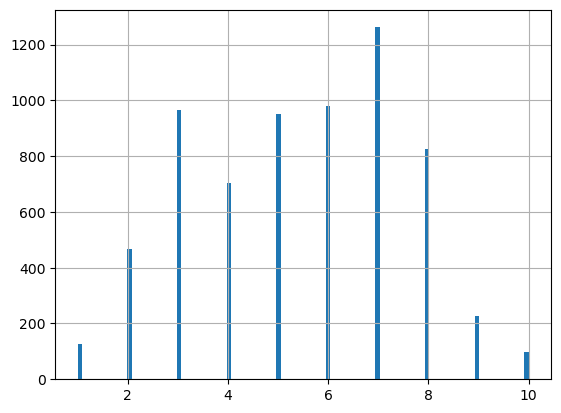

In [400]:
stress.avg_stress.hist(bins=100)

In [401]:
stress_to_merge = stress[['public_client_id', 'days_in_program'] + ['avg_stress', 'vendor']]
stress_to_merge = stress_to_merge.dropna(subset=['public_client_id', 'days_in_program', 'vendor'])
stress_to_merge['days_in_program'] = stress_to_merge.days_in_program.astype('float')
stress_to_merge['stress_dip'] = stress_to_merge.days_in_program
stress_to_merge.rename(columns={'vendor': 'stress_vendor'}, inplace=True)
stress_to_merge = stress_to_merge.sort_values(by='days_in_program')

In [402]:
# Merge stress onto sleep merged using a tolerance of 100 days
sleep_merged = pd.merge_asof(
    sleep_merged,
    stress_to_merge[
        stress_to_merge.public_client_id.isin(sleep_merged.public_client_id)
    ],
    by="public_client_id",
    on="days_in_program",
    direction="nearest",
    tolerance=100
)

In [403]:
sleep_merged.shape

(1634, 5896)

In [404]:
sleep_merged = sleep_merged.dropna(subset='avg_stress')

In [405]:
sleep_merged.shape

(1591, 5896)

In [406]:
sleep_merged.dropna(subset=['avg_stress', 'mental_health_depression_self_anytime_before']).stress_vendor.value_counts()

stress_vendor
Assessments    1276
Health 123      299
Name: count, dtype: int64

In [407]:
sleep_merged.dropna(subset=['avg_stress', 'mental_health_depression_self_anytime_before']).mental_health_gut_sleep_q_vendor.value_counts()

mental_health_gut_sleep_q_vendor
Assessments    1276
Health 123      299
Name: count, dtype: int64

In [408]:
# Great! The stress vendor and mental_health_gut_sleep_q_vendor are the same!
(sleep_merged.mental_health_gut_sleep_q_vendor == sleep_merged.stress_vendor).sum()

1591

# Check for people taking any sleep medication or melatonin and drop them

In [409]:
(sleep_merged[features_dict['med_features']] == 1).any(axis=1).sum()

74

In [410]:
sleep_merged.melatonin.value_counts()

melatonin
0.0    1537
1.0      54
Name: count, dtype: int64

In [411]:
(sleep_merged[features_dict['med_features'] + ['melatonin']] == 1).any(axis=1).sum()

122

In [412]:
78+55

133

In [413]:
# 7 people are taking both a sleep med and melatonin
133-126

7

# Toggle this to save sleep_merged WITH sleep meds and melatonin INCLUDED vs EXCLUDED

In [414]:
# Drop anyone taking sleep med or melatonin
sleep_merged = sleep_merged[~(sleep_merged[features_dict['med_features'] + ['melatonin']] == 1).any(axis=1)]

In [415]:
sleep_merged.shape

(1469, 5896)

# Save sleep_merged as a csv and save the features_dict as a json

In [416]:
sleep_merged.to_csv('sleep_merged_sleep_meds_excluded_10_14_2025.csv', index=False)

In [417]:
# Make features_dict file
import json
# Save to JSON file
with open('features_dict.json', 'w') as f:
    json.dump(features_dict, f, indent=4)

In [418]:
list(features_dict.keys())

['heartrate_features',
 'activity_features',
 'sleep_features',
 'covariate_features',
 'sleep_features_log1p',
 'sleep_features_log1p_resids',
 'activity_features_resids',
 'heartrate_features_resids',
 'vendor_features',
 'new_microbe_binarized_features',
 'new_microbe_features_binary_10_90',
 'new_microbe_features',
 'diversity_features',
 'dip_features',
 'metabolite_features',
 'food_freq_features',
 'food_freq_features_daily',
 'food_freq_from_non_freq_features',
 'food_freq_from_non_freq_features_daily',
 'diet_daily_features',
 'gut_q_features',
 'mental_health_q_features',
 'sleep_disorder_q_features',
 'digestion_features',
 'supplement_features',
 'med_features',
 'clinical_features',
 'proteomics_features',
 'micom_features',
 'metabolite_features_log',
 'clinical_features_log1p',
 'micom_features_log']